In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/retail-store-sales-dirty-for-data-cleaning/retail_store_sales.csv


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/retail-store-sales-dirty-for-data-cleaning/retail_store_sales.csv')

print(df.head())

  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  Discount Applied  
0             True  
1             True  
2            False  
3              NaN  
4          

In [3]:
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [4]:
df['Item'].unique()

array(['Item_10_PAT', 'Item_17_MILK', 'Item_12_BUT', 'Item_16_BEV',
       'Item_6_FOOD', nan, 'Item_1_FOOD', 'Item_16_FUR', 'Item_22_BUT',
       'Item_3_BUT', 'Item_2_FOOD', 'Item_24_PAT', 'Item_16_MILK',
       'Item_17_PAT', 'Item_13_EHE', 'Item_7_BEV', 'Item_4_EHE',
       'Item_10_FOOD', 'Item_14_FUR', 'Item_20_BUT', 'Item_25_FUR',
       'Item_14_FOOD', 'Item_22_PAT', 'Item_11_FOOD', 'Item_6_PAT',
       'Item_21_EHE', 'Item_25_BEV', 'Item_23_FOOD', 'Item_10_FUR',
       'Item_11_BEV', 'Item_23_BUT', 'Item_22_BEV', 'Item_10_EHE',
       'Item_24_BUT', 'Item_8_BEV', 'Item_3_FOOD', 'Item_12_FOOD',
       'Item_16_CEA', 'Item_11_PAT', 'Item_16_BUT', 'Item_5_CEA',
       'Item_19_MILK', 'Item_23_FUR', 'Item_7_FUR', 'Item_15_CEA',
       'Item_6_MILK', 'Item_24_CEA', 'Item_22_CEA', 'Item_22_FOOD',
       'Item_2_BUT', 'Item_14_PAT', 'Item_12_PAT', 'Item_18_FOOD',
       'Item_1_PAT', 'Item_4_BEV', 'Item_22_FUR', 'Item_7_PAT',
       'Item_20_CEA', 'Item_20_FOOD', 'Item_11_FUR', 'Item

In [5]:
"""df['SubCategory'] = df['Item'].str.split('_', n=1).str[1]
# Split the Item column"""
split_item = df['Item'].str.split('_', expand=True)

df['item_SubCategory'] = split_item[2] + '_' + split_item[1]
#df['Item'] = split_item[2] + '_' + split_item[1]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Category_b'] = le.fit_transform(df['Category'])
df['Payment Method_b'] = le.fit_transform(df['Payment Method'])
df['Location'] = le.fit_transform(df['Location'])
df['item_SubCategory_b'] = le.fit_transform(df['item_SubCategory'])

In [7]:
df['Customer ID'] = df['Customer ID'].str.extract(r'CUST_(\d+)', expand=False).astype(int)

In [8]:
df['Transaction ID'] = df['Transaction ID'].str.extract(r'TXN_(\d+)', expand=False).astype(int)

In [9]:
df['discount_applied_b'] = df['Discount Applied'].astype(str).map({'False': '0', 'True': '1'}).fillna('NaN')

In [10]:
#df['item_category'] = df['Item'].str.extract(r'Item_\d+_(\w+)', expand=False)

In [11]:
"""
df['item_code'] = (
    df['Item']
    .str.extract(r'Item_(\d+)', expand=False)
    .dropna()
    .astype(int)
)

df['item_code'] = df['Item'].str.extract(r'Item_(\d+)', expand=False).astype(float).astype('Int64')
"""

"\ndf['item_code'] = (\n    df['Item']\n    .str.extract(r'Item_(\\d+)', expand=False)\n    .dropna()\n    .astype(int)\n)\n\ndf['item_code'] = df['Item'].str.extract(r'Item_(\\d+)', expand=False).astype(float).astype('Int64')\n"

In [12]:
"""
grouped_df = df.groupby('Item').size().reset_index(name='Count')
grouped_df
"""

"\ngrouped_df = df.groupby('Item').size().reset_index(name='Count')\ngrouped_df\n"

In [13]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

In [14]:
df = df.sort_values('Transaction Date')

In [15]:
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,item_SubCategory,Category_b,Payment Method_b,discount_applied_b
4056,2070726,22,Milk Products,Item_6_MILK,12.5,5.0,62.5,Digital Wallet,0,2022-01-01,False,MILK_6,6,2,0
3493,1519499,15,Computers and electric accessories,Item_6_CEA,12.5,6.0,75.0,Credit Card,1,2022-01-01,NaN,CEA_6,2,1,NaN
5168,9364474,19,Food,Item_22_FOOD,36.5,3.0,109.5,Cash,0,2022-01-01,False,FOOD_22,4,0,0
3327,6950467,1,Computers and electric accessories,Item_6_CEA,12.5,6.0,75.0,Digital Wallet,0,2022-01-01,True,CEA_6,2,2,1
5790,6329331,24,Beverages,Item_8_BEV,15.5,5.0,77.5,Credit Card,1,2022-01-01,True,BEV_8,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10463,1661883,4,Beverages,Item_17_BEV,29.0,9.0,261.0,Cash,0,2025-01-18,False,BEV_17,0,0,0
5431,6383632,12,Electric household essentials,Item_21_EHE,35.0,2.0,70.0,Cash,0,2025-01-18,NaN,EHE_21,3,0,NaN
3844,5321918,24,Furniture,Item_6_FUR,12.5,5.0,62.5,Credit Card,0,2025-01-18,False,FUR_6,5,1,0
11069,5709336,10,Food,Item_4_FOOD,9.5,2.0,19.0,Credit Card,0,2025-01-18,True,FOOD_4,4,1,1


In [16]:
df_groupbysubcategory = df.groupby(['item_SubCategory']).apply(
    lambda x: x[['Transaction Date','Transaction ID', 'Customer ID', 'Category','Price Per Unit', 'Quantity', 'Total Spent', 'Payment Method', 'Location', 'Category_b', 'Payment Method_b']])
df_groupbysubcategory

/tmp/ipykernel_47/3753123045.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_groupbysubcategory = df.groupby(['item_SubCategory']).apply(


Transaction Date  Transaction ID  Customer ID  \
item_SubCategory                                                       
BEV_1            2777        2022-07-12         5230040           25   
                 1475        2022-07-31         3073415           24   
                 12394       2022-08-02         6098786            3   
                 5368        2022-08-06         1133322           16   
                 8888        2022-09-01         7531099           14   
...                                 ...             ...          ...   
PAT_9            12449       2024-11-05         7799651            5   
                 12040       2024-11-12         4788104           16   
                 8695        2024-12-05         9722290           19   
                 6537        2024-12-14         4361393           21   
                 8005        2025-01-16         6476117           16   

                          Category  Price Per Unit  Quantity  Total Spent  \
item_SubCategory                                                            
BEV_1            2777    Beverages             5.0       5.0         25.0   
                 1475    Beverages             5.0       4.0         20.0   
                 12394   Beverages             5.0       4.0         20.0   
                 5368    Beverages             5.0      10.0         50.0   
                 8888    Beverages             5.0       7.0         35.0   
...                            ...             ...       ...          ...   
PAT_9            12449  Patisserie            17.0       1.0         17.0   
                 12040  Patisserie            17.0       6.0        102.0   
                 8695   Patisserie            17.0       9.0        153.0   
                 6537   Patisserie            17.0       6.0        102.0   
                 8005   Patisserie            17.0       3.0         51.0   

                        Payment Method  Location  Category_b  Payment Method_b  
item_SubCategory                                                                
BEV_1            2777   Digital Wallet         1           0                 2  
                 1475             Cash         0           0                 0  
                 12394  Digital Wallet         1           0                 2  
                 5368      Credit Card         1           0                 1  
                 8888      Credit Card         1           0                 1  
...                                ...       ...         ...               ...  
PAT_9            12449     Credit Card         1           7                 1  
                 12040            Cash         1           7                 0  
                 8695             Cash         0           7                 0  
                 6537             Cash         1           7                 0  
                 8005   Digital Wallet         0           7                 2  

[11362 rows x 11 columns]

In [17]:
# relation customer & Total Spent

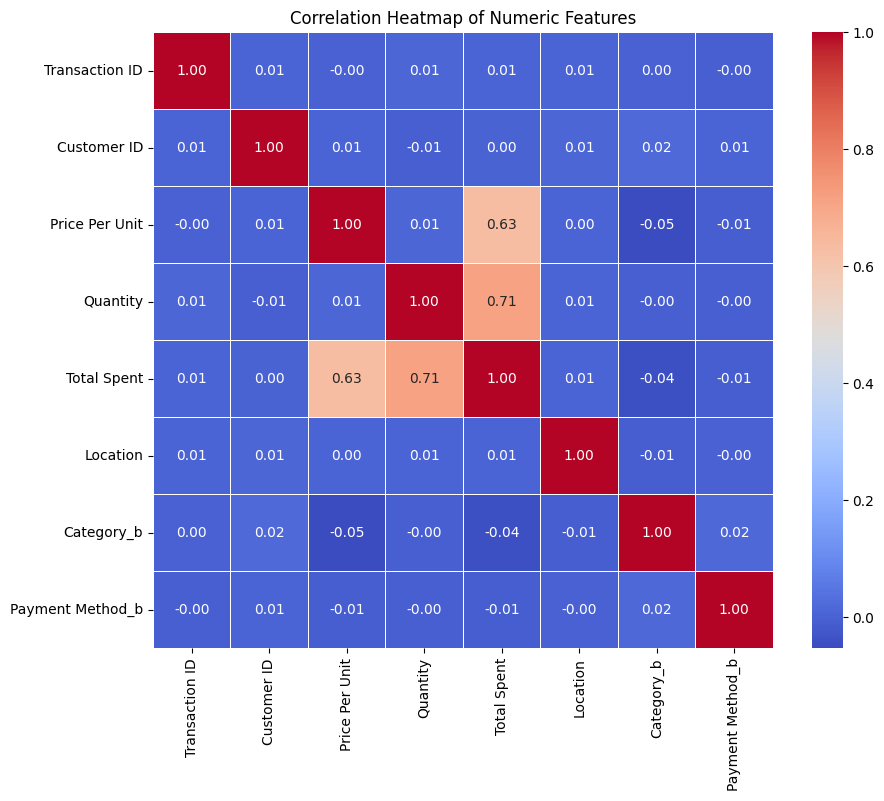

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

Columns to plot: ['Transaction ID', 'Customer ID', 'Price Per Unit', 'Quantity', 'Total Spent', 'Location', 'Category_b', 'Payment Method_b']
Shape: (12575, 8)


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

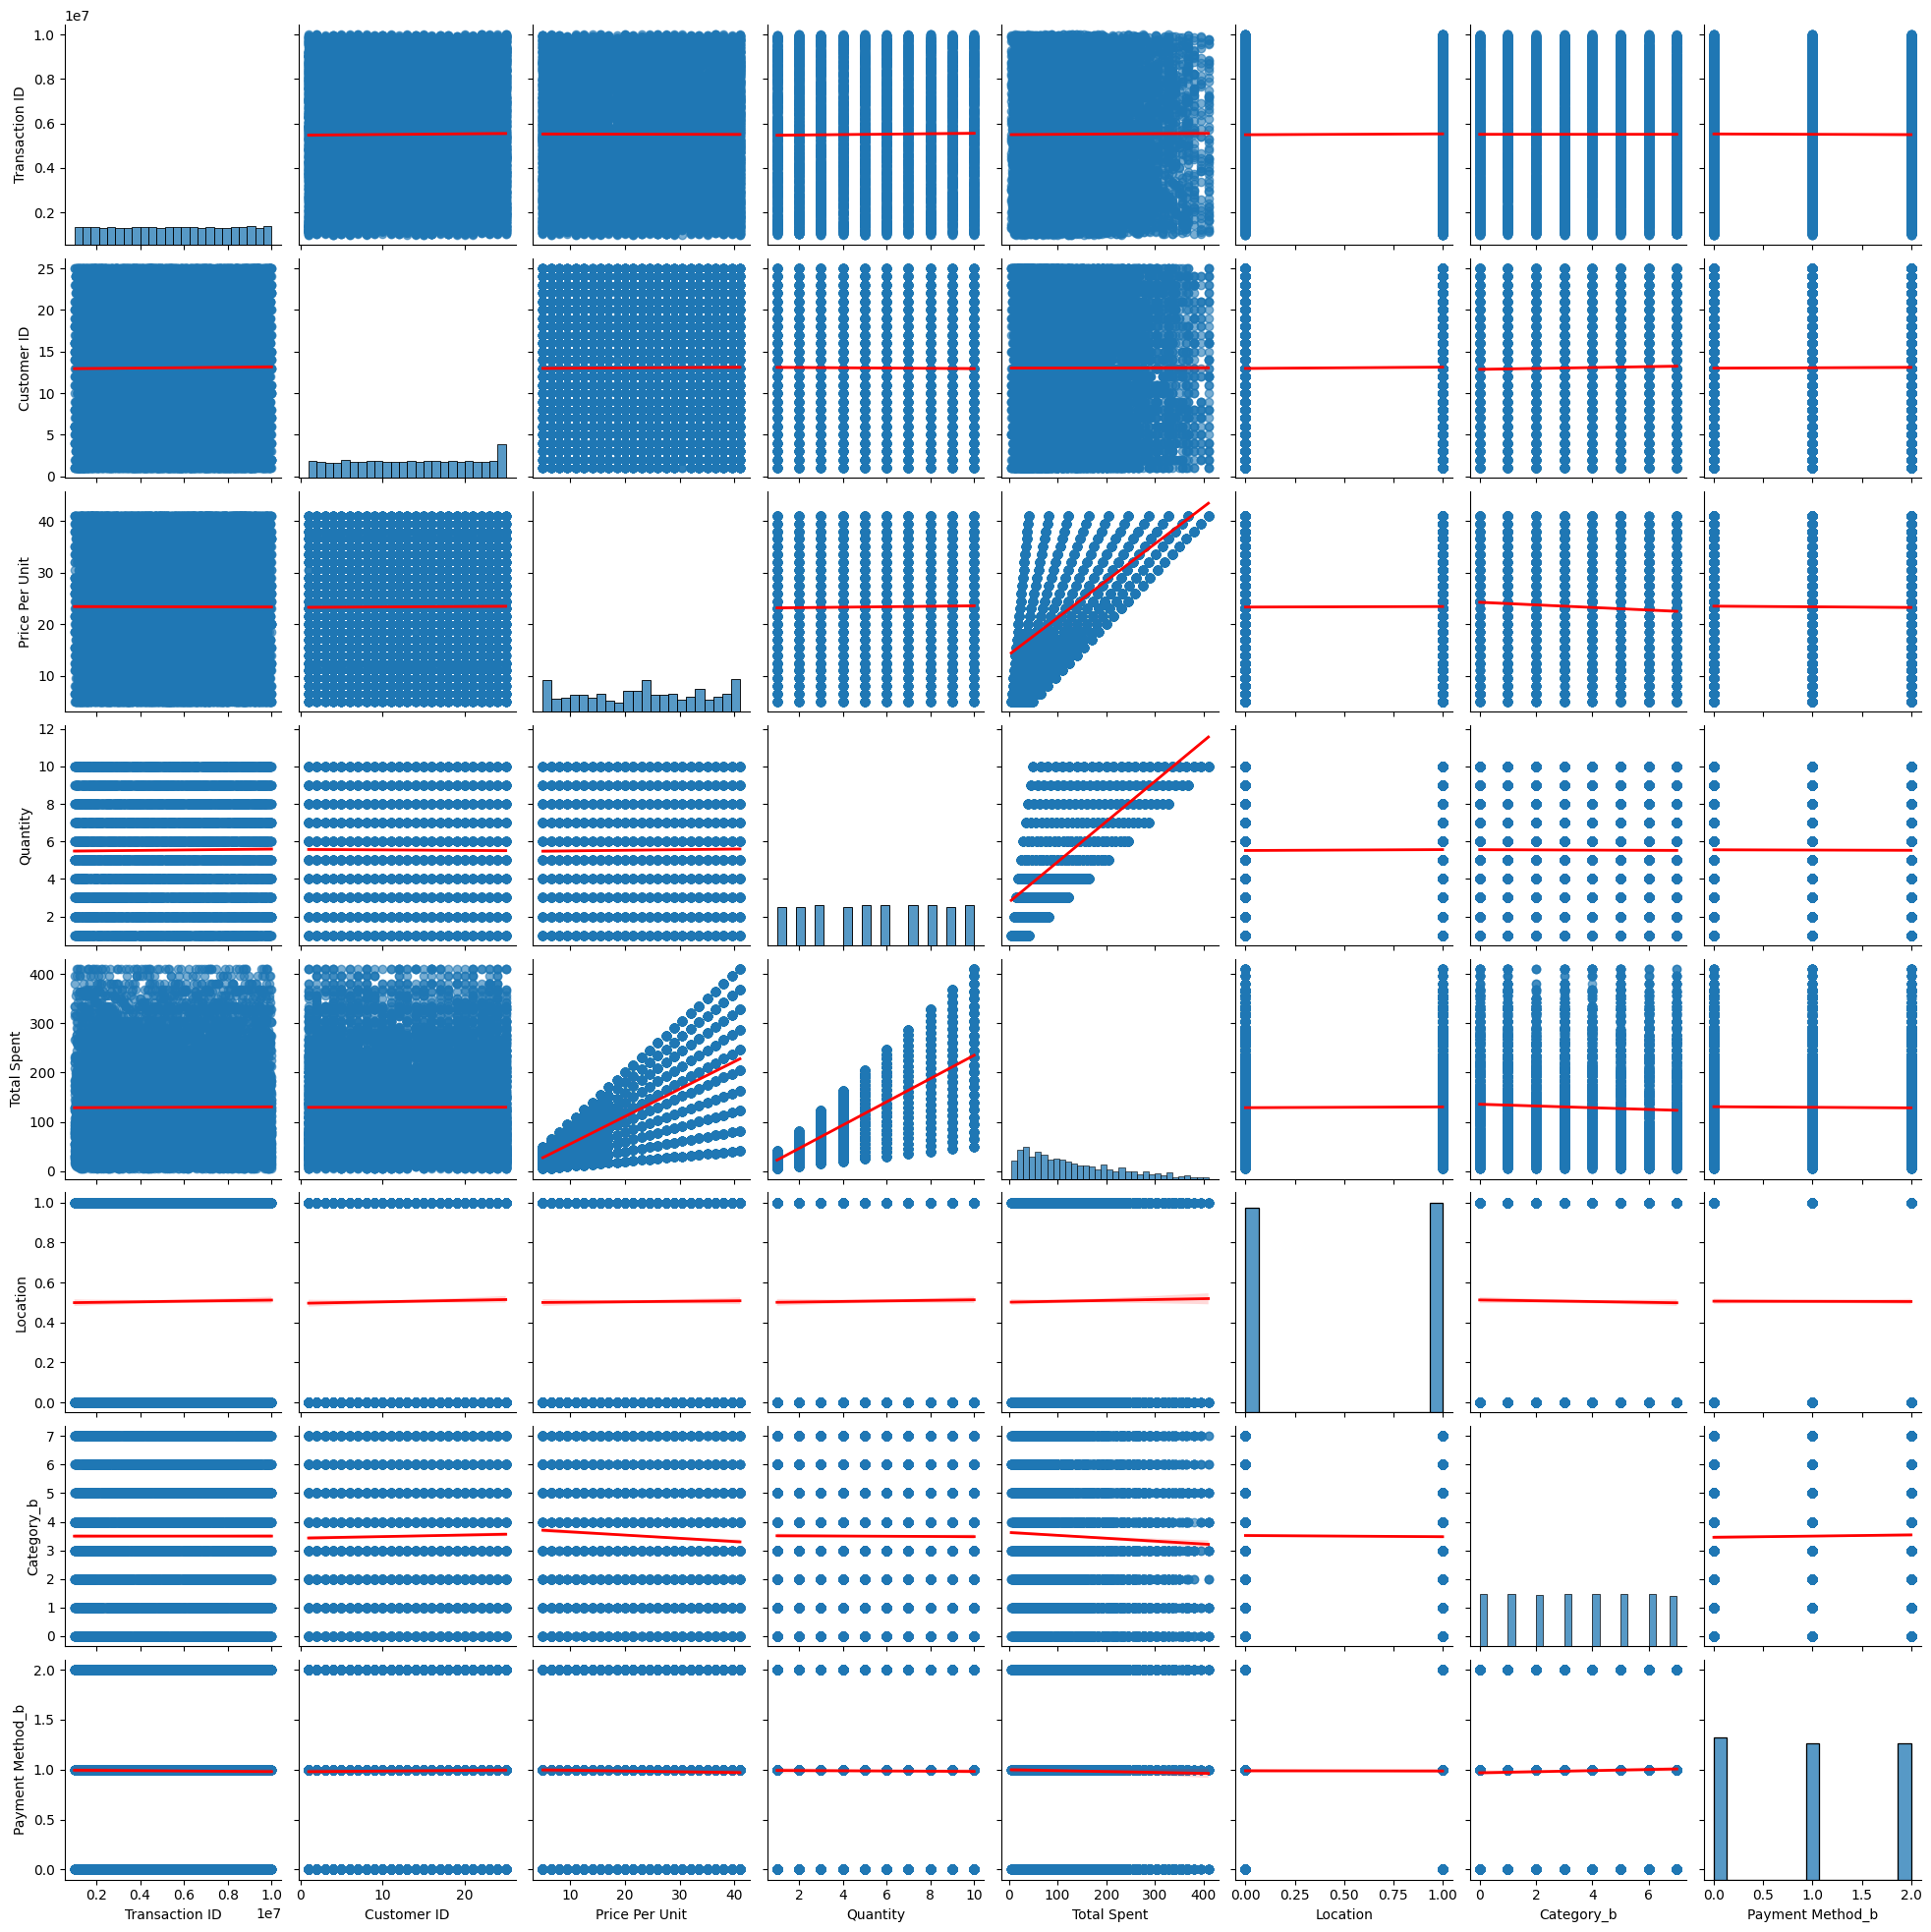

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

numeric_df = df.select_dtypes(include=[np.number]).copy()

bool_cols = df.select_dtypes(include=['bool']).columns
numeric_df = numeric_df.drop(columns=bool_cols, errors='ignore')

print(f"Columns to plot: {numeric_df.columns.tolist()}")
print(f"Shape: {numeric_df.shape}")

sns.pairplot(numeric_df, kind='reg',
             plot_kws={'scatter_kws': {'alpha': 0.6}, 
                      'line_kws': {'color': 'red', 'linewidth': 2}},
             height=2.5)

plt.show()

In [20]:
import numpy as np

corr = numeric_df.corr()

corr_no_self = corr.where(~np.eye(corr.shape[0], dtype=bool))

sorted_corr = corr_no_self.abs().unstack().sort_values(ascending=False)

sorted_corr = sorted_corr[sorted_corr.index.get_level_values(0) != sorted_corr.index.get_level_values(1)]
sorted_corr = sorted_corr[~sorted_corr.duplicated()]

top_10 = sorted_corr.head(10)

print("Top 3 highest correlated pairs:")
for (feat1, feat2), value in top_10.items():
    actual_value = corr.loc[feat1, feat2]
    print(f"{feat1} and {feat2}: correlation = {actual_value:.2f}")

Top 3 highest correlated pairs:
Quantity and Total Spent: correlation = 0.71
Total Spent and Price Per Unit: correlation = 0.63
Price Per Unit and Category_b: correlation = -0.05
Total Spent and Category_b: correlation = -0.04
Customer ID and Category_b: correlation = 0.02
Payment Method_b and Category_b: correlation = 0.02
Price Per Unit and Quantity: correlation = 0.01
Customer ID and Location: correlation = 0.01
Quantity and Transaction ID: correlation = 0.01
Total Spent and Payment Method_b: correlation = -0.01


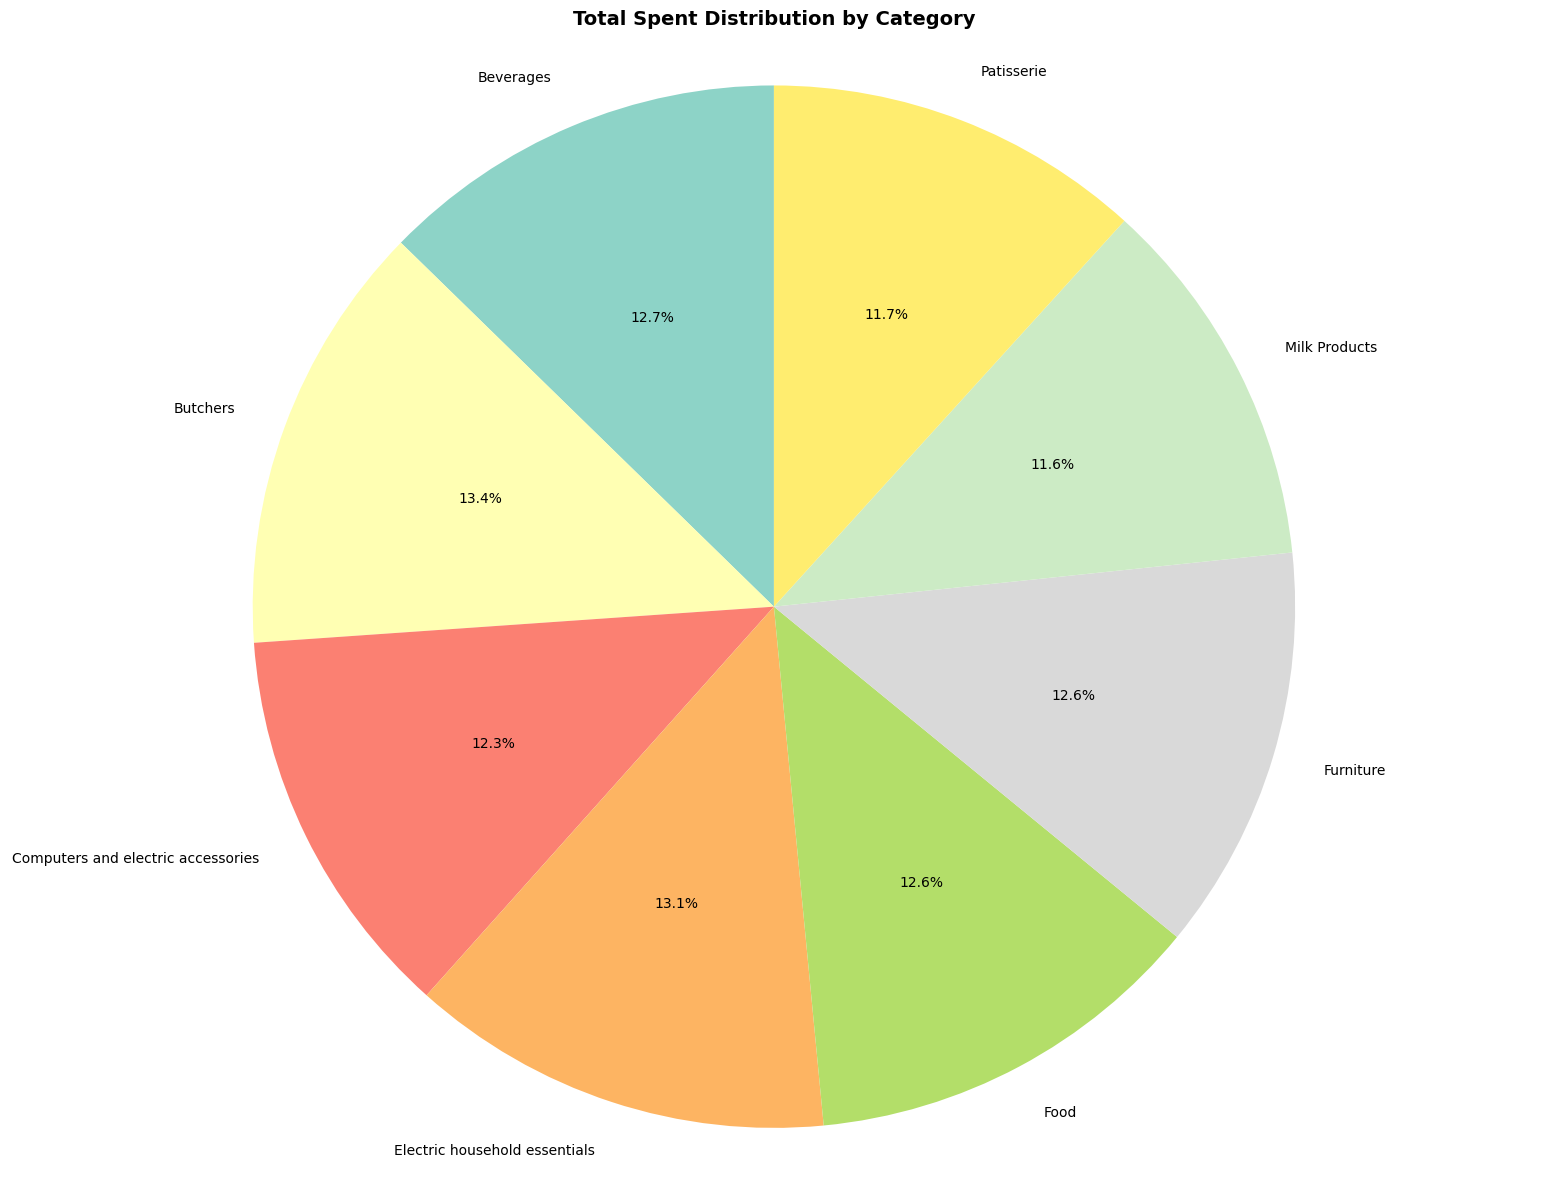

In [21]:
df_item = df.groupby('Category')['Total Spent'].sum().reset_index()

plt.figure(figsize=(16, 12))
plt.pie(df_item['Total Spent'], labels=df_item['Category'], autopct='%1.1f%%', 
        startangle=90, colors=plt.cm.Set3(np.linspace(0, 1, len(df_item))))
plt.title('Total Spent Distribution by Category', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [22]:
# total spent & price per unit
# total spent & quntity
# item_SubCategory & total spent
# item_SubCategory & price per unit

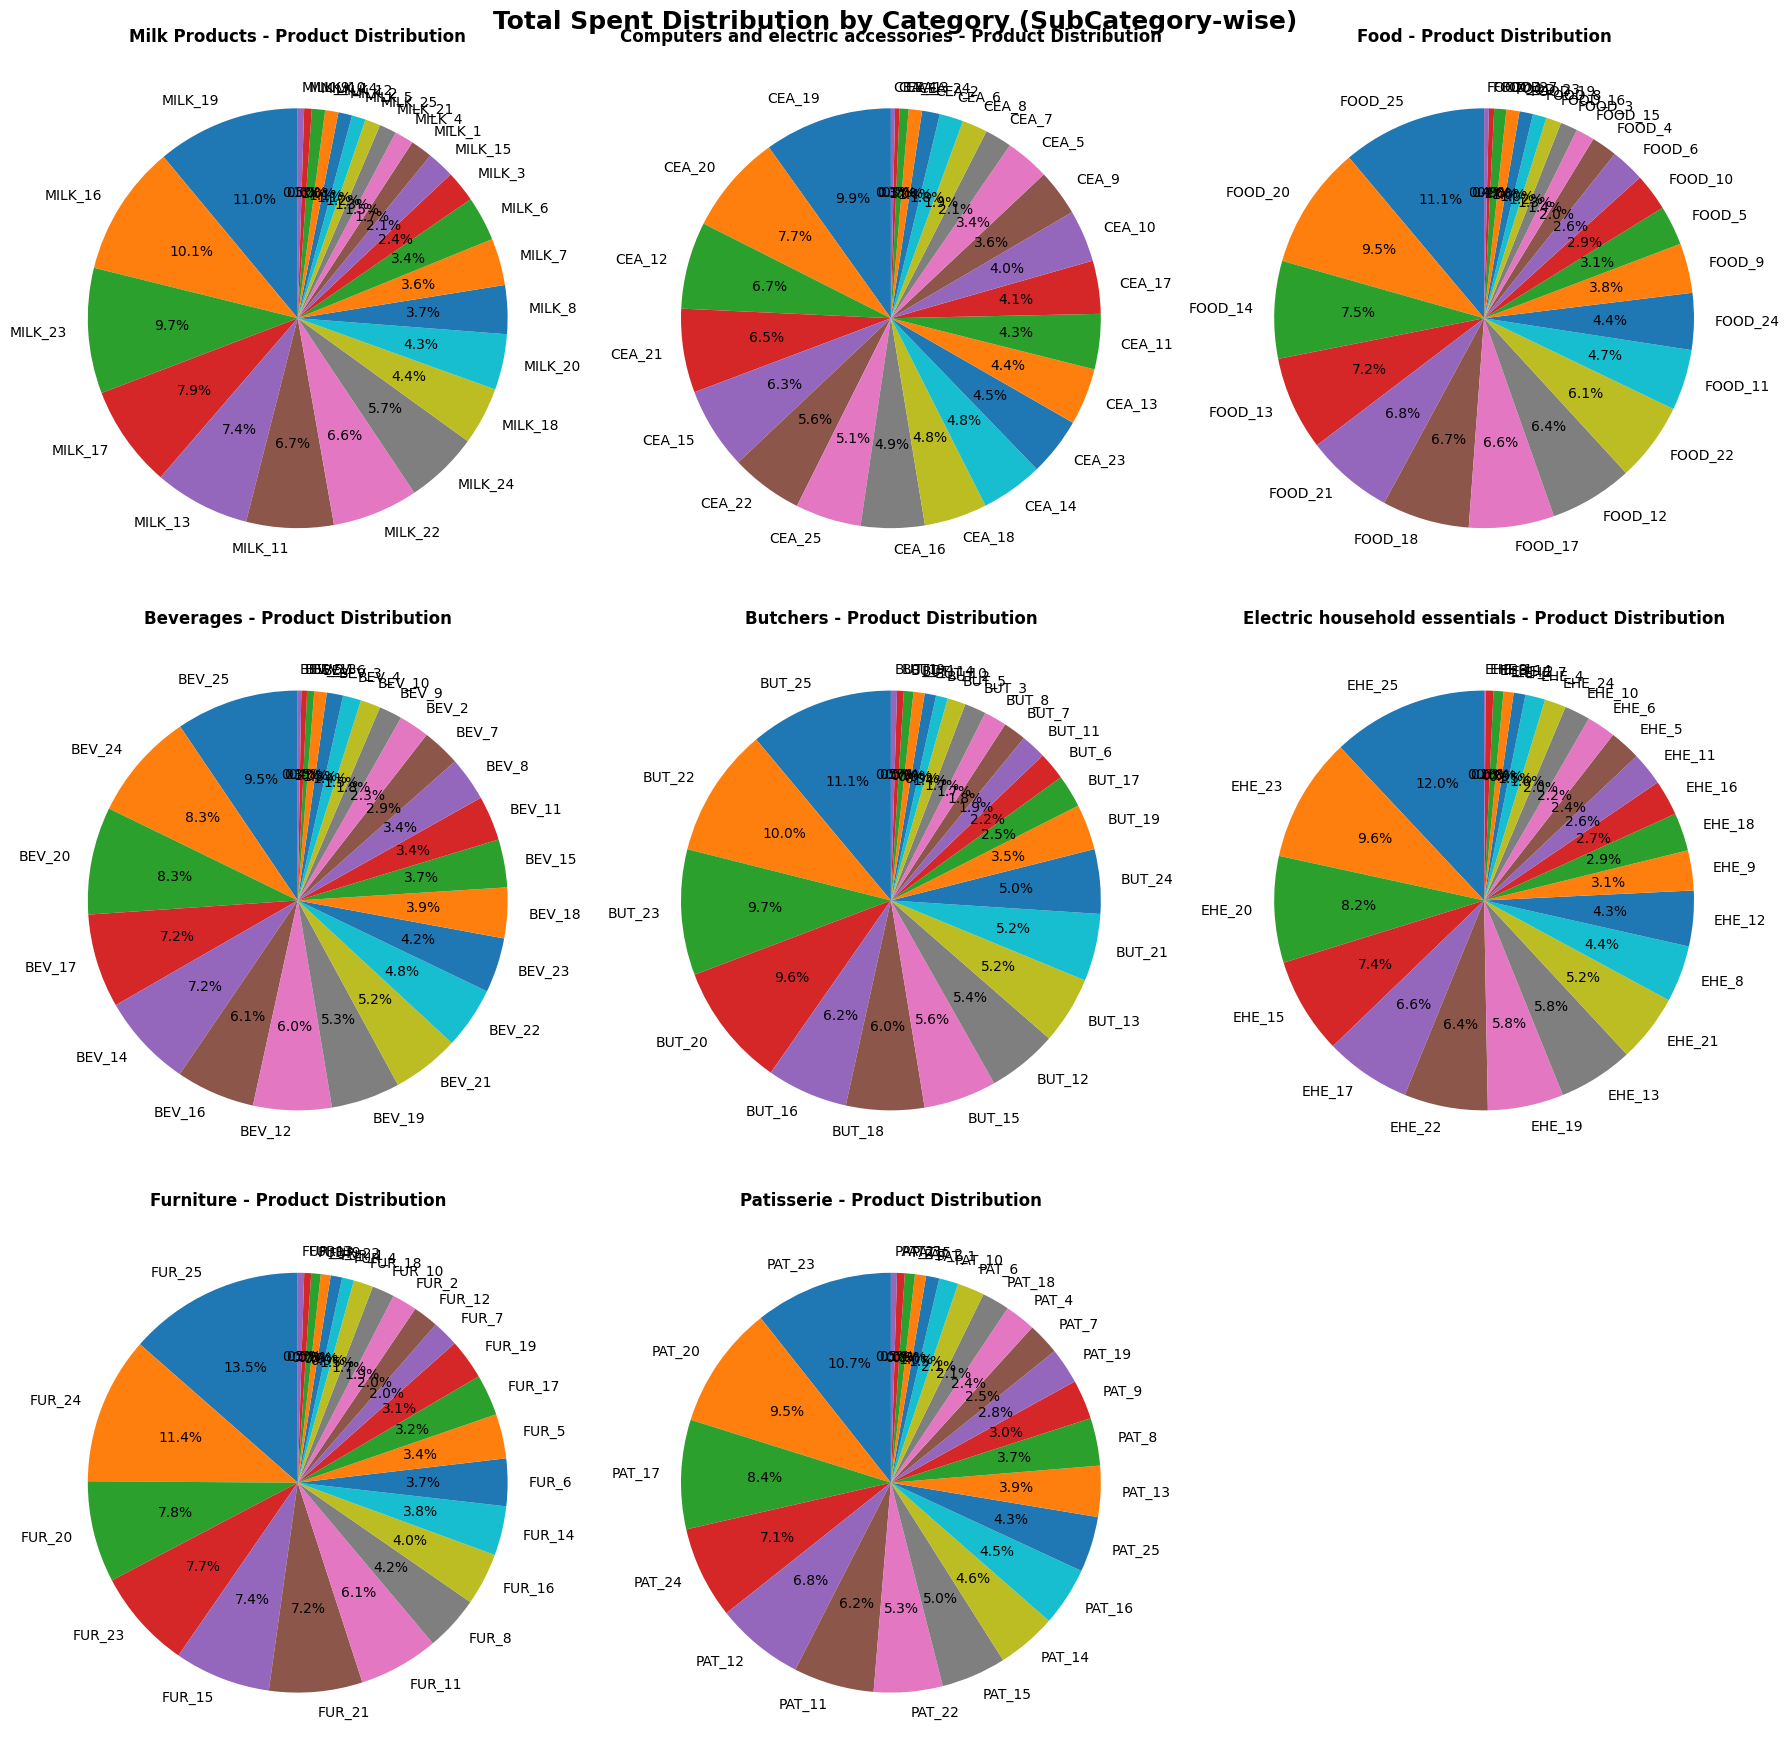

In [23]:
# item_SubCategory , Total Spent -> pie chart 
# subplots by item_SubCategory

import matplotlib.pyplot as plt
import math

categories = df['Category'].dropna().unique()
n = len(categories)

cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
axes = axes.flatten()

for i, Category in enumerate(categories):
    df_item_SubCategory = (
        df[df['Category'] == Category]
        .groupby('item_SubCategory')['Total Spent']
        .sum()
        .sort_values(ascending=False)
    )
    
    axes[i].pie(
        df_item_SubCategory.values,
        labels=df_item_SubCategory.index,
        autopct='%1.1f%%',
        startangle=90
    )
    
    axes[i].set_title(f'{Category} - Product Distribution', fontweight='bold')
    axes[i].axis('equal')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(
    'Total Spent Distribution by Category (SubCategory-wise)',
    fontsize=18,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

In [24]:
"""
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize=(28, 24))
n_categories = df['item_SubCategory'].nunique()

fig_height = max(6, n_categories * 0.5)
fig_width = 14

plt.figure(figsize=(fig_width, fig_height))

sns.barplot(data= df, y='item_SubCategory', x='Total Spent', hue='Quantity', orient='h')

plt.title('Sum of Amount by item_SubCategory and Quantity')
plt.ylabel('item_SubCategory')
plt.xlabel('Total Spent')
plt.legend(title='Quantity', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
"""

"\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\n#plt.figure(figsize=(28, 24))\nn_categories = df['item_SubCategory'].nunique()\n\nfig_height = max(6, n_categories * 0.5)\nfig_width = 14\n\nplt.figure(figsize=(fig_width, fig_height))\n\nsns.barplot(data= df, y='item_SubCategory', x='Total Spent', hue='Quantity', orient='h')\n\nplt.title('Sum of Amount by item_SubCategory and Quantity')\nplt.ylabel('item_SubCategory')\nplt.xlabel('Total Spent')\nplt.legend(title='Quantity', bbox_to_anchor=(1.05, 1), loc='upper left')\n\nplt.tight_layout()\nplt.show()\n"

In [25]:
## total spent & quntity -> x-axis: item_SubCategory , y-axis: Total Spent , hue:Quantity
import plotly.express as px

df_plot = df.groupby('item_SubCategory', as_index=False).agg({
    'Total Spent': 'sum',
    'Quantity': 'sum'
})

fig = px.bar(
    df_plot,
    x='item_SubCategory',
    y='Total Spent',
    color='Quantity',
    color_continuous_scale='Viridis',
    title='Total Spent by Item SubCategory (Color = Quantity)'
)

fig.update_layout(
    xaxis_title='Item SubCategory',
    yaxis_title='Total Spent',
    xaxis_tickangle=45,
    height=600,
    width=1200
)

fig.show()

In [26]:
import plotly.express as px
import pandas as pd

df_grouped = df.groupby(['Category', 'item_SubCategory', 'Discount Applied'])['Total Spent'].sum().reset_index()

total_per_subcat = df.groupby(['Category', 'item_SubCategory'])['Total Spent'].sum().reset_index()
total_per_subcat.columns = ['Category', 'item_SubCategory', 'Total_For_Sorting']

df_grouped = df_grouped.merge(total_per_subcat, on=['Category', 'item_SubCategory'])

df_grouped = df_grouped.sort_values(['Category', 'Total_For_Sorting'], ascending=[True, False])

df_grouped['Category_SubCategory'] = df_grouped['Category'] + ' - ' + df_grouped['item_SubCategory']

y_order = df_grouped.drop_duplicates('Category_SubCategory')['Category_SubCategory'].tolist()

fig = px.bar(
    df_grouped,
    y='Category_SubCategory',
    x='Total Spent',
    color='Discount Applied',
    orientation='h',
    title='<b>All SubCategories by Category (Sorted by Total Spent within Category)</b>',
    height=max(1200, len(y_order) * 25),
    width=1400,
    barmode='group',
    color_discrete_map={True: '#2ecc71', False: '#e74c3c'}
)

fig.update_layout(
    xaxis_title='<b>Total Spent ($)</b>',
    yaxis_title='<b>Category - SubCategory</b>',
    legend_title='<b>Discount Applied</b>',
    template='plotly_white',
    yaxis=dict(
        categoryorder='array',
        categoryarray=y_order,
        tickfont=dict(size=9),
        automargin=True
    ),
    xaxis=dict(tickformat='$,.0f'),
    bargap=0.15,
    bargroupgap=0.05,
    margin=dict(l=300, r=50, t=80, b=50)
)

fig.show()

/tmp/ipykernel_47/1713800938.py:8: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.


/tmp/ipykernel_47/1713800938.py:22: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.



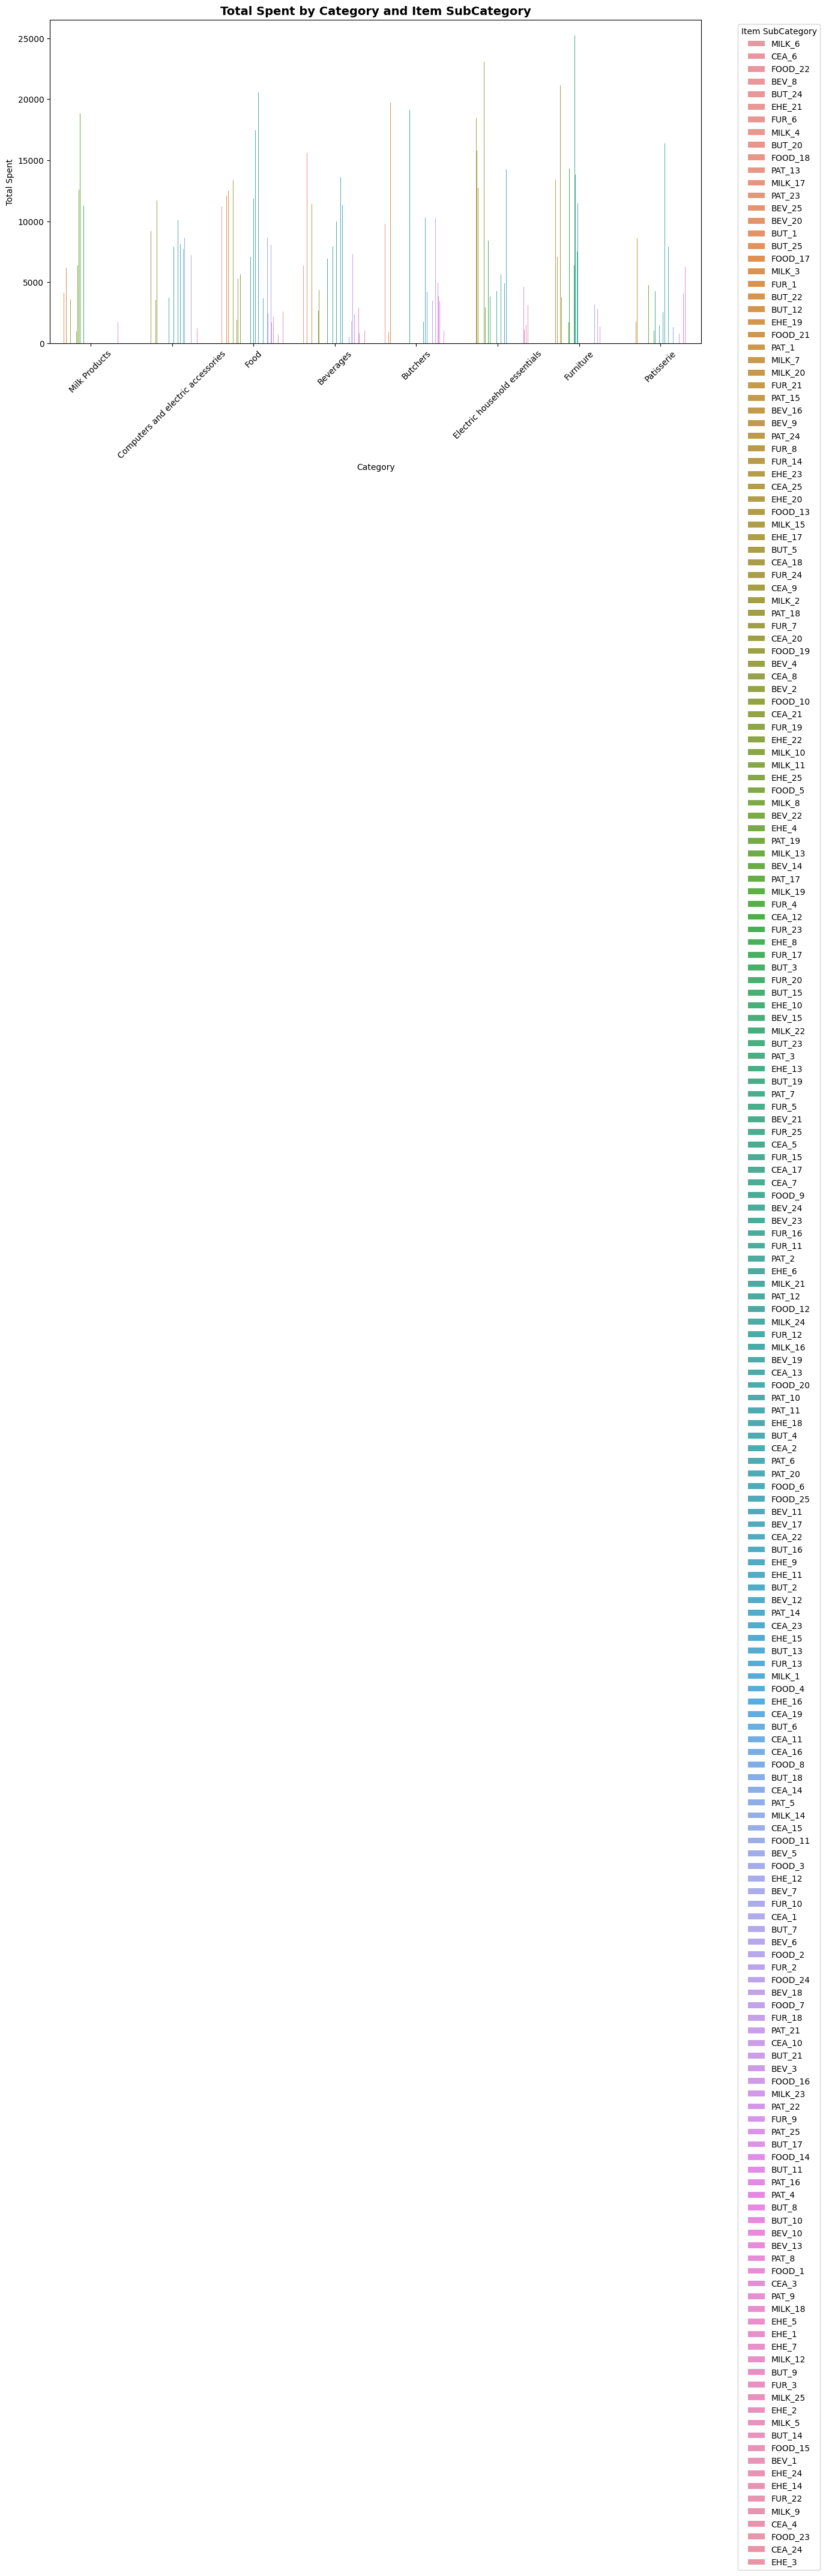

In [27]:
#x-axis : Category , y-axis:Total Spent , hue:item_SubCategory (bar)(not barh)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

sns.barplot(
    data=df,
    x='Category',
    y='Total Spent',
    hue='item_SubCategory',
    estimator=sum,
    ci=None
)

plt.title('Total Spent by Category and Item SubCategory', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Spent')
plt.xticks(rotation=45)
plt.legend(title='Item SubCategory', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [28]:
df_sorted = df.sort_values(by='item_SubCategory').copy()
df_sorted['Quantity'] = df_sorted['Quantity'].astype(str)

import plotly.express as px

fig = px.bar(
    df_sorted,
    x='item_SubCategory',
    y='Total Spent',
    color='Quantity',          
    #orientation='h',
    barmode='group',           
    title='Total Spent by Item SubCategory and Quantity'
)

fig.update_layout(
    yaxis_title='Total Spent',
    xaxis_title='Item SubCategory',
    #height=max(600, df_sorted['item_SubCategory'].nunique() * 30),
    width=5000,
    legend_title_text='Quantity',   
    template='plotly_white'
)

fig.show()

In [29]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

df_sorted = df.sort_values(by=['Category', 'item_SubCategory']).copy()
df_sorted['Quantity'] = df_sorted['Quantity'].astype(str)

categories = sorted(df_sorted['Category'].unique())
quantities = sorted(df_sorted['Quantity'].unique())

n_categories = len(categories)
n_cols = 2
n_rows = (n_categories + 1) // 2

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=[f'<b>{cat}</b>' for cat in categories],
    vertical_spacing=0.12,
    horizontal_spacing=0.10
)

colors = px.colors.qualitative.Set2

for idx, category in enumerate(categories):
    row = idx // n_cols + 1
    col = idx % n_cols + 1
    
    df_cat = df_sorted[df_sorted['Category'] == category]
    
    for q_idx, quantity in enumerate(quantities):
        df_qty = df_cat[df_cat['Quantity'] == quantity]
        
        if len(df_qty) > 0:
            fig.add_trace(
                go.Bar(
                    x=df_qty['item_SubCategory'],
                    y=df_qty['Total Spent'],
                    name=f'Qty: {quantity}',
                    marker_color=colors[q_idx % len(colors)],
                    legendgroup=quantity,
                    showlegend=(idx == 0),  
                    hovertemplate='<b>SubCategory:</b> %{x}<br>' +
                                  f'<b>Quantity:</b> {quantity}<br>' +
                                  '<b>Total Spent:</b> $%{y:,.0f}<extra></extra>'
                ),
                row=row, col=col
            )

fig.update_layout(
    title_text='<b>Total Spent by Item SubCategory and Quantity (By Category)</b>',
    title_font_size=18,
    height=500 * n_rows,
    width=1800,
    barmode='group',
    template='plotly_white',
    showlegend=True,
    legend=dict(
        title='<b>Quantity</b>',
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.01
    )
)

fig.update_xaxes(title_text='Item SubCategory', tickangle=45)
fig.update_yaxes(title_text='Total Spent ($)', tickformat='$,.0f')

fig.show()

In [ ]:
# Customer ID , item_SubCategory , Total Spent        #MAKE SUBPLOTS BY Category!!!  ✓
# item_SubCategory , Discount Applied , Customer ID     #MAKE SUBPLOTS BY Category!!!  ✓
# item_SubCategory , Payment Method , Customer ID         #MAKE SUBPLOTS BY Category!!  ✓

# item_SubCategory , Payment Method , Discount Applied     #MAKE SUBPLOTS BY Category!!!

# Transaction Date , Category , Total Spent -> time line 
# Category , Total Spent , item_SubCategory -> stacked bar
# Price Per Unit , Quantity ,item_SubCategory
"""
# Transaction Date , Category , Discount Applied , Total Spent (stacked bar : Discount Applied)
x-axis: Transaction Date , y-axis:Total Spent , hue:Category (in every hue is divided by Discount Applied
"""
# Transaction Date , Discount Applied , item_SubCategory
# 

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Rectangle

n_cols = 2
categories = sorted(df['Category'].unique())
n_rows = (len(categories) + n_cols - 1) // n_cols

height_per_row = 0.3
max_bars = df.groupby('Category').apply(
    lambda x: len(x['item_SubCategory'].unique()) * len(x['Customer ID'].unique())
).max()

calculated_height = (max_bars * height_per_row * 0.5) * n_rows
fig_height = min(500, max(15, calculated_height))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(24, fig_height), constrained_layout=True)

if n_rows * n_cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]

payment_methods = sorted(df['Payment Method'].unique())
colors = plt.cm.get_cmap('Set3')(np.linspace(0, 1, len(payment_methods)))
color_map = {pm: colors[i] for i, pm in enumerate(payment_methods)}

bg_colors = ['#f0f0f0', '#ffffff']

for idx, category in enumerate(categories):
    ax = axes[idx]
    
    data_cat = df[df['Category'] == category].copy()
    
    subcat_order = data_cat.groupby('item_SubCategory')['Total Spent'].sum().sort_values(ascending=False).index
    
    y_labels = []
    y_positions = []
    group_info = []
    current_pos = 0
    all_data = []
    
    for group_idx, subcat in enumerate(subcat_order):
        group_start = current_pos
        
        subcat_data = data_cat[data_cat['item_SubCategory'] == subcat]
        customers = sorted(subcat_data['Customer ID'].unique())
        
        for customer in customers:
            customer_data = subcat_data[subcat_data['Customer ID'] == customer]
            
            label = f"{customer} - {subcat}"
            y_labels.append(label)
            y_positions.append(current_pos)
            
            payment_totals = customer_data.groupby('Payment Method')['Total Spent'].sum()
            
            all_data.append({
                'label': label,
                'position': current_pos,
                'payments': payment_totals.to_dict()
            })
            
            current_pos += 1
        
        group_end = current_pos - 1
        group_info.append({
            'subcat': subcat,
            'start': group_start,
            'end': group_end,
            'color': bg_colors[group_idx % 2]
        })
    
    for group in group_info:
        rect = Rectangle(
            (ax.get_xlim()[0], group['start'] - 0.5),
            ax.get_xlim()[1] - ax.get_xlim()[0],
            group['end'] - group['start'] + 1,
            facecolor=group['color'],
            alpha=0.3,
            zorder=0
        )
        ax.add_patch(rect)
    
    bottom_values = np.zeros(len(all_data))
    
    for payment in payment_methods:
        values = [item['payments'].get(payment, 0) for item in all_data]
        
        ax.barh(
            y_positions,
            values,
            left=bottom_values,
            height=0.8,
            label=payment,
            color=color_map[payment],
            zorder=3
        )
        
        bottom_values += values
    
    for group in group_info[:-1]:
        ax.axhline(y=group['end'] + 0.5, color='darkblue', linewidth=2.5, 
                  linestyle='-', alpha=0.8, zorder=4)
    
    for group in group_info:
        mid_point = (group['start'] + group['end']) / 2
        # Add text on the right side
        ax.text(ax.get_xlim()[1] * 0.98, mid_point, group['subcat'], 
               fontsize=11, fontweight='bold', ha='right', va='center',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
               zorder=5)
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=9)
    
    ax.set_title(f"Category: {category}", fontsize=22, fontweight='bold', pad=25)
    ax.set_xlabel("Total Spent ($)", fontsize=16, fontweight='bold')
    ax.set_ylabel("Customer ID - SubCategory", fontsize=16, fontweight='bold')
    
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=1)
    
    ax.legend(title="Payment Method", loc='lower right', frameon=True, 
             fontsize=10, title_fontsize=11)

for i in range(len(categories), len(axes)):
    axes[i].axis('off')

plt.suptitle('Total Spent by Customer & SubCategory (Grouped by SubCategory)', 
             fontsize=24, fontweight='bold', y=0.995)
plt.show()

In [ ]:
df

In [ ]:
## total spent & quntity -> x-axis: item_SubCategory , y-axis: Total Spent , hue:Quantity subplots by Category

import matplotlib.pyplot as plt

categories = df['Category'].unique()
n_category = len(categories)
n_rows = (n_category + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 8 * n_rows))
axes = axes.flatten()

handles, labels = None, None

for idx, category in enumerate(categories):
    ax = axes[idx]

    data_category = df[df['Category'] == category]

    pivot_data = data_category.pivot_table(
        index='item_SubCategory',
        columns='Quantity',
        values='Total Spent',
        aggfunc='sum'
    )

    pivot_data.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        legend=False
    )

    ax.set_title(f"Total Spent by Quantity – {category}")
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Item SubCategory")

    if handles is None:
        handles, labels = ax.get_legend_handles_labels()

for idx in range(n_category, len(axes)):
    axes[idx].axis('off')

fig.legend(handles, labels, title="Quantity", loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# y-axis:Customer ID , hue:item_SubCategory , x-axis:Total Spent , subplots by : Category

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categories = df['Category'].unique()
n_category = len(categories)
n_rows = (n_category + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 8 * n_rows))
axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]

    data_cat = df[df['Category'] == category]

    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns='item_SubCategory',
        values='Total Spent',
        aggfunc='sum'
    )

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(f"Total Spent by Customer – {category}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Customer ID")

    ax.legend(
        title="Item SubCategory",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
df

In [ ]:
#y-axis: customed id , x-axis: total spent , hue: payment methode,Discount Applied , subplot by Category

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import re

def extract_number(cid):
    nums = re.findall(r'\d+', str(cid))
    return int(nums[0]) if nums else 0

df_copy = df.copy()
df_copy['Customer_Num'] = df_copy['Customer ID'].apply(extract_number)

categories = sorted(df_copy['Category'].unique())
payment_methods = sorted(df_copy['Payment Method'].unique())

# Aggregate
df_agg = df_copy.groupby(
    ['Category', 'Customer ID', 'Customer_Num', 'Payment Method', 'Discount Applied'],
    as_index=False
)['Total Spent'].sum()

n_cols = 2
n_rows = (len(categories) + 1) // 2

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=[f'<b>{cat}</b>' for cat in categories],
    vertical_spacing=0.12,
    horizontal_spacing=0.10
)

base_colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756']
color_map = dict(zip(payment_methods, base_colors))

for idx, category in enumerate(categories):
    row = idx // n_cols + 1
    col = idx % n_cols + 1

    data_cat = df_agg[df_agg['Category'] == category]

    customer_order = (
        data_cat[['Customer ID', 'Customer_Num']]
        .drop_duplicates()
        .sort_values('Customer_Num')['Customer ID']
    )

    for payment in payment_methods:
        for discount in [False, True]:
            subset = data_cat[
                (data_cat['Payment Method'] == payment) &
                (data_cat['Discount Applied'] == discount)
            ]

            if subset.empty:
                continue

            subset = (
                subset.set_index('Customer ID')
                .reindex(customer_order, fill_value=0)
                .reset_index()
            )

            fig.add_trace(
                go.Bar(
                    y=subset['Customer ID'],
                    x=subset['Total Spent'],
                    orientation='h',
                    name=f'{payment} ({"Disc" if discount else "No Disc"})',
                    marker=dict(
                        color=color_map[payment],
                        opacity=1.0 if discount else 0.5,
                        pattern=dict(shape='/' if not discount else ''),
                        line=dict(width=0.5, color='white')
                    ),
                    showlegend=(idx == 0),
                    hovertemplate=
                        '<b>Customer:</b> %{y}<br>'
                        f'<b>Payment:</b> {payment}<br>'
                        f'<b>Discount:</b> {"Yes" if discount else "No"}<br>'
                        '<b>Total Spent:</b> $%{x:,.0f}<extra></extra>'
                ),
                row=row,
                col=col
            )

fig.update_layout(
    title='<b>Total Spent by Customer, Payment Method & Discount (By Category)</b>',
    height=380 * n_rows,        
    width=1200,                
    barmode='stack',
    template='plotly_white',
    legend_title='<b>Payment & Discount</b>',
    legend=dict(
        y=1,
        x=1.02,
        font=dict(size=9)
    )
)

fig.update_xaxes(title_text='Total Spent ($)', tickformat='$,.0f')
fig.update_yaxes(title_text='Customer ID', categoryorder='array')

fig.show()

In [ ]:
##x-axis: Customer ID , y-axis: item_SubCategory , hue:Discount Applied , subplotby:Category

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categories = df['Category'].unique()
n_category = len(categories)
n_rows = (n_category + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(18, 8 * n_rows))
axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]

    data_cat = df[df['Category'] == category]

    pivot_df = data_cat.pivot_table(
        index='item_SubCategory',
        columns='Discount Applied',
        values='Customer ID',  
        aggfunc='count',
        fill_value=0
    )

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.85
    )

    ax.set_title(f"Discount Usage by Item SubCategory – {category}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Number of Transactions")
    ax.set_ylabel("Item SubCategory")

    ax.legend(
        title="Discount Applied",
        loc='upper right',
        fontsize=9,
        title_fontsize=10
    )

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#y-axis: customed id , x-axis: total spent , hue: payment methode,Discount Applied , subplot by Category

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categories = sorted(df['Category'].dropna().unique())
n_category = len(categories)

n_cols = 2
n_rows = int(np.ceil(n_category / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 7 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

df['Payment_Discount'] = (
    df['Payment Method'].astype(str) +
    ' | Discount: ' +
    df['Discount Applied'].map({True: 'Yes', False: 'No'}).astype(str)
)

for idx, category in enumerate(categories):
    ax = axes[idx]

    data_cat = df[df['Category'] == category].copy()

    data_cat['Customer ID'] = data_cat['Customer ID'].astype(str)
    customer_order = sorted(data_cat['Customer ID'].unique())

    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns='Payment_Discount',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    ).reindex(customer_order)

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.85
    )

    ax.set_title(
        f"Total Spent by Customer – {category}",
        fontsize=13,
        fontweight='bold'
    )
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Customer ID")

    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.legend(
        title="Payment Method | Discount",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
df

In [ ]:
#y-axis: customed id , x-axis: total spent , hue:( payment methode,Discount Applied) , subplot by Category
#heu : payment methode-Discount Applied (make a combination of 2 columns to be 1 column)

In [ ]:
df

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df['Customer ID'] = df['Customer ID'].astype(str)

categories = sorted(df['Category'].dropna().unique())
n_category = len(categories)

n_cols = 2
n_rows = int(np.ceil(n_category / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 6 * n_rows),
    sharex=False,
    sharey=False
)
axes = axes.flatten()

legend_handles = None
legend_labels = None

for idx, category in enumerate(categories):
    ax = axes[idx]

    data_cat = df[df['Category'] == category]

    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    ).sort_index()

    pivot_df.plot(
        kind='barh',
        ax=ax,
        width=0.75
    )

    ax.set_title(f"Category: {category}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Total Spent ($)")
    ax.set_ylabel("Customer ID")

    ax.grid(axis='x', linestyle='--', alpha=0.4)

    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.legend_.remove()

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

fig.legend(
    legend_handles,
    legend_labels,
    title="Payment Method",
    loc='center left',
    bbox_to_anchor=(0.92, 0.5),  # right side
    frameon=True
)

plt.subplots_adjust(right=0.88, hspace=0.35)

plt.show()

In [ ]:
"""
import plotly.graph_objects as go
import pandas as pd

# Aggregate ALL data (no filtering)
df_grouped = df.groupby(['item_SubCategory', 'Customer ID'], as_index=False)['Total Spent'].sum()

# Sort
subcat_order = df_grouped.groupby('item_SubCategory')['Total Spent'].sum().sort_values(ascending=True).index.tolist()

# Pivot
df_pivot = df_grouped.pivot(index='item_SubCategory', columns='Customer ID', values='Total Spent').fillna(0)
df_pivot = df_pivot.reindex(subcat_order)

# Create figure
fig = go.Figure()

customers = df_pivot.columns
colors = px.colors.qualitative.Set3

for idx, customer in enumerate(customers):
    fig.add_trace(go.Bar(
        y=df_pivot.index,
        x=df_pivot[customer],
        name=str(customer),
        orientation='h',
        marker_color=colors[idx % len(colors)],
        hovertemplate='<b>SubCategory:</b> %{y}<br>' +
                      f'<b>Customer:</b> {customer}<br>' +
                      '<b>Total:</b> $%{x:,.0f}<extra></extra>'
    ))

# Calculate dynamic height (more space per category)
n_subcats = len(df_pivot)
dynamic_height = max(800, n_subcats * 25)  # 25 pixels per subcategory

fig.update_layout(
    title='<b>Total Spent by SubCategory and Customer (All Data - Scroll to View)</b>',
    yaxis_title='<b>Item SubCategory</b>',
    xaxis_title='<b>Total Spent ($)</b>',
    barmode='group',
    template='plotly_white',
    height=dynamic_height,  # Dynamic height based on data
    width=1500,
    legend_title='<b>Customer ID</b>',
    xaxis=dict(tickformat='$,.0f'),
    yaxis=dict(
        tickfont=dict(size=8),  # Smaller font
        categoryorder='array',
        categoryarray=subcat_order
    ),
    legend=dict(
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.01,
        font=dict(size=8)
    ),
    bargap=0.1,
    bargroupgap=0.05
)

fig.show()
"""

In [ ]:
# item_SubCategory , Payment Method , Customer ID
"""
import plotly.express as px
import pandas as pd

# Aggregate: count transactions or sum Total Spent
df_agg = df.groupby(['Customer ID', 'item_SubCategory', 'Payment Method'], as_index=False)['Total Spent'].sum()

# Filter to top customers
top_customers = df.groupby('Customer ID')['Total Spent'].sum().index
df_top = df_agg[df_agg['Customer ID'].isin(top_customers)]

# Filter to top subcategories
top_subcats = df.groupby('item_SubCategory')['Total Spent'].sum().index
df_top = df_top[df_top['item_SubCategory'].isin(top_subcats)]

# Sort subcategories by total spent
subcat_order = df_top.groupby('item_SubCategory')['Total Spent'].sum().sort_values(ascending=True).index

# Create stacked horizontal bar chart
fig = px.bar(
    df_top,
    y='item_SubCategory',
    x='Total Spent',
    color='Customer ID',
    orientation='h',
    title='<b>Total Spent by SubCategory & Customer (Stacked by Payment Method)</b>',
    labels={
        'item_SubCategory': 'Item SubCategory',
        'Total Spent': 'Total Spent ($)',
        'Customer ID': 'Customer ID'
    },
    height=max(800, len(subcat_order) * 40),
    width=1500,
    barmode='stack',
    facet_col='Payment Method',
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_layout(
    yaxis_title='<b>Item SubCategory</b>',
    xaxis_title='<b>Total Spent ($)</b>',
    legend_title='<b>Customer ID</b>',
    template='plotly_white',
    yaxis=dict(
        categoryorder='array',
        categoryarray=subcat_order.tolist(),
        tickfont=dict(size=10)
    ),
    xaxis=dict(tickformat='$,.0f')
)

fig.show()
"""

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_agg = df.groupby(['Customer ID', 'item_SubCategory', 'Payment Method'], as_index=False)['Total Spent'].sum()

top_subcats = df.groupby('item_SubCategory')['Total Spent'].sum().nlargest(15).index
df_top = df_agg[df_agg['item_SubCategory'].isin(top_subcats)]

payment_methods = sorted(df_top['Payment Method'].unique())
n_payment = len(payment_methods)

fig, axes = plt.subplots(1, n_payment, figsize=(8 * n_payment, 12), sharey=True)

if n_payment == 1:
    axes = [axes]

subcat_order = df_top.groupby('item_SubCategory')['Total Spent'].sum().sort_values(ascending=True).index

customers = sorted(df_top['Customer ID'].unique())
colors = plt.cm.Set3(np.linspace(0, 1, len(customers)))
color_map = {customer: colors[i] for i, customer in enumerate(customers)}

for idx, payment in enumerate(payment_methods):
    ax = axes[idx]
    
    data_payment = df_top[df_top['Payment Method'] == payment]
    
    pivot_df = data_payment.pivot_table(
        index='item_SubCategory',
        columns='Customer ID',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )
    
    pivot_df = pivot_df.reindex(subcat_order, fill_value=0)
    
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8,
        color=[color_map.get(col, 'gray') for col in pivot_df.columns],
        legend=(idx == 0)
    )
    
    ax.set_title(f'Payment Method: {payment}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Total Spent ($)', fontsize=12, fontweight='bold')
    
    if idx == 0:
        ax.set_ylabel('Item SubCategory', fontsize=12, fontweight='bold')
        ax.legend(title='Customer ID', fontsize=9, title_fontsize=10, 
                 bbox_to_anchor=(1.02, 1), loc='upper left')
    
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [ ]:
#subplots by Payment Method , y-axis:item_SubCategory , x-axis: Customer ID , hue: discount



In [ ]:
""""
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# --- 1. SETTINGS ---
payment_methods = sorted(df['Payment Method'].unique())
n_payment = len(payment_methods)
n_cols = 2
n_rows = (n_payment + n_cols - 1) // n_cols

# Aggregate
df_agg = df.groupby(['Payment Method', 'item_SubCategory', 'Customer ID', 'Discount Applied'], 
                     as_index=False)['Total Spent'].sum()

# Calculate height
max_subcats = df_agg.groupby('Payment Method')['item_SubCategory'].nunique().max()
calculated_height = max(12, max_subcats * 0.5 * n_rows)
fig_height = min(500, calculated_height)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, fig_height), constrained_layout=True)

if n_rows * n_cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]

# Colors
colors = {True: '#2ecc71', False: '#e74c3c'}
markers = {True: 'o', False: 's'}  # Circle for discount, square for no discount

# --- 2. PLOTTING ---
for idx, payment in enumerate(payment_methods):
    ax = axes[idx]
    
    data_payment = df_agg[df_agg['Payment Method'] == payment]
    
    # Plot scatter points
    for discount in [False, True]:
        disc_data = data_payment[data_payment['Discount Applied'] == discount]
        
        if len(disc_data) > 0:
            ax.scatter(
                disc_data['Customer ID'],
                disc_data['item_SubCategory'],
                s=disc_data['Total Spent'] / 10,  # Size based on spending
                c=colors[discount],
                marker=markers[discount],
                alpha=0.6,
                edgecolors='black',
                linewidth=0.5,
                label=f"{'With' if discount else 'No'} Discount"
            )
    
    # Formatting
    ax.set_title(f"Payment: {payment}", fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel("Customer ID", fontsize=13, fontweight='bold')
    ax.set_ylabel("Item SubCategory", fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    if idx == 0:
        ax.legend(title='Discount Applied', loc='best', fontsize=10, title_fontsize=11)

for i in range(n_payment, len(axes)):
    axes[i].axis('off')

plt.suptitle('Customer Purchases by SubCategory (Bubble size = Total Spent)', 
             fontsize=22, fontweight='bold', y=0.998)
plt.show()
"""

In [ ]:
"""
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Aggregate data
df_agg = df.groupby(['Customer ID', 'item_SubCategory', 'Payment Method'], as_index=False)['Total Spent'].sum()

# Filter top subcategories
top_subcats = df.groupby('item_SubCategory')['Total Spent'].sum().index
df_top = df_agg[df_agg['item_SubCategory'].isin(top_subcats)]

# Get unique payment methods
payment_methods = sorted(df_top['Payment Method'].unique())
n_payment = len(payment_methods)
n_cols = 2
n_rows = (n_payment + 1) // 2

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2, 8 * n_rows))
axes = axes.flatten()

# Sort subcategories
subcat_order = df_top.groupby('item_SubCategory')['Total Spent'].sum().sort_values(ascending=True).index

# Colors for customers
customers = sorted(df_top['Customer ID'].unique())
colors = plt.cm.Pastel1(np.linspace(0, 1, len(customers)))

for idx, payment in enumerate(payment_methods):
    ax = axes[idx]
    
    # Filter by payment method
    data_payment = df_top[df_top['Payment Method'] == payment]
    
    # Pivot data
    pivot_df = data_payment.pivot_table(
        index='item_SubCategory',
        columns='Customer ID',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )
    
    # Reindex
    pivot_df = pivot_df.reindex([s for s in subcat_order if s in pivot_df.index], fill_value=0)
    
    # Create stacked bar
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8,
        color=colors[:len(pivot_df.columns)]
    )
    
    ax.set_title(f'Payment Method: {payment}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Total Spent ($)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Item SubCategory', fontsize=11, fontweight='bold')
    ax.legend(title='Customer ID', fontsize=8, title_fontsize=9, 
              bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Hide unused subplots
for i in range(n_payment, len(axes)):
    axes[i].axis('off')

plt.suptitle('Total Spent by SubCategory, Customer & Payment Method', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()
"""

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df_agg = (
    df.groupby(
        ['Category', 'Customer ID', 'item_SubCategory', 'Payment Method'],
        as_index=False
    )['Total Spent']
    .sum()
)

categories = sorted(df_agg['Category'].unique())
n_category = len(categories)

n_cols = 2
n_rows = int(np.ceil(n_category / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(26, 7 * n_rows),   
    constrained_layout=False
)

axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]

    data_cat = df_agg[df_agg['Category'] == category]

    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns=['item_SubCategory', 'Payment Method'],
        values='Total Spent',
        fill_value=0
    ).sort_index()

    pivot_df.plot(
        kind='barh',
        ax=ax,
        width=0.85
    )

    ax.set_title(
        f"Total Spent by Customer — {category}",
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel("Total Spent ($)")
    ax.set_ylabel("Customer ID")
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    ax.legend(
        title="Item SubCategory | Payment Method",
        fontsize=9,
        title_fontsize=10,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),   
        frameon=True
    )

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

fig.subplots_adjust(
    right=0.78,    # ⬅️ key line (space for legend)
    hspace=0.35,
    wspace=0.25
)

plt.show()

In [ ]:
# y-axis: customed id , x-axis: total spent , subplot by :  payment methode , hue:Category (stacked and barH)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df['Customer ID'] = df['Customer ID'].astype(str)

payment_methods = df['Payment Method'].dropna().unique()
n_payment = len(payment_methods)

n_cols = 2
n_rows = int(np.ceil(n_payment / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 7 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for idx, payment in enumerate(payment_methods):
    ax = axes[idx]

    data_pay = df[df['Payment Method'] == payment]

    pivot_df = data_pay.pivot_table(
        index='Customer ID',
        columns='Category',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    pivot_df = pivot_df.sort_index()

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(
        f"Total Spent by Customer\n(Payment Method: {payment})",
        fontsize=13,
        fontweight='bold'
    )
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Customer ID")

    ax.legend(
        title="Category",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

    ax.grid(axis='x', linestyle='--', alpha=0.4)

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#grouped bar for item_subcategory and subplot by Category and legend by payment methode , y-axis:Customer ID , x-axis: Total Spent

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter
df_agg = df.groupby(
    ['Customer ID', 'item_SubCategory', 'Payment Method'],
    as_index=False
)['Total Spent'].sum()
subcategories = sorted(df_agg['item_SubCategory'].unique())
n_sub = len(subcategories)
n_cols = 2
n_rows = int(np.ceil(n_sub / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(20, 6 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()
payment_methods = sorted(df_agg['Payment Method'].unique())
colors = plt.cm.Set3(np.linspace(0, 1, len(payment_methods)))

for idx, subcat in enumerate(subcategories):
    ax = axes[idx]

    data_sub = df_agg[df_agg['item_SubCategory'] == subcat]

    pivot_df = data_sub.pivot_table(
        index='Customer ID',
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    pivot_df = pivot_df.loc[pivot_df.sum(axis=1).sort_values().index]

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8,
        color=colors
    )

    ax.set_title(f"Total Spent by Customer\n(SubCategory: {subcat})",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("Total Spent ($)")
    ax.set_ylabel("Customer ID")

    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    ax.legend(
        title="Payment Method",
        fontsize=9,
        title_fontsize=10,
        loc='upper left',
        bbox_to_anchor=(1.02, 1)
    )

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()
#edit : instead of subcategory put Category and grouped bar: item_subCategory , stacked bar: payment methode

In [ ]:
"""
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# --- 1. CONFIGURATION & CALCULATIONS ---
n_cols = 2
categories = sorted(df['Category'].unique())
n_rows = (len(categories) + n_cols - 1) // n_cols

# Dynamic Height Calculation:
# We estimate height based on the number of bars to ensure readability.
# 0.3 inches per bar is usually a good "tall" setting for labels.
height_per_bar = 0.3 
# We find the category with the most items to set a consistent figure height
max_items = df.groupby('Category').apply(lambda x: len(x[['item_SubCategory', 'Customer ID']].drop_duplicates())).max()
fig_height = (max_items * height_per_bar) * (len(categories) / n_cols)

# Create the figure
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(22, fig_height), constrained_layout=True)
axes = axes.flatten()

# Color palette for Payment Methods
payment_methods = sorted(df['Payment Method'].unique())
colors = plt.cm.get_cmap('Set2')(np.linspace(0, 1, len(payment_methods)))

# --- 2. PLOTTING LOOP ---
for idx, category in enumerate(categories):
    ax = axes[idx]
    
    # Filter data for this Category
    data_cat = df[df['Category'] == category]
    
    # Pivot for grouping and stacking
    # Index: SubCategory (for grouping) and Customer ID (for Y-axis)
    pivot_df = data_cat.pivot_table(
        index=['item_SubCategory', 'Customer ID'],
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    # Sort within subcategories: highest total spenders on top
    pivot_df['Subcat_Total'] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values(['item_SubCategory', 'Subcat_Total'], ascending=[True, False])
    pivot_df = pivot_df.drop(columns='Subcat_Total')

    # Plot stacked horizontal bars
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8,
        color=colors,
        legend=False
    )

    # --- 3. FORMATTING ---
    # Set Y-axis labels to show ONLY Customer ID
    # Note: We extract the second part of the MultiIndex (Customer ID)
    customer_labels = [idx_tuple[1] for idx_tuple in pivot_df.index]
    ax.set_yticks(range(len(customer_labels)))
    ax.set_yticklabels(customer_labels, fontsize=10)

    # Styling and Titles
    ax.set_title(f"Category: {category}", fontsize=20, fontweight='bold', pad=20)
    ax.set_xlabel("Total Spent ($)", fontsize=14)
    ax.set_ylabel("Customer ID", fontsize=14)
    
    # Invert axis so the top spender is at the top of the list
    ax.invert_yaxis()
    
    # Formatting X-axis and Grid
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    # Add a custom legend to each subplot
    ax.legend(title="Payment Method", loc='upper right', frameon=True, fontsize=11)

# Clean up: hide empty axes if number of categories is odd
for i in range(len(categories), len(axes)):
    axes[i].axis('off')

plt.show()
"""

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

categories = sorted(df['Category'].unique())
n_cats = len(categories)
n_cols = 2
n_rows = (n_cats + n_cols - 1) // n_cols

fig_height = n_rows * 12 
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, fig_height), constrained_layout=True)
axes = axes.flatten()

payment_methods = sorted(df['Payment Method'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(payment_methods)))

for idx, category in enumerate(categories):
    ax = axes[idx]
    
    data_cat = df[df['Category'] == category]
    
    pivot_df = data_cat.pivot_table(
        index=['item_SubCategory', 'Customer ID'],
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    pivot_df['Total'] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values(['item_SubCategory', 'Total'], ascending=[True, False])
    pivot_df = pivot_df.drop(columns='Total')

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8,
        color=colors,
        legend=False 
    )
    
    ax.set_title(f"Category: {category}", fontsize=16, fontweight='bold', loc='left')
    ax.set_xlabel("Total Spent ($)", fontsize=12)
    ax.set_ylabel("Customer ID", fontsize=12)
    
    ax.invert_yaxis()
    
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    ax.legend(title="Payment Method", loc='upper right', fontsize=10)

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.show()

In [ ]:
#y-axis: customed id , x-axis: total spent , hue: payment methode , subplot by Category

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categories = df['Category'].dropna().unique()
n_category = len(categories)
n_cols = 2
n_rows = int(np.ceil(n_category / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 7 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]

    data_cat = df[df['Category'] == category]

    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    pivot_df = pivot_df.sort_index()

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.85
    )

    ax.set_title(
        f"Total Spent by Customer & Payment Method\n(Category: {category})",
        fontsize=13,
        fontweight='bold'
    )
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Customer ID")

    ax.legend(
        title="Payment Method",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

    ax.grid(axis='x', linestyle='--', alpha=0.4)

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
df

In [ ]:
##x-axis: Customer ID , y-axis: item_SubCategory , hue:Payment Method , subplotby:Category
# item_SubCategory , Payment Method , Customer ID

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categories = df['Category'].dropna().unique()
n_category = len(categories)

n_cols = 2
n_rows = int(np.ceil(n_category / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 8 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]

    data_cat = df[df['Category'] == category]

    pivot_df = data_cat.pivot_table(
        index='item_SubCategory',
        columns='Payment Method',
        values='Customer ID',
        aggfunc='count',
        fill_value=0
    ).sort_index()

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.85
    )

    ax.set_title(
        f"Payment Method Usage by Item SubCategory\n(Category: {category})",
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel("Number of Customers")
    ax.set_ylabel("Item SubCategory")

    ax.legend(
        title="Payment Method",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

    ax.grid(axis='x', linestyle='--', alpha=0.4)

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
df

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

n_cols = 2
categories = sorted(df['Category'].unique())
n_rows = (len(categories) + n_cols - 1) // n_cols

height_per_bar = 0.5 total_items = df.groupby('Category').apply(lambda x: len(x[['Customer ID', 'item_SubCategory']].drop_duplicates())).max()
fig_height = max(20, (total_items * height_per_bar) * (len(categories) / n_cols))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(24, fig_height), constrained_layout=True)
axes = axes.flatten()

payment_methods = sorted(df['Payment Method'].unique())
colors = plt.cm.get_cmap('Spectral')(np.linspace(0, 1, len(payment_methods)))

for idx, category in enumerate(categories):
    ax = axes[idx]
    
    data_cat = df[df['Category'] == category]
    
    pivot_df = data_cat.pivot_table(
        index=['Customer ID', 'item_SubCategory'],
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    pivot_df = pivot_df.sort_index(level=0, ascending=True)

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8,
        color=colors,
        legend=False
    )
    ax.set_yticks(range(len(Customer ID)))
    ax.set_yticklabels(Customer ID, fontsize=11)
    
    ax.set_title(f"Category: {category}", fontsize=22, fontweight='bold', pad=25)
    ax.set_xlabel("Total Spent ($)", fontsize=16)
    ax.set_ylabel("Customer ID", fontsize=16)
    
    ax.invert_yaxis()
    
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    ax.legend(title="Payment Method", loc='upper right', frameon=True, fontsize=12, title_fontsize=14)

for i in range(len(categories), len(axes)):
    axes[i].axis('off')

plt.show()

In [ ]:
#subplots by Payment Method , y-axis:item_SubCategory , x-axis: Customer ID , hue: discount



In [ ]:
#subplots : Customer ID , hue: Payment Method ,x-axis: item_SubCategory , y-axis:
#item_SubCategory , Category



In [ ]:
# item_SubCategory , Payment Method , Customer ID ,Total Spent

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categories = df['Category'].dropna().unique()
n_category = len(categories)

n_cols = 2
n_rows = int(np.ceil(n_category / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 7 * n_rows),
    sharey=False
)

axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]

    data_cat = df[df['Category'] == category]

    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    pivot_df = pivot_df.sort_index()

    pivot_df.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(
        f"Total Spent by Customer & Payment Method\n(Category: {category})",
        fontsize=13,
        fontweight='bold'
    )
    ax.set_xlabel("Customer ID")
    ax.set_ylabel("Total Spent")

    ax.legend(
        title="Payment Method",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

    ax.grid(axis='y', linestyle='--', alpha=0.4)

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
df

In [ ]:
#Subplots → Customer ID, x-axis → Total Spent, y-axis → item_SubCategory, Hue (stacked)→ Payment Method
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

customers = sorted(df['Customer ID'].dropna().unique())
n_customers = len(customers)

n_cols = 3
n_rows = int(np.ceil(n_customers / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 6 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for idx, customer in enumerate(customers):
    ax = axes[idx]

    data_cust = df[df['Customer ID'] == customer]

    pivot_df = data_cust.pivot_table(
        index='Category',
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    ).sort_index()

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(f"Customer ID: {customer}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Category")

    ax.legend(
        title="Payment Method",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

    ax.grid(axis='x', linestyle='--', alpha=0.4)

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df['Customer ID'] = df['Customer ID'].astype(str)

payment_methods = df['Payment Method'].dropna().unique()
#categories = df['Category'].dropna().unique()
categories = df['Category'].unique()

n_methods = len(categories)
n_cols = 2
n_rows = int(np.ceil(n_methods / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 6 * n_rows),
    sharey=True
)

axes = axes.flatten()

for idx, method in enumerate(categories):
    ax = axes[idx]

    #data_pm = df[df['Category'] == method]

    pivot_df = df.pivot_table(
        index='Customer ID',
        columns='Category',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    pivot_df = pivot_df.sort_index()

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(f"Payment Method: {method}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Customer ID")
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    ax.legend(
        title="Category",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
df

In [ ]:
##x-axis: Customer ID , y-axis: item_SubCategory , hue:Payment Method , subplotby:Category

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categories = df['Category'].dropna().unique()
n_category = len(categories)

n_cols = 2
n_rows = int(np.ceil(n_category / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 8 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]

    data_cat = df[df['Category'] == category]

    pivot_df = data_cat.pivot_table(
        index='item_SubCategory',
        columns='Payment Method',
        values='Customer ID',
        aggfunc='count',
        fill_value=0
    ).sort_index()

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.85
    )

    ax.set_title(
        f"Payment Method Usage by Item SubCategory\n(Category: {category})",
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel("Number of Customers")
    ax.set_ylabel("Item SubCategory")

    ax.legend(
        title="Payment Method",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

    ax.grid(axis='x', linestyle='--', alpha=0.4)

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
df

In [ ]:
# item_SubCategory , Payment Method ,Customer ID ,Total Spent

#y-axis:Total Spent , x-axis:Customer ID , hue:Payment Method , subplots:item_SubCategory OR Category

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

df_agg = df.groupby(['Category', 'Customer ID', 'Payment Method'], as_index=False)['Total Spent'].sum()

categories = sorted(df_agg['Category'].unique())
n_category = len(categories)
n_cols = 2
n_rows = (n_category + 1) // 2

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=[f'<b>{cat}</b>' for cat in categories],
    vertical_spacing=0.15,
    horizontal_spacing=0.12
)

payment_methods = sorted(df_agg['Payment Method'].unique())
colors = px.colors.qualitative.Set2

for idx, category in enumerate(categories):
    row = idx // n_cols + 1
    col = idx % n_cols + 1
    
    data_cat = df_agg[df_agg['Category'] == category]
    
    for pm_idx, payment in enumerate(payment_methods):
        df_payment = data_cat[data_cat['Payment Method'] == payment]
        
        if len(df_payment) > 0:
            fig.add_trace(
                go.Bar(
                    x=df_payment['Customer ID'],
                    y=df_payment['Total Spent'],
                    name=payment,
                    marker_color=colors[pm_idx % len(colors)],
                    legendgroup=payment,
                    showlegend=(idx == 0),  # Show legend only once
                    hovertemplate='<b>Customer:</b> %{x}<br>' +
                                  f'<b>Payment:</b> {payment}<br>' +
                                  '<b>Total Spent:</b> $%{y:,.0f}<extra></extra>'
                ),
                row=row, col=col
            )

fig.update_layout(
    title_text='<b>Total Spent by Customer & Payment Method (By Category)</b>',
    title_font_size=18,
    height=600 * n_rows,
    width=1800,
    barmode='stack',  
    template='plotly_white',
    showlegend=True,
    legend=dict(
        title='<b>Payment Method</b>',
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5
    )
)

fig.update_xaxes(title_text='<b>Customer ID</b>', tickangle=45)
fig.update_yaxes(title_text='<b>Total Spent ($)</b>', tickformat='$,.0f')

if n_category % 2 != 0:
    fig.update_xaxes(visible=False, row=n_rows, col=n_cols)
    fig.update_yaxes(visible=False, row=n_rows, col=n_cols)

fig.show()

In [ ]:
df

In [ ]:
import plotly.express as px
import pandas as pd

df_agg = df.groupby(['Category', 'Customer ID', 'Payment Method'], as_index=False)['Total Spent'].sum()

fig = px.bar(
    df_agg,
    x='Customer ID',
    y='Total Spent',
    color='Payment Method',
    facet_col='Category',
    facet_col_wrap=2,
    title='<b>Total Spent by Customer & Payment Method (By Category)</b>',
    labels={
        'Customer ID': 'Customer ID',
        'Total Spent': 'Total Spent ($)',
        'Payment Method': 'Payment Method'
    },
    height=900,
    width=1800,
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(
    barmode='stack',
    template='plotly_white',
    showlegend=True,
    legend=dict(
        title='<b>Payment Method</b>',
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5
    )
)

fig.update_xaxes(title_text='Customer ID', tickangle=45)
fig.update_yaxes(title_text='Total Spent ($)', tickformat='$,.0f')

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

df_agg = df.groupby(['Customer ID', 'Category'], as_index=False)['Total Spent'].sum()

top_customers = df.groupby('Customer ID')['Total Spent'].sum().nlargest(20).index
df_top = df_agg[df_agg['Customer ID'].isin(top_customers)]

fig = px.bar(
    df_top,
    x='Customer ID',
    y='Total Spent',
    color='Category',
    title='<b>Total Spent by Customer ID (Grouped by Category)</b>',
    labels={
        'Customer ID': 'Customer ID',
        'Total Spent': 'Total Spent ($)',
        'Category': 'Category'
    },
    height=700,
    width=1400,
    barmode='stack'
)

fig.update_layout(
    xaxis_title='<b>Customer ID</b>',
    yaxis_title='<b>Total Spent ($)</b>',
    legend_title='<b>Category</b>',
    template='plotly_white',
    xaxis=dict(
        tickangle=45,
        type='category'  # Treat Customer ID as category
    ),
    yaxis=dict(tickformat='$,.0f')
)

fig.show()

In [ ]:
# item_SubCategory , Payment Method , Discount Applied     #MAKE SUBPLOTS BY Category!!!



In [ ]:
"""
import plotly.express as px

# 1. Clean the data to ensure no empty values in your categorical axes
# This prevents the "No categories found" error
cols_to_check = ['Payment Method', 'item_SubCategory', 'Customer ID', 'Discount Applied']
df_clean = df.dropna(subset=cols_to_check).copy()

# 2. Convert discount to a categorical string for the 'hue'
# This ensures Plotly treats it as a discrete color set
df_clean['Discount Applied'] = df_clean['Discount Applied'].astype(str)

# 3. Calculate dynamic dimensions for a "Tall" view
# We use the number of unique subcategories and payment methods
n_payments = df_clean['Payment Method'].nunique()
n_subcats = df_clean['item_SubCategory'].nunique()
n_customers = df_clean['Customer ID'].nunique()

# Adjust height so subcategories aren't squashed
# 30 pixels per row + 100 pixels padding per subplot
height_per_row = 30
total_height = max(800, (n_subcats * height_per_row) * n_payments)

# Adjust width to handle many Customer IDs
width_per_customer = 20
total_width = max(1000, n_customers * width_per_customer)

# 4. Create the Visualization
fig = px.scatter(
    df_clean,
    x='Customer ID',
    y='item_SubCategory',
    color='Discount Applied',
    facet_row='Payment Method', # Subplots by Payment Method
    title='<b>Analysis by Payment Method, Sub-Category, and Customer</b>',
    labels={'item_SubCategory': 'Sub-Category', 'Customer ID': 'Customer ID'},
    height=total_height,
    width=total_width,
    category_orders={"Customer ID": sorted(df_clean['Customer ID'].unique())}
)

# 5. Styling to make it "well seen"
fig.update_traces(marker=dict(symbol='square', size=15))

fig.update_layout(
    template='plotly_white',
    margin=dict(l=150, r=50, t=100, b=150),
    legend=dict(title="Discount Applied", orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)

# Individual axes formatting
fig.update_xaxes(tickangle=90, type='category', matches=None)
fig.update_yaxes(matches=None, autorange="reversed")

# Clean subplot labels
fig.for_each_annotation(lambda a: a.update(text=f"<b>Payment: {a.text.split('=')[-1]}</b>"))

fig.show()
"""

In [ ]:
# Transaction Date , Category , Total Spent -> time line ✓
# Category, Customer ID ,Total Spent ✓
#Quantity , item_SubCategory ,Price Per Unit ✓
#Transaction Date , Customer ID ,Total Spent ✓
#Payment Method, Customer ID ,Total Spent ✓
# Category , Total Spent , item_SubCategory -> stacked bar ✓

# Transaction Date , Discount Applied , item_SubCategory
"""
# Transaction Date , Category , Discount Applied , Total Spent (stacked bar : Discount Applied)
x-axis: Transaction Date , y-axis:Total Spent , hue:Category (in every hue is divided by Discount Applied
"""# ✓

In [ ]:
# Category , Total Spent , item_SubCategory -> stacked bar

import plotly.express as px
import pandas as pd

df_plot = df.groupby(['Category', 'item_SubCategory'], as_index=False)['Total Spent'].sum()

fig = px.bar(
    df_plot,
    x='item_SubCategory',
    y='Total Spent',
    facet_col='Category',      
    facet_col_wrap=2,          
    color='Category',         
    title='<b>Total Spent by Sub-Category (Faceted by Category)</b>',
    labels={
        'item_SubCategory': 'Sub-Category',
        'Total Spent': 'Total Spent ($)',
        'Category': 'Category'
    },
    height=800,
    width=1200
)

fig.update_layout(
    template='plotly_white',
    margin=dict(l=80, r=50, t=100, b=100),
    showlegend=False
)

fig.update_xaxes(matches=None, tickangle=45)
fig.update_yaxes(tickformat='$,.0f')

fig.for_each_annotation(lambda a: a.update(text=f"<b>{a.text.split('=')[-1]}</b>"))

fig.show()

In [ ]:
# Transaction Date , Discount Applied , item_SubCategory



In [ ]:
# Category , Total Spent , item_SubCategory -> stacked bar

import plotly.express as px
import pandas as pd

df_plot = df.groupby(['Category', 'item_SubCategory'], as_index=False)['Total Spent'].sum()

fig = px.bar(
    df_plot,
    x='item_SubCategory',
    y='Total Spent',
    facet_col='Category',     
    facet_col_wrap=2,          
    color='Category',          
    title='<b>Total Spent by Sub-Category (Faceted by Category)</b>',
    labels={
        'item_SubCategory': 'Sub-Category',
        'Total Spent': 'Total Spent ($)',
        'Category': 'Category'
    },
    height=800,
    width=1200
)

fig.update_layout(
    template='plotly_white',
    margin=dict(l=80, r=50, t=100, b=100),
    showlegend=False
)

fig.update_xaxes(matches=None, tickangle=45)
fig.update_yaxes(tickformat='$,.0f')

fig.for_each_annotation(lambda a: a.update(text=f"<b>{a.text.split('=')[-1]}</b>"))

fig.show()

In [ ]:
#Payment Method, Customer ID ,Total Spent

import plotly.express as px
import pandas as pd

df_plot = df.groupby(['Customer ID', 'Payment Method'], as_index=False)['Total Spent'].sum()

n_customers = df_plot['Customer ID'].nunique()
width_per_customer = 60
total_width = max(1000, n_customers * width_per_customer)

fig = px.bar(
    df_plot,
    x='Customer ID',
    y='Total Spent',
    color='Payment Method',
    barmode='group',          
    title='<b>Total Spent by Customer and Payment Method</b>',
    labels={
        'Customer ID': 'Customer ID',
        'Total Spent': 'Total Spent ($)',
        'Payment Method': 'Payment Method'
    },
    height=700,
    width=total_width,
    color_discrete_sequence=px.colors.qualitative.Safe,
    category_orders={"Customer ID": sorted(df_plot['Customer ID'].unique())}
)

fig.update_layout(
    template='plotly_white',
    margin=dict(l=80, r=50, t=100, b=150),
    legend=dict(
        title="Payment Method",
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5
    )
)

fig.update_xaxes(tickangle=90, type='category')
fig.update_yaxes(tickformat='$,.0f', title='Total Expenditure')

fig.show()

In [ ]:
import plotly.express as px

df = df.sort_values('Transaction Date')

fig = px.line(
    df,
    x='Transaction Date',
    y='Total Spent',
    facet_row='Customer ID',  
    markers=True,
    title='<b>Customer Spending Trends Over Time</b>',
    height=min(20000, df['Customer ID'].nunique() * 200) 
)

fig.update_yaxes(matches=None) 
fig.update_layout(template='plotly_white')
fig.show()

In [ ]:
#Quantity , item_SubCategory ,Price Per Unit
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 12))

sns.barplot(
    data=df,
    y='item_SubCategory',
    x='Price Per Unit',
    hue='Quantity',
    estimator='mean',   
    ci=None
)

plt.title(
    'Average Price Per Unit by Item SubCategory and Quantity',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Price Per Unit')
plt.ylabel('Item SubCategory')

plt.legend(
    title='Quantity',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
#Transaction Date , Category , Total Spent

import matplotlib.pyplot as plt
import seaborn as sns

df_agg = df.groupby(['Transaction Date', 'Category'])['Total Spent'].mean().reset_index()

categories = df_agg['Category'].unique()

num_plots = len(categories)
cols = 2  
rows = (num_plots // cols) + (num_plots % cols > 0)  # Calculate required rows

fig, axes = plt.subplots(rows, cols, figsize=(14, 6 * rows))

axes = axes.flatten()

for i, city in enumerate(categories):
    data = df_agg[df_agg['Category'] == Category]
    
    sns.lineplot(data=data, x='Transaction Date', y='Total Spent', hue='Category', marker='o', ax=axes[i])
    
    axes[i].set_title(f'Average Price by Transaction Date\nCategory: {Category}', fontweight='bold', fontsize=14)
    axes[i].set_xlabel('Transaction Date', fontsize=12)
    axes[i].set_ylabel('Average Spent', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
df

In [ ]:
"""
import plotly.express as px

# 1. Clean the data to ensure no empty values in your categorical axes
# This prevents the "No categories found" error
cols_to_check = ['Payment Method', 'item_SubCategory', 'Customer ID', 'Discount Applied']
df_clean = df.dropna(subset=cols_to_check).copy()

# 2. Convert discount to a categorical string for the 'hue'
# This ensures Plotly treats it as a discrete color set
df_clean['Discount Applied'] = df_clean['Discount Applied'].astype(str)

# 3. Calculate dynamic dimensions for a "Tall" view
# We use the number of unique subcategories and payment methods
n_payments = df_clean['Payment Method'].nunique()
n_subcats = df_clean['item_SubCategory'].nunique()
n_customers = df_clean['Customer ID'].nunique()

# Adjust height so subcategories aren't squashed
# 30 pixels per row + 100 pixels padding per subplot
height_per_row = 30
total_height = max(800, (n_subcats * height_per_row) * n_payments)

# Adjust width to handle many Customer IDs
width_per_customer = 20
total_width = max(1000, n_customers * width_per_customer)

# 4. Create the Visualization
fig = px.scatter(
    df_clean,
    x='Customer ID',
    y='item_SubCategory',
    color='Discount Applied',
    facet_row='Payment Method', # Subplots by Payment Method
    title='<b>Analysis by Payment Method, Sub-Category, and Customer</b>',
    labels={'item_SubCategory': 'Sub-Category', 'Customer ID': 'Customer ID'},
    height=total_height,
    width=total_width,
    category_orders={"Customer ID": sorted(df_clean['Customer ID'].unique())}
)

# 5. Styling to make it "well seen"
fig.update_traces(marker=dict(symbol='square', size=15))

fig.update_layout(
    template='plotly_white',
    margin=dict(l=150, r=50, t=100, b=150),
    legend=dict(title="Discount Applied", orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)

# Individual axes formatting
fig.update_xaxes(tickangle=90, type='category', matches=None)
fig.update_yaxes(matches=None, autorange="reversed")

# Clean subplot labels
fig.for_each_annotation(lambda a: a.update(text=f"<b>Payment: {a.text.split('=')[-1]}</b>"))

fig.show()
"""

In [ ]:
# item_SubCategory , Payment Method , Discount Applied     #MAKE SUBPLOTS BY Category!!!


In [ ]:
import plotly.express as px
import pandas as pd

df_agg = df.groupby(['Customer ID', 'Category'], as_index=False)['Total Spent'].sum()

top_customers = df.groupby('Customer ID')['Total Spent'].sum().nlargest(20).index
df_top = df_agg[df_agg['Customer ID'].isin(top_customers)]

fig = px.bar(
    df_top,
    x='Customer ID',
    y='Total Spent',
    color='Category',
    title='<b>Total Spent by Customer ID (Grouped by Category)</b>',
    labels={
        'Customer ID': 'Customer ID',
        'Total Spent': 'Total Spent ($)',
        'Category': 'Category'
    },
    height=700,
    width=1400,
    barmode='stack'  
)

fig.update_layout(
    xaxis_title='<b>Customer ID</b>',
    yaxis_title='<b>Total Spent ($)</b>',
    legend_title='<b>Category</b>',
    template='plotly_white',
    xaxis=dict(
        tickangle=45,
        type='category'  
    ),
    yaxis=dict(tickformat='$,.0f')
)

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

df_agg = df.groupby(['Category', 'Customer ID', 'Payment Method'], as_index=False)['Total Spent'].sum()

fig = px.bar(
    df_agg,
    x='Customer ID',
    y='Total Spent',
    color='Payment Method',
    facet_col='Category',
    facet_col_wrap=2,
    title='<b>Total Spent by Customer & Payment Method (By Category)</b>',
    labels={
        'Customer ID': 'Customer ID',
        'Total Spent': 'Total Spent ($)',
        'Payment Method': 'Payment Method'
    },
    height=900,
    width=1800,
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(
    barmode='stack',  
    template='plotly_white',
    showlegend=True,
    legend=dict(
        title='<b>Payment Method</b>',
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5
    )
)

fig.update_xaxes(title_text='Customer ID', tickangle=45)
fig.update_yaxes(title_text='Total Spent ($)', tickformat='$,.0f')

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.show()

In [ ]:
# item_SubCategory , Payment Method ,Customer ID ,Total Spent

#y-axis:Total Spent , x-axis:Customer ID , hue:Payment Method , subplots:item_SubCategory OR Category

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

df_agg = df.groupby(['Category', 'Customer ID', 'Payment Method'], as_index=False)['Total Spent'].sum()

categories = sorted(df_agg['Category'].unique())
n_category = len(categories)
n_cols = 2
n_rows = (n_category + 1) // 2

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=[f'<b>{cat}</b>' for cat in categories],
    vertical_spacing=0.15,
    horizontal_spacing=0.12
)

payment_methods = sorted(df_agg['Payment Method'].unique())
colors = px.colors.qualitative.Set2

for idx, category in enumerate(categories):
    row = idx // n_cols + 1
    col = idx % n_cols + 1
    
    data_cat = df_agg[df_agg['Category'] == category]
    
    for pm_idx, payment in enumerate(payment_methods):
        df_payment = data_cat[data_cat['Payment Method'] == payment]
        
        if len(df_payment) > 0:
            fig.add_trace(
                go.Bar(
                    x=df_payment['Customer ID'],
                    y=df_payment['Total Spent'],
                    name=payment,
                    marker_color=colors[pm_idx % len(colors)],
                    legendgroup=payment,
                    showlegend=(idx == 0),  
                    hovertemplate='<b>Customer:</b> %{x}<br>' +
                                  f'<b>Payment:</b> {payment}<br>' +
                                  '<b>Total Spent:</b> $%{y:,.0f}<extra></extra>'
                ),
                row=row, col=col
            )

fig.update_layout(
    title_text='<b>Total Spent by Customer & Payment Method (By Category)</b>',
    title_font_size=18,
    height=600 * n_rows,
    width=1800,
    barmode='stack', 
    template='plotly_white',
    showlegend=True,
    legend=dict(
        title='<b>Payment Method</b>',
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5
    )
)

fig.update_xaxes(title_text='<b>Customer ID</b>', tickangle=45)
fig.update_yaxes(title_text='<b>Total Spent ($)</b>', tickformat='$,.0f')

if n_category % 2 != 0:
    fig.update_xaxes(visible=False, row=n_rows, col=n_cols)
    fig.update_yaxes(visible=False, row=n_rows, col=n_cols)

fig.show()

In [ ]:
#Subplots → Customer ID, x-axis → Total Spent, y-axis → item_SubCategory, Hue (stacked)→ Payment Method
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

customers = sorted(df['Customer ID'].dropna().unique())
n_customers = len(customers)

n_cols = 3
n_rows = int(np.ceil(n_customers / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 6 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for idx, customer in enumerate(customers):
    ax = axes[idx]

    data_cust = df[df['Customer ID'] == customer]

    pivot_df = data_cust.pivot_table(
        index='Category',
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    ).sort_index()

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(f"Customer ID: {customer}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Category")

    ax.legend(
        title="Payment Method",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

    ax.grid(axis='x', linestyle='--', alpha=0.4)

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
##x-axis: Customer ID , y-axis: item_SubCategory , hue:Payment Method , subplotby:Category

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categories = df['Category'].dropna().unique()
n_category = len(categories)

n_cols = 2
n_rows = int(np.ceil(n_category / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 8 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]

    data_cat = df[df['Category'] == category]

    pivot_df = data_cat.pivot_table(
        index='item_SubCategory',
        columns='Payment Method',
        values='Customer ID',
        aggfunc='count',
        fill_value=0
    ).sort_index()

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.85
    )

    ax.set_title(
        f"Payment Method Usage by Item SubCategory\n(Category: {category})",
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel("Number of Customers")
    ax.set_ylabel("Item SubCategory")

    ax.legend(
        title="Payment Method",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

    ax.grid(axis='x', linestyle='--', alpha=0.4)

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df['Customer ID'] = df['Customer ID'].astype(str)

payment_methods = df['Payment Method'].dropna().unique()
#categories = df['Category'].dropna().unique()
categories = df['Category'].unique()

n_methods = len(categories)
n_cols = 2
n_rows = int(np.ceil(n_methods / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 6 * n_rows),
    sharey=True
)

axes = axes.flatten()

for idx, method in enumerate(categories):
    ax = axes[idx]

    data_pm = df[df['Category'] == method]

    pivot_df = df.pivot_table(
        index='Customer ID',
        columns='Category',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    pivot_df = pivot_df.sort_index()

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(f"Payment Method: {method}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Customer ID")
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    ax.legend(
        title="Category",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
##x-axis: Customer ID , y-axis: item_SubCategory , hue:Payment Method , subplotby:Category
# item_SubCategory , Payment Method , Customer ID

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categories = df['Category'].dropna().unique()
n_category = len(categories)

n_cols = 2
n_rows = int(np.ceil(n_category / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 8 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]

    data_cat = df[df['Category'] == category]

    pivot_df = data_cat.pivot_table(
        index='item_SubCategory',
        columns='Payment Method',
        values='Customer ID',
        aggfunc='count',
        fill_value=0
    ).sort_index()

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.85
    )

    ax.set_title(
        f"Payment Method Usage by Item SubCategory\n(Category: {category})",
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel("Number of Customers")
    ax.set_ylabel("Item SubCategory")

    ax.legend(
        title="Payment Method",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

    ax.grid(axis='x', linestyle='--', alpha=0.4)

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#y-axis: customed id , x-axis: total spent , hue: payment methode , subplot by Category

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categories = df['Category'].dropna().unique()
n_category = len(categories)

n_cols = 2
n_rows = int(np.ceil(n_category / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 7 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]

    data_cat = df[df['Category'] == category]

    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    pivot_df = pivot_df.sort_index()

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.85
    )

    ax.set_title(
        f"Total Spent by Customer & Payment Method\n(Category: {category})",
        fontsize=13,
        fontweight='bold'
    )
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Customer ID")

    ax.legend(
        title="Payment Method",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

    ax.grid(axis='x', linestyle='--', alpha=0.4)

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# y-axis: customed id , x-axis: total spent , subplot by :  payment methode , hue:Category (stacked and barH)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df['Customer ID'] = df['Customer ID'].astype(str)

payment_methods = df['Payment Method'].dropna().unique()
n_payment = len(payment_methods)

n_cols = 2
n_rows = int(np.ceil(n_payment / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 7 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for idx, payment in enumerate(payment_methods):
    ax = axes[idx]

    data_pay = df[df['Payment Method'] == payment]

    pivot_df = data_pay.pivot_table(
        index='Customer ID',
        columns='Category',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    pivot_df = pivot_df.sort_index()

    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(
        f"Total Spent by Customer\n(Payment Method: {payment})",
        fontsize=13,
        fontweight='bold'
    )
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Customer ID")

    ax.legend(
        title="Category",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

    ax.grid(axis='x', linestyle='--', alpha=0.4)

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# 1. Setup Figure Dimensions
categories = sorted(df['Category'].unique())
n_cats = len(categories)
n_cols = 2
n_rows = (n_cats + n_cols - 1) // n_cols

# We make the figure very tall (e.g., 10 inches per category) to ensure IDs are readable
fig_height = n_rows * 12 
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, fig_height), constrained_layout=True)
axes = axes.flatten()

# Define colors for Payment Methods
payment_methods = sorted(df['Payment Method'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(payment_methods)))

# 2. Loop through each Category
for idx, category in enumerate(categories):
    ax = axes[idx]
    
    # Filter data for this subplot
    data_cat = df[df['Category'] == category]
    
    # Pivot: Index by SubCategory AND Customer ID to create the "Grouped" look
    # Columns: Payment Method for the "Stacked" look
    pivot_df = data_cat.pivot_table(
        index=['item_SubCategory', 'Customer ID'],
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    # Sort within each SubCategory by the total spent (highest on top)
    pivot_df['Total'] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values(['item_SubCategory', 'Total'], ascending=[True, False])
    pivot_df = pivot_df.drop(columns='Total')

    # 3. Plotting
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8,
        color=colors,
        legend=False # We will add a custom legend per subplot
    )

    # 4. Formatting labels to show ONLY Customer ID
    # pivot_df.index is a MultiIndex (SubCategory, Customer ID)
    # We extract only the second element (Customer ID) for the labels
    #customer_labels = [tick[1] for tick in pivot_df.index]
    #ax.set_yticks(range(len(customer_labels)))
    #ax.set_yticklabels(customer_labels, fontsize=9)

    # 5. Styling the subplot
    ax.set_title(f"Category: {category}", fontsize=16, fontweight='bold', loc='left')
    ax.set_xlabel("Total Spent ($)", fontsize=12)
    ax.set_ylabel("Customer ID", fontsize=12)
    
    # Invert Y-axis so the highest spenders in each group are at the top
    ax.invert_yaxis()
    
    # Grid and Currency formatting
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    # Add legend to each individual subplot
    ax.legend(title="Payment Method", loc='upper right', fontsize=10)

# Hide any empty subplots if the number of categories is odd
for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.show()

In [ ]:
import plotly.express as px

# 1. Aggregate: Average of all items per Category per Date
# This collapses 'item_SubCategory' into a single average point for the Category
df_cat_avg = df.groupby(['Transaction Date', 'Category'], as_index=False)['Discount Applied'].mean()

# 2. Sort dates to ensure the line flows correctly
df_cat_avg = df_cat_avg.sort_values('Transaction Date')

# 3. Create the Line Plot split by Category
# We use facet_col_wrap so it handles many categories gracefully
n_categories = df_cat_avg['Category'].nunique()
rows = (n_categories // 2) + 1

fig = px.line(
    df_cat_avg,
    x='Transaction Date',
    y='Discount Applied',
    facet_col='Category',
    facet_col_wrap=1,           # Puts categories in a 2-column grid
    markers=True,
    title='<b>Average Discount Trend per Category (Across all Sub-Categories)</b>',
    labels={
        'Transaction Date': 'Date',
        'Discount Applied': 'Mean Discount (%)',
        'Category': 'Department'
    },
    height=rows * 350,          # Adjusts height based on number of categories
    template='plotly_white',
    color='Category'            # Each category gets its own line color
)

# 4. Styling and Axes
fig.update_layout(
    hovermode='x unified',
    showlegend=False,           # Titles are already on the facets
    margin=dict(l=50, r=50, t=100, b=100)
)

# Allow each category to have its own Y-axis range
fig.update_yaxes(matches=None, tickformat=".0%", title="")
fig.update_xaxes(tickangle=45)

# Clean labels
fig.for_each_annotation(lambda a: a.update(text=f"<b>{a.text.split('=')[-1]}</b>"))

fig.show()

In [ ]:
import plotly.express as px

# Aggregate
#df_split = df.groupby(['Transaction Date', 'item_SubCategory'], as_index=False)['Discount Applied'].mean()
df_split = df.groupby(['Transaction Date', 'Category'], as_index=False)['Discount Applied'].mean()

#n_subcats = df_split['item_SubCategory'].nunique()
n_subcats = df_split['Category'].nunique()

# Calculate rows needed for a 3-column grid
rows = (n_subcats // 3) + 1

fig = px.line(
    df_split,
    x='Transaction Date',
    y='Discount Applied',
    #facet_col='item_SubCategory',
    facet_col='Category',
    facet_col_wrap=1,             # 3 columns reduces vertical subplot density
    facet_row_spacing=0.01,       # REDUCES spacing to fix the ValueError
    facet_col_spacing=0.04,
    height=rows * 250,            # Dynamically grows height
    template='plotly_white',
    title=f"<b>Individual Analysis: {n_subcats} Sub-Categories</b>"
)

# Fix axis labels to keep it clean
fig.update_yaxes(matches=None, title_text="")
fig.update_xaxes(matches=None, showticklabels=True)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.show()

In [ ]:
import plotly.express as px

# Aggregate
df_split = df.groupby(
    ['Transaction Date', 'Category'],
    as_index=False
)['Discount Applied'].mean()

n_subcats = df_split['Category'].nunique()

# One row per category (1 column layout)
rows = n_subcats

fig = px.bar(
    df_split,
    x='Transaction Date',
    y='Discount Applied',
    facet_col='Category',
    facet_col_wrap=1,        # ✅ ONE COLUMN (each graph on its own line)
    facet_row_spacing=0.04,  # spacing between rows
    height=rows * 250,       # dynamic height
    template='plotly_white',
    title=f"<b>Individual Analysis: {n_subcats} Categories</b>"
)

# Clean up axes and facet titles
fig.update_yaxes(matches=None, title_text="")
fig.update_xaxes(matches=None, showticklabels=True)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.show()

In [ ]:
import plotly.express as px

# Top 10 sub-categories by transaction count
top_items = df['Category'].value_counts().index
df_filtered = df[df['Category'].isin(top_items)]

# Aggregate (USE df_filtered)
df_split = df_filtered.groupby(
    ['Transaction Date', 'Category'],
    as_index=False
)['Discount Applied'].mean()

fig = px.line(
    df_split,
    x='Transaction Date',
    y='Discount Applied',
    facet_row='Category',
    facet_row_spacing=0.04,   # ✅ REQUIRED to avoid ValueError
    title='<b>Discount Trends: Categories</b>',
    height=1800,
    template='plotly_white'
)

fig.update_yaxes(matches=None, title_text="")
fig.update_xaxes(showticklabels=True)

# Clean facet labels
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.show()

In [ ]:
import plotly.express as px

# 1. Aggregate correctly
df_line = df.groupby(
    ['Transaction Date', 'Category', 'item_SubCategory'],
    as_index=False
)['Discount Applied'].mean()

# Number of categories for dynamic height
n_cats = df_line['Category'].nunique()

# 2. Create subplots by Category
fig = px.line(
    df_line,
    x='Transaction Date',
    y='Discount Applied',
    color='item_SubCategory',      # multiple lines per subplot
    #color='Category',
    facet_row='Category',          # ✅ subplot per category
    facet_row_spacing=0.05,        # REQUIRED to avoid errors
    markers=True,
    title='<b>Discount Applied Over Time by Category & Sub-Category</b>',
    labels={
        'Transaction Date': 'Date of Transaction',
        'Discount Applied': 'Avg Discount Applied',
        'item_SubCategory': 'Sub-Category'
    },
    height=max(600, n_cats * 250),
    template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.Dark24
)

# 3. Formatting
fig.update_layout(
    hovermode='x unified',
    legend=dict(
        title="Sub-Category",
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5
    )
)

# Independent y-axis scaling per category
fig.update_yaxes(matches=None, tickformat=".0%", title="")

# X-axis formatting
fig.update_xaxes(tickangle=45, title="Timeline")

# Clean facet titles (remove "Category=")
fig.for_each_annotation(
    lambda a: a.update(text=f"<b>{a.text.split('=')[-1]}</b>")
)

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Aggregate: Sum Total Spent by Category and item_SubCategory
df_plot = df.groupby(['Category', 'item_SubCategory'], as_index=False)['Total Spent'].sum()

# 2. Create the Bar Chart with Subplots by Category
fig = px.bar(
    df_plot,
    x='item_SubCategory',
    y='Total Spent',
    facet_col='Category',      # Subplots by Category
    facet_col_wrap=2,          # Organize subplots into 2 columns
    color='Category',          # Differentiate categories by color
    title='<b>Total Spent by Sub-Category (Faceted by Category)</b>',
    labels={
        'item_SubCategory': 'Sub-Category',
        'Total Spent': 'Total Spent ($)',
        'Category': 'Category'
    },
    height=800,
    width=1200
)

# 3. Refine Styling
fig.update_layout(
    template='plotly_white',
    margin=dict(l=80, r=50, t=100, b=100),
    showlegend=False
)

# Use independent X-axes so each category only shows its own sub-categories
fig.update_xaxes(matches=None, tickangle=45)
fig.update_yaxes(tickformat='$,.0f')

# Clean subplot labels (removes "Category=")
fig.for_each_annotation(lambda a: a.update(text=f"<b>{a.text.split('=')[-1]}</b>"))

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Aggregate: Sum Total Spent by Category and Sub-Category
df_plot = df.groupby(['Category', 'item_SubCategory'], as_index=False)['Total Spent'].sum()

# 2. Create the Grouped Bar Chart
fig = px.bar(
    df_plot,
    x='Category',
    y='Total Spent',
    color='item_SubCategory',
    barmode='group',           # Displays sub-category bars side-by-side
    title='<b>Total Spent by Category and Sub-Category</b>',
    labels={
        'Category': 'Category',
        'Total Spent': 'Total Spent ($)',
        'item_SubCategory': 'Sub-Category'
    },
    height=600,
    width=1000,
    color_discrete_sequence=px.colors.qualitative.Alphabet
)

# 3. Layout and Styling
fig.update_layout(
    template='plotly_white',
    margin=dict(l=80, r=50, t=100, b=100),
    legend=dict(
        title="Sub-Category",
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02
    )
)

# Format Y-axis as currency
fig.update_yaxes(tickformat='$,.0f', title='Total Expenditure')
fig.update_xaxes(title='Category')

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Aggregate: Sum Total Spent per Customer and Payment Method
df_plot = df.groupby(['Customer ID', 'Payment Method'], as_index=False)['Total Spent'].sum()

# 2. Dynamic Width Calculation
# Each customer group needs enough horizontal space to prevent overlapping
n_customers = df_plot['Customer ID'].nunique()
width_per_customer = 60
total_width = max(1000, n_customers * width_per_customer)

# 3. Create the Grouped Bar Chart
fig = px.bar(
    df_plot,
    x='Customer ID',
    y='Total Spent',
    color='Payment Method',
    barmode='group',           # Groups bars side-by-side
    title='<b>Total Spent by Customer and Payment Method</b>',
    labels={
        'Customer ID': 'Customer ID',
        'Total Spent': 'Total Spent ($)',
        'Payment Method': 'Payment Method'
    },
    height=700,
    width=total_width,
    color_discrete_sequence=px.colors.qualitative.Safe,
    # Keep customers in alphabetical order
    category_orders={"Customer ID": sorted(df_plot['Customer ID'].unique())}
)

# 4. Styling for Readability
fig.update_layout(
    template='plotly_white',
    margin=dict(l=80, r=50, t=100, b=150),
    legend=dict(
        title="Payment Method",
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5
    )
)

# Rotate X-axis labels for dense customer lists
fig.update_xaxes(tickangle=90, type='category')
fig.update_yaxes(tickformat='$,.0f', title='Total Expenditure')

fig.show()

In [ ]:
import plotly.express as px

# Ensure Date is sorted for a proper timeline
df = df.sort_values('Transaction Date')

fig = px.line(
    df,
    x='Transaction Date',
    y='Total Spent',
    facet_row='Customer ID',  # Each customer gets their own horizontal row
    markers=True,
    title='<b>Customer Spending Trends Over Time</b>',
    height=min(20000, df['Customer ID'].nunique() * 200) # Tall layout
)

fig.update_yaxes(matches=None) # Allows each customer's scale to be unique
fig.update_layout(template='plotly_white')
fig.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# --- 1. SETTINGS & DYNAMIC HEIGHT ---
n_cols = 2
categories = sorted(df['Category'].unique())
n_rows = (len(categories) + n_cols - 1) // n_cols

# We increase height_per_bar to 0.5 to make it even taller and clearer
height_per_bar = 0.5 
# Calculate total unique combinations to determine the figure height
total_items = df.groupby('Category').apply(lambda x: len(x[['Customer ID', 'item_SubCategory']].drop_duplicates())).max()
fig_height = max(20, (total_items * height_per_bar) * (len(categories) / n_cols))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(24, fig_height), constrained_layout=True)
axes = axes.flatten()

# Colors for Payment Methods
payment_methods = sorted(df['Payment Method'].unique())
colors = plt.cm.get_cmap('Spectral')(np.linspace(0, 1, len(payment_methods)))

# --- 2. PLOTTING LOOP ---
for idx, category in enumerate(categories):
    ax = axes[idx]
    
    # Filter for the specific category subplot
    data_cat = df[df['Category'] == category]
    
    # Create the Pivot Table
    # Index: Customer ID (Primary Sort) and item_SubCategory (Grouping)
    pivot_df = data_cat.pivot_table(
        index=['Customer ID', 'item_SubCategory'],
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    # SORTING: This sorts by Customer ID first. 
    # This ensures Customer 001 is always at the top across all subplots for easy comparison.
    pivot_df = pivot_df.sort_index(level=0, ascending=True)

    # Plot stacked horizontal bars
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8,
        color=colors,
        legend=False
    )

    # --- 3. FORMATTING ---
    # Show ONLY Customer ID on the Y-axis
    # We pull the first element (Customer ID) from the MultiIndex
    #customer_labels = [idx_tuple[0] for idx_tuple in pivot_df.index]
    #ax.set_yticks(range(len(customer_labels)))
    #ax.set_yticklabels(customer_labels, fontsize=11)
    #ax.set_yticks(range(len(Customer ID)))
    #ax.set_yticklabels(Customer ID, fontsize=11)
    
    # Subplot Titles and Axis Labels
    ax.set_title(f"Category: {category}", fontsize=22, fontweight='bold', pad=25)
    ax.set_xlabel("Total Spent ($)", fontsize=16)
    ax.set_ylabel("Customer ID", fontsize=16)
    
    # Invert Y-axis so the first Customer ID (e.g., 001) is at the top
    ax.invert_yaxis()
    
    # Formatting
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    # Add a legend to the top right of each subplot
    ax.legend(title="Payment Method", loc='upper right', frameon=True, fontsize=12, title_fontsize=14)

# Hide unused axes
for i in range(len(categories), len(axes)):
    axes[i].axis('off')

plt.show()

In [ ]:
"""
import plotly.express as px

# 1. Aggregate to ensure one value per Customer per Date
df_agg = df.groupby(['Transaction Date', 'Customer ID'], as_index=False)['Total Spent'].sum()

# 2. Dynamic dimensions (making it tall if you have many customers)
n_customers = df_agg['Customer ID'].nunique()
calc_height = max(600, n_customers * 25)

fig = px.scatter(
    df_agg,
    x='Transaction Date',
    y='Customer ID',
    size='Total Spent',       # Bubble size shows volume
    color='Total Spent',      # Color intensity shows volume
    title='<b>Daily Spending Activity per Customer</b>',
    labels={'Total Spent': 'Spent ($)'},
    height=calc_height,
    color_continuous_scale='Viridis'
)

fig.update_traces(marker=dict(symbol='square'))
fig.update_layout(template='plotly_white')
fig.show()
"""

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Aggregate data: Summing 'Total Spent' by Category, Customer, and Payment Method
# 'Category' is used for facets since 'Transaction Date' is not available.
df_agg = df.groupby(['Category', 'Customer ID', 'Payment Method'], as_index=False)['Total Spent'].sum()

# 2. Create the Bar Chart
fig = px.bar(
    df_agg,
    x='Customer ID',
    y='Total Spent',
    color='Payment Method',    # Categorical Hue
    facet_col='Category',      # Subplots by Category
    facet_col_wrap=2,          # Wrap facets into 2 columns for a balanced layout
    title='<b>Total Spent by Customer & Payment Method (Faceted by Category)</b>',
    labels={
        'Customer ID': 'Customer ID',
        'Total Spent': 'Total Spent ($)',
        'Category': 'Category',
        'Payment Method': 'Payment Method'
    },
    height=900,
    width=1600,
    color_discrete_sequence=px.colors.qualitative.Safe
)

# 3. Formatting and Layout Fixes
fig.update_layout(
    barmode='stack',           # Corrected from 'line' to 'stack'
    template='plotly_white',
    showlegend=True,
    legend=dict(
        title='<b>Payment Method</b>',
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5
    )
)

# Ensure Customer ID is treated as a categorical axis
fig.update_xaxes(title_text='Customer ID', tickangle=45, type='category')
fig.update_yaxes(title_text='Total Spent ($)', tickformat='$,.0f')

# Clean facet titles (removes "Category=")
fig.for_each_annotation(lambda a: a.update(text=f"<b>{a.text.split('=')[-1]}</b>"))

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Aggregate: Count transactions and average Discount for categorical grid
df_agg = df.groupby(['Category', 'item_SubCategory', 'Payment Method'], as_index=False).agg(
    Count=('item_SubCategory', 'count'),
    Avg_Discount=('Discount Applied', 'mean')
)

# 2. Dynamic Height Calculation
# Each Category subplot needs vertical space for its unique Sub-Categories
n_categories = df_agg['Category'].nunique()
n_subcats = df_agg['item_SubCategory'].nunique()
total_height = max(800, n_subcats * 35 + (n_categories * 100))

# 3. Create a Density Heatmap (using scatter squares for clarity)
fig = px.scatter(
    df_agg,
    x='Payment Method',
    y='item_SubCategory',
    size='Count',                # Bubble size shows the 'Count'
    color='Avg_Discount',        # Color shows 'Discount Applied'
    facet_row='Category',        # Vertical subplots by Category
    title='<b>Categorical Analysis: Transaction Volume & Discounts</b>',
    labels={
        'item_SubCategory': 'Sub-Category',
        'Payment Method': 'Payment Method',
        'Avg_Discount': 'Avg Discount (%)',
        'Count': 'Total Items'
    },
    height=total_height,
    width=900,
    color_continuous_scale='Viridis' 
)

# 4. Final Formatting
fig.update_traces(marker=dict(symbol='square', opacity=0.9))

fig.update_layout(
    template='plotly_white',
    margin=dict(l=200, r=50, t=100, b=100),
    coloraxis_colorbar=dict(title="Discount", tickformat=".0%"),
)

# Important: matches=None removes empty sub-category rows from categories they don't belong to
fig.update_yaxes(matches=None, autorange="reversed", title_text='')
fig.update_xaxes(side='bottom')

# Clean facet row titles
fig.for_each_annotation(lambda a: a.update(text=f"<b>Category: {a.text.split('=')[-1]}</b>"))
fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Aggregate: Count items and calculate average discount
df_agg = df.groupby(['Category', 'item_SubCategory', 'Payment Method'], as_index=False).agg(
    Count=('item_SubCategory', 'count'),
    Avg_Discount=('Discount Applied', 'mean')
)

# 2. Dynamic Height Calculation
# Each Category subplot is given enough vertical space to remain "tall" and readable.
num_categories = df_agg['Category'].nunique()
total_height = max(800, num_categories * 450)

# 3. Create the Stacked Bar Chart
fig = px.bar(
    df_agg,
    x='item_SubCategory',
    y='Count',
    color='Payment Method',
    facet_row='Category',      # Subplots by Category
    text=df_agg['Avg_Discount'].apply(lambda x: f"{x:.0%}"), # Label discount on bars
    title='<b>Transaction Count & Discount Analysis by Category</b>',
    labels={
        'item_SubCategory': 'Sub-Category',
        'Count': 'Transaction Count',
        'Payment Method': 'Payment Method'
    },
    height=total_height,
    width=1100,
    color_discrete_sequence=px.colors.qualitative.Safe
)

# 4. Final Formatting
fig.update_layout(
    barmode='stack',           # Stacked bars as requested
    template='plotly_white',
    margin=dict(l=100, r=50, t=100, b=100),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)

# Ensure the labels are clear and within the bar segments
fig.update_traces(textposition='inside')

# Handle independent X-axis for each category to keep it clean
fig.update_xaxes(matches=None, tickangle=45)

# Clean facet row titles (removes "Category=")
fig.for_each_annotation(lambda a: a.update(text=f"<b>Category: {a.text.split('=')[-1]}</b>"))

fig.show()

In [ ]:
#Discount Applied
import plotly.express as px
import pandas as pd

# 1. Aggregate: Count transactions and calculate Average Discount
df_agg = df.groupby(['Category', 'item_SubCategory', 'Payment Method'], as_index=False).agg(
    Count=('item_SubCategory', 'count'),
    Avg_Discount=('Discount Applied', 'mean')
)

# 2. Dynamic Height Calculation
# This ensures that as you add more Categories or Sub-Categories, the chart remains "tall" and readable.
n_categories = df_agg['Category'].nunique()
n_subcats = df_agg['item_SubCategory'].nunique()
height_per_row = 40
total_height = max(800, n_subcats * height_per_row + (n_categories * 100))

# 3. Create the Visualization
fig = px.scatter(
    df_agg,
    x='Payment Method',
    y='item_SubCategory',
    size='Count',                # Size of bubbles = Count of item_SubCategory
    color='Avg_Discount',        # Color/Hue = Discount Applied
    facet_row='Category',        # Subplots by Category
    title='<b>Sub-Category Transaction Count & Discount Analysis (By Category)</b>',
    labels={
        'item_SubCategory': 'Sub-Category',
        'Payment Method': 'Payment Method',
        'Avg_Discount': 'Avg Discount (%)',
        'Count': 'Transactions'
    },
    height=total_height,
    width=1000,
    color_continuous_scale='RdYlGn' # Red-Yellow-Green scale
)

# 4. Final Formatting
fig.update_traces(marker=dict(opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))

fig.update_layout(
    template='plotly_white',
    margin=dict(l=200, r=50, t=100, b=100),
    coloraxis_colorbar=dict(title="Avg Discount", tickformat=".0%"),
)

# Ensure each Category facet only shows its own relevant Sub-Categories
fig.update_yaxes(matches=None, autorange="reversed", title_text='')

# Clean facet row titles (removes "Category=")
fig.for_each_annotation(lambda a: a.update(text=f"<b>Category: {a.text.split('=')[-1]}</b>"))

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Aggregate the data
df_agg = df.groupby(['Category', 'item_SubCategory', 'Customer ID', 'Payment Method'], as_index=False)['Total Spent'].sum()

# 2. Get the list of unique Categories
categories = sorted(df_agg['Category'].unique())

for cat in categories:
    # Filter data for the specific category
    df_cat = df_agg[df_agg['Category'] == cat].copy()
    
    # Sort by Customer ID so you can compare across the subcategories easily
    df_cat = df_cat.sort_values('Customer ID')
    
    # 3. Dynamic Dimension Calculation
    # We want each subcategory column to be wide enough to read
    # And each customer row to be tall enough to see the ID
    num_subcats = df_cat['item_SubCategory'].nunique()
    num_customers = df_cat['Customer ID'].nunique()
    
    calc_width = max(1000, num_subcats * 350) # 350px per subcategory column
    calc_height = max(600, num_customers * 25) # 25px per customer row
    
    # Safety cap for browser stability
    safe_height = min(25000, int(calc_height))
    safe_width = min(15000, int(calc_width))

    # 4. Create the Figure
    fig = px.bar(
        df_cat,
        x='Total Spent',
        y='Customer ID',
        color='Payment Method',
        facet_col='item_SubCategory',  # Subcategories are the columns
        orientation='h',
        title=f'<b>Category: {cat}</b>',
        height=safe_height,
        width=safe_width,
        color_discrete_sequence=px.colors.qualitative.Pastel
    )

    # 5. Formatting the layout
    fig.update_layout(
        barmode='stack',
        template='plotly_white',
        margin=dict(l=150, r=20, t=100, b=50),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='center',
            x=0.5
        )
    )

    # Adjust axes
    # matches=None allows each subcategory to scale its own X-axis if spending varies wildly
    fig.update_xaxes(tickformat='$,.0f', title_text='Total Spent ($)', matches=None)
    fig.update_yaxes(autorange="reversed", title_text='Customer ID')

    # Clean the subplot column titles (remove "item_SubCategory=")
    fig.for_each_annotation(lambda a: a.update(text=f"<b>SubCategory: {a.text.split('=')[-1]}</b>"))

    # 6. Show the figure for this specific category
    fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Clean column names
df.columns = df.columns.str.strip()

# 2. Aggregate correctly
df_agg = df.groupby(
    ['Category', 'item_SubCategory', 'Customer ID', 'Payment Method'],
    as_index=False
)['Total Spent'].sum()

# 3. Create combined label
df_agg['Customer_Subcat'] = (
    df_agg['Customer ID'].astype(str) + " - " +
    df_agg['item_SubCategory'].astype(str)
)

# 4. SAFETY: Top 20 customers per SubCategory
df_agg = (
    df_agg.groupby(['Category', 'item_SubCategory'], group_keys=False)
    .apply(lambda x: x.nlargest(20, 'Total Spent'))
)

# 5. Dynamic height (safe)
unique_rows = df_agg['Customer_Subcat'].nunique()
safe_height = min(15000, max(800, unique_rows * 25))

# 6. Horizontal bar chart — SUBPLOT BY CATEGORY
fig = px.bar(
    df_agg,
    x='Total Spent',
    y='Customer_Subcat',
    color='Payment Method',
    facet_col='Category',          # ✅ SUBPLOTS BY CATEGORY
    facet_col_wrap=2,
    orientation='h',
    title='<b>Total Spent by Customer (Subplots by Category)</b>',
    labels={'Customer_Subcat': 'Customer - SubCategory'},
    height=safe_height,
    width=1200,
    color_discrete_sequence=px.colors.qualitative.Prism
)

# 7. Layout formatting
fig.update_layout(
    barmode='stack',
    template='plotly_white',
    margin=dict(l=220, r=20, t=100, b=50),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5
    )
)

# Axis controls
fig.update_yaxes(autorange="reversed", matches=None)
fig.update_xaxes(tickformat='$,.0f', matches=None)

# Clean facet titles
fig.for_each_annotation(
    lambda a: a.update(text=f"<b>{a.text.split('=')[-1]}</b>")
)

fig.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# 1. Setup Figure Dimensions
categories = sorted(df['Category'].unique())
n_cats = len(categories)
n_cols = 2
n_rows = (n_cats + n_cols - 1) // n_cols

# We make the figure very tall (e.g., 10 inches per category) to ensure IDs are readable
fig_height = n_rows * 12 
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, fig_height), constrained_layout=True)
axes = axes.flatten()

# Define colors for Payment Methods
payment_methods = sorted(df['Payment Method'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(payment_methods)))

# 2. Loop through each Category
for idx, category in enumerate(categories):
    ax = axes[idx]
    
    # Filter data for this subplot
    data_cat = df[df['Category'] == category]
    
    # Pivot: Index by SubCategory AND Customer ID to create the "Grouped" look
    # Columns: Payment Method for the "Stacked" look
    pivot_df = data_cat.pivot_table(
        index=['item_SubCategory', 'Customer ID'],
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    # Sort within each SubCategory by the total spent (highest on top)
    pivot_df['Total'] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values(['item_SubCategory', 'Total'], ascending=[True, False])
    pivot_df = pivot_df.drop(columns='Total')

    # 3. Plotting
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8,
        color=colors,
        legend=False # We will add a custom legend per subplot
    )

    # 4. Formatting labels to show ONLY Customer ID
    # pivot_df.index is a MultiIndex (SubCategory, Customer ID)
    # We extract only the second element (Customer ID) for the labels
    customer_labels = [tick[1] for tick in pivot_df.index]
    ax.set_yticks(range(len(customer_labels)))
    ax.set_yticklabels(customer_labels, fontsize=9)

    # 5. Styling the subplot
    ax.set_title(f"Category: {category}", fontsize=16, fontweight='bold', loc='left')
    ax.set_xlabel("Total Spent ($)", fontsize=12)
    ax.set_ylabel("Customer ID", fontsize=12)
    
    # Invert Y-axis so the highest spenders in each group are at the top
    ax.invert_yaxis()
    
    # Grid and Currency formatting
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    # Add legend to each individual subplot
    ax.legend(title="Payment Method", loc='upper right', fontsize=10)

# Hide any empty subplots if the number of categories is odd
for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

sns.barplot(
    data=df,
    y='item_SubCategory',
    x='Price Per Unit',
    hue='Quantity',
    estimator='mean',   # average price per unit
    ci=None
)

plt.title(
    'Average Price Per Unit by Item SubCategory and Quantity',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Price Per Unit')
plt.ylabel('Item SubCategory')

plt.legend(
    title='Quantity',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

# Aggregate is REQUIRED for bars (otherwise bars overlap)
df_plot = (
    df.groupby(
        ['Payment Method', 'item_SubCategory', 'Discount Applied'],
        as_index=False
    )['Total Spent']
    .sum()
)

fig = px.bar(
    df_plot,
    x='Total Spent',
    y='item_SubCategory',
    color='Discount Applied',          # stacked: discount vs no discount
    orientation='h',
    facet_col='Payment Method',        # subplots by payment method
    barmode='stack',
    height=600,
    width=1400,
    labels={
        'Total Spent': 'Total Spent ($)',
        'item_SubCategory': 'Item SubCategory',
        'Discount Applied': 'Discount Applied'
    },
    title='<b>Total Spent per Item SubCategory by Payment Method & Discount</b>',
    color_discrete_map={
        True: '#2ecc71',   # green → discount
        False: '#e74c3c'   # red → no discount
    }
)

fig.update_layout(
    template='plotly_white',
    legend_title='<b>Discount Applied</b>',
    bargap=0.25
)

fig.update_xaxes(tickformat='$,.0f')
fig.update_yaxes(categoryorder='total ascending')

# Clean facet titles
fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))

fig.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Aggregate TOTAL SPENT (this is necessary for meaningful bars)
df_agg = (
    df.groupby(
        ['Payment Method', 'item_SubCategory', 'Discount Applied'],
        as_index=False
    )['Total Spent']
    .sum()
)

# Get payment methods (subplots)
payment_methods = sorted(df_agg['Payment Method'].unique())
n_methods = len(payment_methods)

# Layout: 2 columns
n_cols = 2
n_rows = int(np.ceil(n_methods / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 6 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for idx, method in enumerate(payment_methods):
    ax = axes[idx]

    data_pm = df_agg[df_agg['Payment Method'] == method]

    # Pivot for STACKED BARH
    pivot_df = data_pm.pivot_table(
        index='item_SubCategory',
        columns='Discount Applied',
        values='Total Spent',
        fill_value=0
    )

    # Sort for readability
    pivot_df['Total'] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values('Total', ascending=True).drop(columns='Total')

    # Plot
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8,
        color=['#E74C3C', '#2ECC71']  # No Discount, Discount
    )

    ax.set_title(f"Payment Method: {method}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Total Spent ($)")
    ax.set_ylabel("Item SubCategory")

    ax.grid(axis='x', linestyle='--', alpha=0.4)

    ax.legend(
        title="Discount Applied",
        labels=['No Discount', 'Discount'],
        loc='upper right'
    )

# Hide empty subplots
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.gridspec import GridSpec

# Aggregate data
df_agg = (
    df.groupby(
        ['Category', 'Customer ID', 'item_SubCategory', 'Payment Method'],
        as_index=False
    )['Total Spent'].sum()
)

categories = sorted(df_agg['Category'].unique())
n_category = len(categories)

# Layout
n_cols_plot = 2
n_rows = int(np.ceil(n_category / n_cols_plot))

# 🔹 BIG figure (this is key)
fig = plt.figure(figsize=(26, 8 * n_rows))

# 🔹 GridSpec: 2 plot columns + 1 legend column
gs = GridSpec(
    n_rows,
    n_cols_plot + 1,
    width_ratios=[1, 1, 0.6],   # legend column
    wspace=0.25,
    hspace=0.35
)

legend_handles = None
legend_labels = None

for idx, category in enumerate(categories):
    row = idx // n_cols_plot
    col = idx % n_cols_plot

    ax = fig.add_subplot(gs[row, col])

    data_cat = df_agg[df_agg['Category'] == category]

    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns=['item_SubCategory', 'Payment Method'],
        values='Total Spent',
        fill_value=0
    ).sort_index()

    pivot_df.plot(
        kind='barh',
        ax=ax,
        width=0.85
    )

    ax.set_title(
        f"Total Spent by Customer — {category}",
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel("Total Spent ($)")
    ax.set_ylabel("Customer ID")
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    # Capture legend once
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.legend_.remove()

# 🔹 Legend axis (right column, full height)
legend_ax = fig.add_subplot(gs[:, -1])
legend_ax.axis('off')

legend_ax.legend(
    legend_handles,
    legend_labels,
    title="Item SubCategory | Payment Method",
    fontsize=9,
    title_fontsize=11,
    loc='upper left',
    frameon=True
)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure Customer ID is sortable
df['Customer ID'] = df['Customer ID'].astype(str)

# Get unique categories
categories = sorted(df['Category'].dropna().unique())
n_category = len(categories)

# Subplot layout
n_cols = 2
n_rows = int(np.ceil(n_category / n_cols))

# Create figure
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 6 * n_rows),
    sharex=False,
    sharey=False
)
axes = axes.flatten()

# Store legend handles
legend_handles = None
legend_labels = None

for idx, category in enumerate(categories):
    ax = axes[idx]

    # Filter data by category
    data_cat = df[df['Category'] == category]

    # Pivot for GROUPED bars
    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    ).sort_index()  # sort by Customer ID

    # Plot grouped horizontal bars
    pivot_df.plot(
        kind='barh',
        ax=ax,
        width=0.75
    )

    ax.set_title(f"Category: {category}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Total Spent ($)")
    ax.set_ylabel("Customer ID")

    ax.grid(axis='x', linestyle='--', alpha=0.4)

    # Capture legend once
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.legend_.remove()

# Hide unused subplots
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

# 🔹 Global legend with SAME HEIGHT as figure
fig.legend(
    legend_handles,
    legend_labels,
    title="Payment Method",
    loc='center left',
    bbox_to_anchor=(0.92, 0.5),  # right side
    frameon=True
)

# Adjust layout to make space for legend
plt.subplots_adjust(right=0.88, hspace=0.35)

plt.show()

In [ ]:
import plotly.express as px

fig = px.bar(
    df,
    x='Category',
    y='Total Spent',
    color='item_SubCategory',
    title='<b>Total Spent by Category and Item SubCategory</b>',
    labels={
        'Category': 'Category',
        'Total Spent': 'Total Spent',
        'item_SubCategory': 'Item SubCategory'
    },
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_layout(
    template='plotly_white',
    xaxis_tickangle=45,
    legend_title='<b>Item SubCategory</b>',
    bargap=0.25,
    height=600,
    width=1100
)

fig.update_yaxes(tickformat='$,.0f')

fig.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure Customer ID is sortable
df['Customer ID'] = df['Customer ID'].astype(str)

# Subplots by Category
categories = df['Category'].dropna().unique()
n_cat = len(categories)

n_cols = 2
n_rows = int(np.ceil(n_cat / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 6 * n_rows),
    sharey=True
)

axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]

    # Filter by Category
    data_cat = df[df['Category'] == category]

    # Pivot → stacked by Payment Method, values = Total Spent
    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    # Sort Customer ID
    pivot_df = pivot_df.sort_index()

    # Plot stacked horizontal bar chart
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(f"Category: {category}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Customer ID")
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    # Each subplot has its own legend
    ax.legend(
        title="Payment Method",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

# Hide unused subplots
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure Customer ID is sorted
customers = sorted(df['Customer ID'].dropna().unique())
n_customers = len(customers)

# Layout: 2 columns
n_cols = 2
n_rows = int(np.ceil(n_customers / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 6 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for idx, customer in enumerate(customers):
    ax = axes[idx]

    # Filter data for this Customer
    data_cust = df[df['Customer ID'] == customer]

    # Pivot for STACKED horizontal bars
    pivot_df = data_cust.pivot_table(
        index='item_SubCategory',
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    ).sort_index()

    # Plot stacked horizontal bar
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(f"Customer ID: {customer}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Item SubCategory")

    ax.legend(
        title="Payment Method",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

    ax.grid(axis='x', linestyle='--', alpha=0.4)

# Hide unused subplots
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure Customer ID is sorted
df['Customer ID'] = df['Customer ID'].astype(str)

payment_methods = df['Payment Method'].dropna().unique()
n_payment = len(payment_methods)

# Layout
n_cols = 2
n_rows = int(np.ceil(n_payment / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 7 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for idx, payment in enumerate(payment_methods):
    ax = axes[idx]

    # Filter by Payment Method
    data_pay = df[df['Payment Method'] == payment]

    # Pivot for STACKED horizontal bar
    pivot_df = data_pay.pivot_table(
        index='Customer ID',
        columns='Category',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    # Sort by Customer ID
    pivot_df = pivot_df.sort_index()

    # Plot STACKED barH
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(
        f"Total Spent by Customer\n(Payment Method: {payment})",
        fontsize=13,
        fontweight='bold'
    )
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Customer ID")

    ax.legend(
        title="Category",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

    ax.grid(axis='x', linestyle='--', alpha=0.4)

# Hide unused subplots
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure Customer ID is sortable (string-safe)
df['Customer ID'] = df['Customer ID'].astype(str)

# Get unique categories
categories = sorted(df['Category'].dropna().unique())
n_category = len(categories)

# Layout: 2 columns
n_cols = 2
n_rows = int(np.ceil(n_category / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 6 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]

    # Filter by Category
    data_cat = df[df['Category'] == category]

    # Pivot for STACKED bar
    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )

    # Sort by Customer ID
    pivot_df = pivot_df.sort_index()

    # Plot stacked bars
    pivot_df.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(
        f"Total Spent by Customer\n(Category: {category})",
        fontsize=12,
        fontweight='bold'
    )
    ax.set_xlabel("Customer ID")
    ax.set_ylabel("Total Spent")

    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(
        title="Payment Method",
        fontsize=9,
        title_fontsize=10
    )

# Hide unused subplots
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get categories
categories = sorted(df['Category'].dropna().unique())
n_category = len(categories)

# Subplot layout (2 columns)
n_cols = 2
n_rows = int(np.ceil(n_category / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 7 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

# Create combined hue: Payment Method + Discount
df['Payment_Discount'] = (
    df['Payment Method'].astype(str) +
    ' | Discount: ' +
    df['Discount Applied'].map({True: 'Yes', False: 'No'}).astype(str)
)

# Loop through categories
for idx, category in enumerate(categories):
    ax = axes[idx]

    # Filter category
    data_cat = df[df['Category'] == category].copy()

    # Sort Customer ID properly
    data_cat['Customer ID'] = data_cat['Customer ID'].astype(str)
    customer_order = sorted(data_cat['Customer ID'].unique())

    # Pivot table (STACKED)
    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns='Payment_Discount',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    ).reindex(customer_order)

    # Plot stacked horizontal bars
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.85
    )

    ax.set_title(
        f"Total Spent by Customer – {category}",
        fontsize=13,
        fontweight='bold'
    )
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Customer ID")

    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.legend(
        title="Payment Method | Discount",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

# Hide unused subplots
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import re

# ---------- Helper: extract numeric part of Customer ID ----------
def extract_number(cid):
    nums = re.findall(r'\d+', str(cid))
    return int(nums[0]) if nums else 0

# ---------- Prepare data ----------
df_copy = df.copy()
df_copy['Customer_Num'] = df_copy['Customer ID'].apply(extract_number)

categories = sorted(df_copy['Category'].unique())
payment_methods = sorted(df_copy['Payment Method'].unique())

# Aggregate
df_agg = df_copy.groupby(
    ['Category', 'Customer ID', 'Customer_Num', 'Payment Method', 'Discount Applied'],
    as_index=False
)['Total Spent'].sum()

# ---------- Subplot layout (2 columns, smaller size) ----------
n_cols = 2
n_rows = (len(categories) + 1) // 2

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=[f'<b>{cat}</b>' for cat in categories],
    vertical_spacing=0.12,
    horizontal_spacing=0.10
)

# Colors per payment method
base_colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756']
color_map = dict(zip(payment_methods, base_colors))

# ---------- Add traces ----------
for idx, category in enumerate(categories):
    row = idx // n_cols + 1
    col = idx % n_cols + 1

    data_cat = df_agg[df_agg['Category'] == category]

    # ✅ Proper numeric sorting of Customer ID
    customer_order = (
        data_cat[['Customer ID', 'Customer_Num']]
        .drop_duplicates()
        .sort_values('Customer_Num')['Customer ID']
    )

    for payment in payment_methods:
        for discount in [False, True]:
            subset = data_cat[
                (data_cat['Payment Method'] == payment) &
                (data_cat['Discount Applied'] == discount)
            ]

            if subset.empty:
                continue

            subset = (
                subset.set_index('Customer ID')
                .reindex(customer_order, fill_value=0)
                .reset_index()
            )

            fig.add_trace(
                go.Bar(
                    y=subset['Customer ID'],
                    x=subset['Total Spent'],
                    orientation='h',
                    name=f'{payment} ({"Disc" if discount else "No Disc"})',
                    marker=dict(
                        color=color_map[payment],
                        opacity=1.0 if discount else 0.5,
                        pattern=dict(shape='/' if not discount else ''),
                        line=dict(width=0.5, color='white')
                    ),
                    showlegend=(idx == 0),
                    hovertemplate=
                        '<b>Customer:</b> %{y}<br>'
                        f'<b>Payment:</b> {payment}<br>'
                        f'<b>Discount:</b> {"Yes" if discount else "No"}<br>'
                        '<b>Total Spent:</b> $%{x:,.0f}<extra></extra>'
                ),
                row=row,
                col=col
            )

# ---------- Layout tuning (smaller figure) ----------
fig.update_layout(
    title='<b>Total Spent by Customer, Payment Method & Discount (By Category)</b>',
    height=380 * n_rows,        # ✅ smaller height
    width=1200,                 # ✅ smaller width (2 columns)
    barmode='stack',
    template='plotly_white',
    legend_title='<b>Payment & Discount</b>',
    legend=dict(
        y=1,
        x=1.02,
        font=dict(size=9)
    )
)

fig.update_xaxes(title_text='Total Spent ($)', tickformat='$,.0f')
fig.update_yaxes(title_text='Customer ID', categoryorder='array')

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# 1️⃣ Clean column names
df.columns = df.columns.str.strip()

# 2️⃣ Aggregate data to avoid duplicate bars
df_agg = df.groupby(
    ['Category', 'item_SubCategory', 'Customer ID', 'Payment Method'],
    as_index=False
)['Total Spent'].sum()

# 3️⃣ Create a combined label for the Y-axis
df_agg['Customer_Subcat'] = df_agg['Customer ID'].astype(str) + " - " + df_agg['item_SubCategory'].astype(str)

# 4️⃣ SAFETY: limit to top 20 customers per Sub-Category
df_agg = (
    df_agg.groupby(['Category', 'item_SubCategory'], group_keys=False)
    .apply(lambda x: x.nlargest(20, 'Total Spent'))
)

# 5️⃣ Calculate dynamic height
unique_rows = df_agg['Customer_Subcat'].nunique()
safe_height = min(15000, max(800, unique_rows * 25))

# 6️⃣ Create the horizontal stacked bar chart with facets by Category
fig = px.bar(
    df_agg,
    x='Total Spent',
    y='Customer_Subcat',
    color='Payment Method',
    facet_col='Category',           # Subplots per Category
    facet_col_wrap=2,               # 2 columns per row
    orientation='h',
    height=safe_height,
    width=1200,
    title='<b>Total Spent by Customer (Faceted by Category)</b>',
    labels={'Customer_Subcat': 'Customer - SubCategory'},
    color_discrete_sequence=px.colors.qualitative.Prism
)

# 7️⃣ Formatting
fig.update_layout(
    barmode='stack',
    template='plotly_white',
    margin=dict(l=220, r=20, t=100, b=50),  # leave space for long y-axis labels
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5
    )
)

# 8️⃣ Axis formatting
fig.update_yaxes(autorange="reversed", matches=None)  # Y-axis independent per facet
fig.update_xaxes(tickformat='$,.0f', matches=None)

# 9️⃣ Clean facet titles
fig.for_each_annotation(lambda a: a.update(text=f"<b>{a.text.split('=')[-1]}</b>"))

# 10️⃣ Show the figure
fig.show()


In [ ]:
import plotly.express as px
import pandas as pd

# ✅ Aggregate INCLUDING Category
df_agg = df.groupby(
    ['Category', 'Customer ID', 'item_SubCategory', 'Payment Method'],
    as_index=False
)['Total Spent'].sum()

# Optional: sort subcategories globally
subcat_order = (
    df_agg.groupby('item_SubCategory')['Total Spent']
    .sum()
    .sort_values(ascending=True)
    .index
)

# ✅ Create stacked horizontal bar chart with subplots by Category
fig = px.bar(
    df_agg,
    y='item_SubCategory',
    x='Total Spent',
    color='Customer ID',
    orientation='h',
    barmode='stack',
    facet_row='Category',          # ✅ SUBPLOTS BY CATEGORY
    facet_col='Payment Method',    # keep payment method facets
    title='<b>Total Spent by SubCategory & Customer</b>',
    labels={
        'item_SubCategory': 'Item SubCategory',
        'Total Spent': 'Total Spent ($)',
        'Customer ID': 'Customer ID',
        'Category': 'Category'
    },
    height=max(900, len(subcat_order) * 45),
    width=1600,
    color_discrete_sequence=px.colors.qualitative.Set3
)

# Layout tuning
fig.update_layout(
    template='plotly_white',
    legend_title='<b>Customer ID</b>',
    xaxis=dict(tickformat='$,.0f'),
)

# Ensure same y-axis order across all subplots
fig.update_yaxes(
    categoryorder='array',
    categoryarray=subcat_order.tolist(),
    tickfont=dict(size=10)
)

# Improve facet titles
fig.for_each_annotation(lambda a: a.update(text=a.text.replace("=", ": ")))

fig.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categories = df['Category'].unique()
n_category = len(categories)
n_rows = (n_category + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(18, 7 * n_rows))
axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]

    # Filter by Category
    data_cat = df[df['Category'] == category]

    # Pivot for STACKED bars
    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns='item_SubCategory',
        values='Total Spent',
        aggfunc='sum'
    )

    # Plot stacked horizontal bar
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(f"Total Spent by Customer – {category}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Customer ID")

    # ✅ Each subplot has its OWN legend
    ax.legend(
        title="Item SubCategory",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

# Hide unused subplots
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categories = df['Category'].unique()
n_category = len(categories)
n_rows = (n_category + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 8 * n_rows))
axes = axes.flatten()

handles, labels = None, None

for idx, category in enumerate(categories):
    ax = axes[idx]

    # Filter by Category (IMPORTANT)
    data_cat = df[df['Category'] == category]

    # Pivot data (NO stacked here)
    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns='item_SubCategory',
        values='Total Spent',
        aggfunc='sum'
    )

    # Plot grouped horizontal bars
    pivot_df.plot(
        kind='barh',
        ax=ax,
        stacked=False
    )

    ax.set_title(f"Total Spent by Customer – {category}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Customer ID")

    # Capture legend once
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()

    # Remove local legends
    ax.legend_.remove()

# Hide empty subplots
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

# Global legend
fig.legend(
    handles,
    labels,
    title="Item SubCategory",
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98)
)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

categories = df['Category'].unique()
n_category = len(categories)
n_rows = (n_category + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 8 * n_rows))
axes = axes.flatten()

handles, labels = None, None

for idx, category in enumerate(categories):
    ax = axes[idx]

    data_category = df[df['Category'] == category]

    pivot_data = data_category.pivot_table(
        index='item_SubCategory',
        columns='Quantity',
        values='Total Spent',
        aggfunc='sum'
    )

    pivot_data.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        legend=False
    )

    ax.set_title(f"Total Spent by Quantity – {category}")
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Item SubCategory")

    if handles is None:
        handles, labels = ax.get_legend_handles_labels()

# Hide unused subplots
for idx in range(n_category, len(axes)):
    axes[idx].axis('off')

# Single legend
fig.legend(handles, labels, title="Quantity", loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import pandas as pd

# Aggregate data
df_agg = df.groupby(
    ['Customer ID', 'item_SubCategory', 'Payment Method'],
    as_index=False
)['Total Spent'].sum()

# Sort subcategories
subcat_order = (
    df_agg.groupby('item_SubCategory')['Total Spent']
    .sum()
    .sort_values(ascending=True)
    .index
)

# Create GROUPED horizontal bar chart
fig = px.bar(
    df_agg,
    y='item_SubCategory',
    x='Total Spent',
    color='Customer ID',
    orientation='h',
    facet_col='Payment Method',
    barmode='group',   # ✅ KEY CHANGE
    title='<b>Total Spent by SubCategory & Customer (Grouped)</b>',
    labels={
        'item_SubCategory': 'Item SubCategory',
        'Total Spent': 'Total Spent ($)',
        'Customer ID': 'Customer ID'
    },
    height=max(800, len(subcat_order) * 40),
    width=1500,
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_layout(
    template='plotly_white',
    legend_title='<b>Customer ID</b>',
    yaxis=dict(
        categoryorder='array',
        categoryarray=subcat_order.tolist(),
        tickfont=dict(size=10)
    ),
    xaxis=dict(
        tickformat='$,.0f',
        title='<b>Total Spent ($)</b>'
    )
)

fig.show()

In [ ]:
n_categories = df['item_SubCategory'].nunique()

plt.figure(figsize=(14, n_categories * 0.5))

sns.barplot(
    data=df,
    y='item_SubCategory',
    x='Total Spent',
    hue='Quantity',
    orient='h'
)

plt.xlabel("Total Spent")
plt.ylabel("Item SubCategory")
plt.title("Total Spent by Item SubCategory (Stacked by Quantity)")
plt.legend(title="Quantity", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Quantity to category (important)
df['Quantity'] = df['Quantity'].astype(str)

# Pivot for stacking
pivot_df = df.pivot_table(
    index='item_SubCategory',
    columns='Quantity',
    values='Total Spent',
    aggfunc='sum',   # required for stacking
    fill_value=0
)

# Plot stacked bar
pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 8)
)

plt.xlabel('Item SubCategory')
plt.ylabel('Total Spent')
plt.title('Total Spent by Item SubCategory (Stacked by Quantity)')
plt.legend(title='Quantity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

n_cols = 2
categories = sorted(df['Category'].unique())
n_rows = (len(categories) + n_cols - 1) // n_cols

height_per_bar = 0.5 

total_items = df.groupby('Category').apply(
    lambda x: len(x[['Customer ID', 'item_SubCategory']].drop_duplicates())
).max()

fig_height = max(20, (total_items * height_per_bar) * (len(categories) / n_cols))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(24, fig_height), constrained_layout=True)
axes = axes.flatten()

# Colors
payment_methods = sorted(df['Payment Method'].unique())
colors = plt.cm.get_cmap('Spectral')(np.linspace(0, 1, len(payment_methods)))

for idx, category in enumerate(categories):
    ax = axes[idx]
    
    data_cat = df[df['Category'] == category]
    
    # Create Pivot Table
    pivot_df = data_cat.pivot_table(
        index=['Customer ID', 'item_SubCategory'],
        columns='Payment Method',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )
    
    pivot_df = pivot_df.sort_index(level=0, ascending=True)
    
    # Plot
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8,
        color=colors,
        legend=False
    )
    
    # Labels - only Customer ID
    customer_labels = [idx_tuple[0] for idx_tuple in pivot_df.index]
    
    ax.set_yticks(range(len(customer_labels)))
    ax.set_yticklabels(customer_labels, fontsize=11)
    
    # Add separator lines between different customers
    customer_boundaries = []
    prev_customer = None
    for i, (customer, subcat) in enumerate(pivot_df.index):
        if prev_customer is not None and customer != prev_customer:
            customer_boundaries.append(i - 0.5)
        prev_customer = customer
    
    # Draw separator lines
    for boundary in customer_boundaries:
        ax.axhline(y=boundary, color='black', linewidth=2, linestyle='-', alpha=0.7)
    
    ax.set_title(f"Category: {category}", fontsize=22, fontweight='bold', pad=25)
    ax.set_xlabel("Total Spent ($)", fontsize=16, fontweight='bold')
    ax.set_ylabel("Customer ID", fontsize=16, fontweight='bold')
    
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    
    ax.legend(title="Payment Method", loc='upper right', frameon=True, 
             fontsize=12, title_fontsize=14)

for i in range(len(categories), len(axes)):
    axes[i].axis('off')

plt.suptitle('Total Spent by Customer, SubCategory & Payment Method', 
             fontsize=24, fontweight='bold', y=0.998)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# --- 1. SETTINGS ---
payment_methods = sorted(df['Payment Method'].unique())
n_payment = len(payment_methods)
n_cols = 2
n_rows = (n_payment + n_cols - 1) // n_cols

# Aggregate
df_agg = df.groupby(['Payment Method', 'item_SubCategory', 'Customer ID', 'Discount Applied'], 
                     as_index=False)['Total Spent'].sum()

# Filter top subcategories
top_subcats = df.groupby('item_SubCategory')['Total Spent'].sum().nlargest(15).index
df_agg = df_agg[df_agg['item_SubCategory'].isin(top_subcats)]

max_subcats = df_agg.groupby('Payment Method')['item_SubCategory'].nunique().max()
calculated_height = max(12, max_subcats * 0.6 * n_rows)
fig_height = min(500, calculated_height)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(22, fig_height), constrained_layout=True)

if n_rows * n_cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]

# Colors
colors = {True: '#2ecc71', False: '#e74c3c'}

# --- 2. PLOTTING ---
for idx, payment in enumerate(payment_methods):
    ax = axes[idx]
    
    data_payment = df_agg[df_agg['Payment Method'] == payment]
    
    subcategories = sorted(data_payment['item_SubCategory'].unique())
    customers = sorted(data_payment['Customer ID'].unique())
    
    y_positions = np.arange(len(subcategories))
    bar_height = 0.8 / len(customers)
    
    # Plot bars for each customer
    for cust_idx, customer in enumerate(customers):
        cust_data = data_payment[data_payment['Customer ID'] == customer]
        
        # Stack discount and no discount
        for discount in [False, True]:
            disc_data = cust_data[cust_data['Discount Applied'] == discount]
            
            values = []
            for subcat in subcategories:
                val = disc_data[disc_data['item_SubCategory'] == subcat]['Total Spent'].sum()
                values.append(val)
            
            positions = y_positions + (cust_idx * bar_height)
            
            # Get left positions for stacking
            if discount:
                left_vals = []
                for subcat in subcategories:
                    no_disc = cust_data[
                        (cust_data['Discount Applied'] == False) & 
                        (cust_data['item_SubCategory'] == subcat)
                    ]['Total Spent'].sum()
                    left_vals.append(no_disc)
            else:
                left_vals = [0] * len(values)
            
            ax.barh(
                positions,
                values,
                height=bar_height * 0.9,
                left=left_vals,
                color=colors[discount],
                alpha=0.8,
                edgecolor='white',
                linewidth=0.5
            )
    
    # Formatting
    ax.set_yticks(y_positions + bar_height * (len(customers) - 1) / 2)
    ax.set_yticklabels(subcategories, fontsize=10)
    
    ax.set_title(f"Payment: {payment}", fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel("Total Spent ($)", fontsize=13, fontweight='bold')
    ax.set_ylabel("Item SubCategory", fontsize=13, fontweight='bold')
    
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    
    if idx == 0:
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=colors[True], label='With Discount'),
            Patch(facecolor=colors[False], label='No Discount')
        ]
        ax.legend(handles=legend_elements, title='Discount Status',
                 loc='best', frameon=True, fontsize=11, title_fontsize=12)

for i in range(n_payment, len(axes)):
    axes[i].axis('off')

plt.suptitle('Total Spent by SubCategory, Customer & Discount Status', 
             fontsize=22, fontweight='bold', y=0.998)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# --- 1. SETTINGS ---
payment_methods = sorted(df['Payment Method'].unique())
n_payment = len(payment_methods)
n_cols = 2
n_rows = (n_payment + n_cols - 1) // n_cols

# Aggregate data
df_agg = df.groupby(['Payment Method', 'item_SubCategory', 'Customer ID', 'Discount Applied'], 
                     as_index=False)['Total Spent'].sum()

# Calculate dynamic height
max_subcats = df_agg.groupby('Payment Method')['item_SubCategory'].nunique().max()
calculated_height = max(15, max_subcats * 0.4 * n_rows)
fig_height = min(500, calculated_height)

# Create figure
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(24, fig_height), constrained_layout=True)

# Flatten axes
if n_rows * n_cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]

# Colors for Discount Applied
colors = {
    True: '#2ecc71',   # Green for discount
    False: '#e74c3c'   # Red for no discount
}

# --- 2. PLOTTING LOOP ---
for idx, payment in enumerate(payment_methods):
    ax = axes[idx]
    
    # Filter by Payment Method
    data_payment = df_agg[df_agg['Payment Method'] == payment]
    
    # Get unique subcategories and customers
    subcategories = sorted(data_payment['item_SubCategory'].unique())
    customers = sorted(data_payment['Customer ID'].unique())
    
    # Create matrix for heatmap-style data
    y_labels = subcategories
    x_labels = customers
    
    # Prepare data for grouped bars
    y_positions = np.arange(len(subcategories))
    bar_width = 0.8 / len(customers)  # Width per customer
    
    # Plot bars for each customer
    for cust_idx, customer in enumerate(customers):
        cust_data = data_payment[data_payment['Customer ID'] == customer]
        
        # Separate by discount status
        for discount in [False, True]:  # False first (no discount), then True (discount)
            disc_data = cust_data[cust_data['Discount Applied'] == discount]
            
            # Get values for each subcategory
            values = []
            for subcat in subcategories:
                subcat_val = disc_data[disc_data['item_SubCategory'] == subcat]['Total Spent'].sum()
                values.append(subcat_val)
            
            # Calculate positions
            positions = y_positions + (cust_idx * bar_width)
            
            # Plot horizontal bars
            label = f"{customer} ({'✓' if discount else '✗'})"
            ax.barh(
                positions,
                values,
                height=bar_width * 0.45,  # Half width for stacking discount/no discount
                left=[0] * len(values) if not discount else [
                    cust_data[cust_data['item_SubCategory'] == s]['Total Spent'].sum() 
                    for s in subcategories
                ],
                color=colors[discount],
                alpha=0.8,
                label=label if idx == 0 else "",
                edgecolor='white',
                linewidth=0.5
            )
    
    # --- 3. FORMATTING ---
    ax.set_yticks(y_positions + bar_width * (len(customers) - 1) / 2)
    ax.set_yticklabels(y_labels, fontsize=10)
    
    ax.set_title(f"Payment Method: {payment}", fontsize=20, fontweight='bold', pad=20)
    ax.set_xlabel("Customer ID (per bar)", fontsize=14, fontweight='bold')
    ax.set_ylabel("Item SubCategory", fontsize=14, fontweight='bold')
    
    # X-axis formatting
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    
    # Legend only on first subplot
    if idx == 0:
        # Create custom legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=colors[True], label='With Discount'),
            Patch(facecolor=colors[False], label='No Discount')
        ]
        ax.legend(handles=legend_elements, title='Discount Applied', 
                 loc='best', frameon=True, fontsize=11, title_fontsize=12)

# Hide unused subplots
for i in range(n_payment, len(axes)):
    axes[i].axis('off')

plt.suptitle('Total Spent by SubCategory & Customer (Hue: Discount Applied)', 
             fontsize=24, fontweight='bold', y=0.998)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# --- 1. SETTINGS ---
n_cols = 2
categories = sorted(df['Category'].unique())
n_rows = (len(categories) + n_cols - 1) // n_cols

height_per_row = 0.35
max_items = df.groupby('Category').apply(
    lambda x: x.groupby('item_SubCategory')['Customer ID'].nunique().sum()
).max()

calculated_height = (max_items * height_per_row) * n_rows
fig_height = min(500, max(15, calculated_height))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(24, fig_height), constrained_layout=True)

if n_rows * n_cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]

# Colors
payment_methods = sorted(df['Payment Method'].unique())
colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, len(payment_methods)))
color_map = {pm: colors[i] for i, pm in enumerate(payment_methods)}

# --- 2. PLOTTING ---
for idx, category in enumerate(categories):
    ax = axes[idx]
    
    data_cat = df[df['Category'] == category].copy()
    
    # Aggregate data
    df_agg = data_cat.groupby(['item_SubCategory', 'Customer ID', 'Payment Method'], 
                               as_index=False)['Total Spent'].sum()
    
    # Sort subcategories
    subcat_order = df_agg.groupby('item_SubCategory')['Total Spent'].sum().sort_values(ascending=False).index
    
    y_labels = []
    y_positions = []
    all_data = []
    group_lines = []
    current_pos = 0
    
    for subcat in subcat_order:
        # Add subcat header (empty bar with label)
        y_labels.append(f"═══ {subcat} ═══")
        y_positions.append(current_pos)
        all_data.append({'payments': {}, 'is_header': True})
        current_pos += 1
        
        # Get customers in this subcategory
        subcat_data = df_agg[df_agg['item_SubCategory'] == subcat]
        customers = sorted(subcat_data['Customer ID'].unique())
        
        for customer in customers:
            cust_data = subcat_data[subcat_data['Customer ID'] == customer]
            
            y_labels.append(f"    {customer}")
            y_positions.append(current_pos)
            
            payment_totals = cust_data.groupby('Payment Method')['Total Spent'].sum()
            all_data.append({
                'payments': payment_totals.to_dict(),
                'is_header': False
            })
            
            current_pos += 1
        
        # Mark group end
        group_lines.append(current_pos - 0.5)
    
    # Plot bars
    bottom_values = np.zeros(len(all_data))
    
    for payment in payment_methods:
        values = []
        for item in all_data:
            if item.get('is_header', False):
                values.append(0)  # No bar for headers
            else:
                values.append(item['payments'].get(payment, 0))
        
        ax.barh(
            y_positions,
            values,
            left=bottom_values,
            height=0.7,
            label=payment,
            color=color_map[payment]
        )
        
        bottom_values += values
    
    # Add separator lines
    for line_pos in group_lines[:-1]:
        ax.axhline(y=line_pos, color='navy', linewidth=2, linestyle='-', alpha=0.6)
    
    # Formatting
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=9, family='monospace')
    
    ax.set_title(f"Category: {category}", fontsize=22, fontweight='bold', pad=25)
    ax.set_xlabel("Total Spent ($)", fontsize=16, fontweight='bold')
    ax.set_ylabel("SubCategory Groups → Customers", fontsize=16, fontweight='bold')
    
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    
    ax.legend(title="Payment Method", loc='best', frameon=True, fontsize=10)

for i in range(len(categories), len(axes)):
    axes[i].axis('off')

plt.suptitle('Total Spent: Grouped by SubCategory, Customer & Payment Method', 
             fontsize=24, fontweight='bold', y=0.995)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Aggregate data
df_agg = df.groupby(['item_SubCategory', 'Payment Method'], as_index=False)['Total Spent'].sum()

# Get top subcategories
top_subcats = df.groupby('item_SubCategory')['Total Spent'].sum().index
df_top = df_agg[df_agg['item_SubCategory'].isin(top_subcats)]

# Sort
subcat_order = df_top.groupby('item_SubCategory')['Total Spent'].sum().sort_values(ascending=True).index

# Pivot
pivot_df = df_top.pivot_table(
    index='item_SubCategory',
    columns='Payment Method',
    values='Total Spent',
    aggfunc='sum',
    fill_value=0
)

pivot_df = pivot_df.reindex(subcat_order)

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Stacked horizontal bars
pivot_df.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    width=0.8,
    color=plt.cm.Set3(np.linspace(0, 1, len(pivot_df.columns)))
)

ax.set_title('Total Spent by SubCategory & Payment Method', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Total Spent ($)', fontsize=13, fontweight='bold')
ax.set_ylabel('Item SubCategory', fontsize=13, fontweight='bold')
ax.legend(title='Payment Method', fontsize=11, title_fontsize=12, 
          bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Rectangle

# --- 1. SETTINGS ---
n_cols = 2
categories = sorted(df['Category'].unique())
n_rows = (len(categories) + n_cols - 1) // n_cols

height_per_row = 0.3
max_bars = df.groupby('Category').apply(
    lambda x: len(x['item_SubCategory'].unique()) * len(x['Customer ID'].unique())
).max()

calculated_height = (max_bars * height_per_row * 0.5) * n_rows
fig_height = min(500, max(15, calculated_height))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(24, fig_height), constrained_layout=True)

if n_rows * n_cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]

# Colors
payment_methods = sorted(df['Payment Method'].unique())
colors = plt.cm.get_cmap('Set3')(np.linspace(0, 1, len(payment_methods)))
color_map = {pm: colors[i] for i, pm in enumerate(payment_methods)}

# Background colors for alternating groups
bg_colors = ['#f0f0f0', '#ffffff']

# --- 2. PLOTTING LOOP ---
for idx, category in enumerate(categories):
    ax = axes[idx]
    
    data_cat = df[df['Category'] == category].copy()
    
    # Sort subcategories by total spent
    subcat_order = data_cat.groupby('item_SubCategory')['Total Spent'].sum().sort_values(ascending=False).index
    
    y_labels = []
    y_positions = []
    group_info = []
    current_pos = 0
    all_data = []
    
    for group_idx, subcat in enumerate(subcat_order):
        group_start = current_pos
        
        subcat_data = data_cat[data_cat['item_SubCategory'] == subcat]
        customers = sorted(subcat_data['Customer ID'].unique())
        
        for customer in customers:
            customer_data = subcat_data[subcat_data['Customer ID'] == customer]
            
            label = f"{customer} - {subcat}"
            y_labels.append(label)
            y_positions.append(current_pos)
            
            payment_totals = customer_data.groupby('Payment Method')['Total Spent'].sum()
            
            all_data.append({
                'label': label,
                'position': current_pos,
                'payments': payment_totals.to_dict()
            })
            
            current_pos += 1
        
        # Store group info
        group_end = current_pos - 1
        group_info.append({
            'subcat': subcat,
            'start': group_start,
            'end': group_end,
            'color': bg_colors[group_idx % 2]
        })
    
    # --- 3. ADD BACKGROUND RECTANGLES FOR GROUPS ---
    for group in group_info:
        rect = Rectangle(
            (ax.get_xlim()[0], group['start'] - 0.5),
            ax.get_xlim()[1] - ax.get_xlim()[0],
            group['end'] - group['start'] + 1,
            facecolor=group['color'],
            alpha=0.3,
            zorder=0
        )
        ax.add_patch(rect)
    
    # --- 4. PLOT STACKED BARS ---
    bottom_values = np.zeros(len(all_data))
    
    for payment in payment_methods:
        values = [item['payments'].get(payment, 0) for item in all_data]
        
        ax.barh(
            y_positions,
            values,
            left=bottom_values,
            height=0.8,
            label=payment,
            color=color_map[payment],
            zorder=3
        )
        
        bottom_values += values
    
    # --- 5. ADD SEPARATOR LINES ---
    for group in group_info[:-1]:
        ax.axhline(y=group['end'] + 0.5, color='darkblue', linewidth=2.5, 
                  linestyle='-', alpha=0.8, zorder=4)
    
    # --- 6. ADD GROUP LABELS (SubCategory names) ---
    for group in group_info:
        mid_point = (group['start'] + group['end']) / 2
        # Add text on the right side
        ax.text(ax.get_xlim()[1] * 0.98, mid_point, group['subcat'], 
               fontsize=11, fontweight='bold', ha='right', va='center',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
               zorder=5)
    
    # --- 7. FORMATTING ---
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=9)
    
    ax.set_title(f"Category: {category}", fontsize=22, fontweight='bold', pad=25)
    ax.set_xlabel("Total Spent ($)", fontsize=16, fontweight='bold')
    ax.set_ylabel("Customer ID - SubCategory", fontsize=16, fontweight='bold')
    
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=1)
    
    ax.legend(title="Payment Method", loc='lower right', frameon=True, 
             fontsize=10, title_fontsize=11)

for i in range(len(categories), len(axes)):
    axes[i].axis('off')

plt.suptitle('Total Spent by Customer & SubCategory (Grouped by SubCategory)', 
             fontsize=24, fontweight='bold', y=0.995)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Rectangle

# --- 1. SETTINGS ---
n_cols = 2
categories = sorted(df['Category'].unique())
n_rows = (len(categories) + n_cols - 1) // n_cols

height_per_row = 0.3
max_bars = df.groupby('Category').apply(
    lambda x: len(x['item_SubCategory'].unique()) * len(x['Customer ID'].unique())
).max()

calculated_height = (max_bars * height_per_row * 0.5) * n_rows
fig_height = min(500, max(15, calculated_height))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(24, fig_height), constrained_layout=True)

if n_rows * n_cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]

# Colors
payment_methods = sorted(df['Payment Method'].unique())
colors = plt.cm.get_cmap('Set3')(np.linspace(0, 1, len(payment_methods)))
color_map = {pm: colors[i] for i, pm in enumerate(payment_methods)}

# Background colors for alternating groups
bg_colors = ['#f0f0f0', '#ffffff']

# --- 2. PLOTTING LOOP ---
for idx, category in enumerate(categories):
    ax = axes[idx]
    
    data_cat = df[df['Category'] == category].copy()
    
    # Sort subcategories by total spent
    subcat_order = data_cat.groupby('item_SubCategory')['Total Spent'].sum().sort_values(ascending=False).index
    
    y_labels = []
    y_positions = []
    group_info = []
    current_pos = 0
    all_data = []
    
    for group_idx, subcat in enumerate(subcat_order):
        group_start = current_pos
        
        subcat_data = data_cat[data_cat['item_SubCategory'] == subcat]
        customers = sorted(subcat_data['Customer ID'].unique())
        
        for customer in customers:
            customer_data = subcat_data[subcat_data['Customer ID'] == customer]
            
            label = f"{customer} - {subcat}"
            y_labels.append(label)
            y_positions.append(current_pos)
            
            payment_totals = customer_data.groupby('Payment Method')['Total Spent'].sum()
            
            all_data.append({
                'label': label,
                'position': current_pos,
                'payments': payment_totals.to_dict()
            })
            
            current_pos += 1
        
        # Store group info
        group_end = current_pos - 1
        group_info.append({
            'subcat': subcat,
            'start': group_start,
            'end': group_end,
            'color': bg_colors[group_idx % 2]
        })
    
    # --- 3. ADD BACKGROUND RECTANGLES FOR GROUPS ---
    for group in group_info:
        rect = Rectangle(
            (ax.get_xlim()[0], group['start'] - 0.5),
            ax.get_xlim()[1] - ax.get_xlim()[0],
            group['end'] - group['start'] + 1,
            facecolor=group['color'],
            alpha=0.3,
            zorder=0
        )
        ax.add_patch(rect)
    
    # --- 4. PLOT STACKED BARS ---
    bottom_values = np.zeros(len(all_data))
    
    for payment in payment_methods:
        values = [item['payments'].get(payment, 0) for item in all_data]
        
        ax.barh(
            y_positions,
            values,
            left=bottom_values,
            height=0.8,
            label=payment,
            color=color_map[payment],
            zorder=3
        )
        
        bottom_values += values
    
    # --- 5. ADD SEPARATOR LINES ---
    for group in group_info[:-1]:
        ax.axhline(y=group['end'] + 0.5, color='darkblue', linewidth=2.5, 
                  linestyle='-', alpha=0.8, zorder=4)
    
    # --- 6. ADD GROUP LABELS (SubCategory names) ---
    for group in group_info:
        mid_point = (group['start'] + group['end']) / 2
        # Add text on the right side
        ax.text(ax.get_xlim()[1] * 0.98, mid_point, group['subcat'], 
               fontsize=11, fontweight='bold', ha='right', va='center',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
               zorder=5)
    
    # --- 7. FORMATTING ---
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=9)
    
    ax.set_title(f"Category: {category}", fontsize=22, fontweight='bold', pad=25)
    ax.set_xlabel("Total Spent ($)", fontsize=16, fontweight='bold')
    ax.set_ylabel("Customer ID - SubCategory", fontsize=16, fontweight='bold')
    
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=1)
    
    ax.legend(title="Payment Method", loc='lower right', frameon=True, 
             fontsize=10, title_fontsize=11)

for i in range(len(categories), len(axes)):
    axes[i].axis('off')

plt.suptitle('Total Spent by Customer & SubCategory (Grouped by SubCategory)', 
             fontsize=24, fontweight='bold', y=0.995)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Aggregate data
df_agg = df.groupby(['Customer ID', 'item_SubCategory', 'Payment Method'], as_index=False)['Total Spent'].sum()

# Get unique subcategories
item_SubCategory = sorted(df_agg['item_SubCategory'].unique())#[:12]  # Top 12
n_category = len(item_SubCategory)
n_rows = (n_category + 1) // 2

# Create subplots
fig, axes = plt.subplots(n_rows, 2, figsize=(18, 8 * n_rows))
axes = axes.flatten()

# Get payment methods
payment_methods = sorted(df_agg['Payment Method'].unique())
n_payments = len(payment_methods)

# Colors
colors = plt.cm.Set2(np.linspace(0, 1, n_payments))
color_map = {pm: colors[i] for i, pm in enumerate(payment_methods)}

for idx, subcat in enumerate(item_SubCategory):
    ax = axes[idx]
    
    # Filter data
    data_subcat = df_agg[df_agg['item_SubCategory'] == subcat]
    
    # Get customers for this subcategory
    customers = sorted(data_subcat['Customer ID'].unique())
    
    # Width of bars
    bar_width = 0.8 / n_payments
    x_pos = np.arange(len(customers))
    
    # Plot grouped bars
    for pm_idx, payment in enumerate(payment_methods):
        data_pm = data_subcat[data_subcat['Payment Method'] == payment]
        
        # Create a series with all customers, fill missing with 0
        values = []
        for customer in customers:
            cust_data = data_pm[data_pm['Customer ID'] == customer]
            values.append(cust_data['Total Spent'].sum() if len(cust_data) > 0 else 0)
        
        ax.barh(x_pos + pm_idx * bar_width, values, 
               bar_width, label=payment, color=color_map[payment], alpha=0.8)
    
    ax.set_yticks(x_pos + bar_width * (n_payments - 1) / 2)
    ax.set_yticklabels(customers)
    ax.set_title(f'SubCategory: {subcat}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Total Spent ($)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Customer ID', fontsize=11, fontweight='bold')
    ax.legend(title='Payment Method', fontsize=8, title_fontsize=9, loc='best')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Hide unused subplots
for i in range(n_category, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Aggregate data
df_agg = df.groupby(['Customer ID', 'item_SubCategory', 'Payment Method'], as_index=False)['Total Spent'].sum()

# Filter top subcategories
top_subcats = df.groupby('item_SubCategory')['Total Spent'].sum().index
df_top = df_agg[df_agg['item_SubCategory'].isin(top_subcats)]

# Get unique payment methods
payment_methods = sorted(df_top['Payment Method'].unique())
n_payment = len(payment_methods)
n_cols = 2
n_rows = (n_payment + 1) // 2

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 8 * n_rows))
axes = axes.flatten()

# Sort subcategories
subcat_order = df_top.groupby('item_SubCategory')['Total Spent'].sum().sort_values(ascending=True).index

# Colors for customers
customers = sorted(df_top['Customer ID'].unique())
colors = plt.cm.Pastel1(np.linspace(0, 1, len(customers)))

for idx, payment in enumerate(payment_methods):
    ax = axes[idx]
    
    # Filter by payment method
    data_payment = df_top[df_top['Payment Method'] == payment]
    
    # Pivot data
    pivot_df = data_payment.pivot_table(
        index='item_SubCategory',
        columns='Customer ID',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    )
    
    # Reindex
    pivot_df = pivot_df.reindex([s for s in subcat_order if s in pivot_df.index], fill_value=0)
    
    # Create stacked bar
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8,
        color=colors[:len(pivot_df.columns)]
    )
    
    ax.set_title(f'Payment Method: {payment}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Total Spent ($)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Item SubCategory', fontsize=11, fontweight='bold')
    ax.legend(title='Customer ID', fontsize=8, title_fontsize=9, 
              bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Hide unused subplots
for i in range(n_payment, len(axes)):
    axes[i].axis('off')

plt.suptitle('Total Spent by SubCategory, Customer & Payment Method', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

fig = px.box(
    df,
    x='Category',
    y='Total Spent',
    color='Category',   # color only, no faceting
    title='<b>Spending Distribution by Category (Box Plot)</b>',
    labels={
        'Total Spent': 'Total Spent ($)',
        'Category': 'Category'
    },
    points='outliers',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(
    template='plotly_white',
    showlegend=False    # legend not needed since x-axis already shows category
)

fig.update_yaxes(
    tickformat='$,.0f'
)

fig.show()

In [ ]:
##x-axis: Customer ID , y-axis: item_SubCategory , hue:Discount Applied , subplotby:Category

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categories = df['Category'].unique()
n_category = len(categories)
n_rows = (n_category + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(18, 8 * n_rows))
axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]

    # Filter by Category
    data_cat = df[df['Category'] == category]

    # Pivot: stacked by Discount Applied
    pivot_df = data_cat.pivot_table(
        index='item_SubCategory',
        columns='Discount Applied',
        values='Customer ID',   # any column, we just COUNT
        aggfunc='count',
        fill_value=0
    )

    # Plot stacked horizontal bar
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.85
    )

    ax.set_title(f"Discount Usage by Item SubCategory – {category}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Number of Transactions")
    ax.set_ylabel("Item SubCategory")

    # ✅ Each subplot gets its OWN legend
    ax.legend(
        title="Discount Applied",
        loc='upper right',
        fontsize=9,
        title_fontsize=10
    )

# Hide unused subplots
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# y-axis:Customer ID , hue:item_SubCategory , x-axis:Total Spent , subplots by : Category

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categories = df['Category'].unique()
n_category = len(categories)
n_rows = (n_category + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 8 * n_rows))
axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]

    # Filter by Category
    data_cat = df[df['Category'] == category]

    # Pivot for STACKED bars
    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns='item_SubCategory',
        values='Total Spent',
        aggfunc='sum'
    )

    # Plot stacked horizontal bar
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(f"Total Spent by Customer – {category}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Customer ID")

    # ✅ Each subplot has its OWN legend
    ax.legend(
        title="Item SubCategory",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

# Hide unused subplots
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#y-axis: customed id , x-axis: total spent , hue: payment methode,Discount Applied , subplot by Category

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get categories
categories = sorted(df['Category'].dropna().unique())
n_category = len(categories)

# Subplot layout (2 columns)
n_cols = 2
n_rows = int(np.ceil(n_category / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 7 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

# Create combined hue: Payment Method + Discount
df['Payment_Discount'] = (
    df['Payment Method'].astype(str) +
    ' | Discount: ' +
    df['Discount Applied'].map({True: 'Yes', False: 'No'}).astype(str)
)

# Loop through categories
for idx, category in enumerate(categories):
    ax = axes[idx]

    # Filter category
    data_cat = df[df['Category'] == category].copy()

    # Sort Customer ID properly
    data_cat['Customer ID'] = data_cat['Customer ID'].astype(str)
    customer_order = sorted(data_cat['Customer ID'].unique())

    # Pivot table (STACKED)
    pivot_df = data_cat.pivot_table(
        index='Customer ID',
        columns='Payment_Discount',
        values='Total Spent',
        aggfunc='sum',
        fill_value=0
    ).reindex(customer_order)

    # Plot stacked horizontal bars
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.85
    )

    ax.set_title(
        f"Total Spent by Customer – {category}",
        fontsize=13,
        fontweight='bold'
    )
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Customer ID")

    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.legend(
        title="Payment Method | Discount",
        fontsize=9,
        title_fontsize=10,
        loc='upper right'
    )

# Hide unused subplots
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#y-axis: customed id , x-axis: total spent , hue: payment methode,Discount Applied , subplot by Category

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import re

# ---------- Helper: extract numeric part of Customer ID ----------
def extract_number(cid):
    nums = re.findall(r'\d+', str(cid))
    return int(nums[0]) if nums else 0

# ---------- Prepare data ----------
df_copy = df.copy()
df_copy['Customer_Num'] = df_copy['Customer ID'].apply(extract_number)

categories = sorted(df_copy['Category'].unique())
payment_methods = sorted(df_copy['Payment Method'].unique())

# Aggregate
df_agg = df_copy.groupby(
    ['Category', 'Customer ID', 'Customer_Num', 'Payment Method', 'Discount Applied'],
    as_index=False
)['Total Spent'].sum()

# ---------- Subplot layout (2 columns, smaller size) ----------
n_cols = 2
n_rows = (len(categories) + 1) // 2

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=[f'<b>{cat}</b>' for cat in categories],
    vertical_spacing=0.12,
    horizontal_spacing=0.10
)

# Colors per payment method
base_colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756']
color_map = dict(zip(payment_methods, base_colors))

# ---------- Add traces ----------
for idx, category in enumerate(categories):
    row = idx // n_cols + 1
    col = idx % n_cols + 1

    data_cat = df_agg[df_agg['Category'] == category]

    # ✅ Proper numeric sorting of Customer ID
    customer_order = (
        data_cat[['Customer ID', 'Customer_Num']]
        .drop_duplicates()
        .sort_values('Customer_Num')['Customer ID']
    )

    for payment in payment_methods:
        for discount in [False, True]:
            subset = data_cat[
                (data_cat['Payment Method'] == payment) &
                (data_cat['Discount Applied'] == discount)
            ]

            if subset.empty:
                continue

            subset = (
                subset.set_index('Customer ID')
                .reindex(customer_order, fill_value=0)
                .reset_index()
            )

            fig.add_trace(
                go.Bar(
                    y=subset['Customer ID'],
                    x=subset['Total Spent'],
                    orientation='h',
                    name=f'{payment} ({"Disc" if discount else "No Disc"})',
                    marker=dict(
                        color=color_map[payment],
                        opacity=1.0 if discount else 0.5,
                        pattern=dict(shape='/' if not discount else ''),
                        line=dict(width=0.5, color='white')
                    ),
                    showlegend=(idx == 0),
                    hovertemplate=
                        '<b>Customer:</b> %{y}<br>'
                        f'<b>Payment:</b> {payment}<br>'
                        f'<b>Discount:</b> {"Yes" if discount else "No"}<br>'
                        '<b>Total Spent:</b> $%{x:,.0f}<extra></extra>'
                ),
                row=row,
                col=col
            )

# ---------- Layout tuning (smaller figure) ----------
fig.update_layout(
    title='<b>Total Spent by Customer, Payment Method & Discount (By Category)</b>',
    height=380 * n_rows,        # ✅ smaller height
    width=1200,                 # ✅ smaller width (2 columns)
    barmode='stack',
    template='plotly_white',
    legend_title='<b>Payment & Discount</b>',
    legend=dict(
        y=1,
        x=1.02,
        font=dict(size=9)
    )
)

fig.update_xaxes(title_text='Total Spent ($)', tickformat='$,.0f')
fig.update_yaxes(title_text='Customer ID', categoryorder='array')

fig.show()

In [ ]:
## total spent & quntity -> x-axis: item_SubCategory , y-axis: Total Spent , hue:Quantity subplots by Category

import matplotlib.pyplot as plt

categories = df['Category'].unique()
n_category = len(categories)
n_rows = (n_category + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 8 * n_rows))
axes = axes.flatten()

handles, labels = None, None

for idx, category in enumerate(categories):
    ax = axes[idx]

    data_category = df[df['Category'] == category]

    pivot_data = data_category.pivot_table(
        index='item_SubCategory',
        columns='Quantity',
        values='Total Spent',
        aggfunc='sum'
    )

    pivot_data.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        legend=False
    )

    ax.set_title(f"Total Spent by Quantity – {category}")
    ax.set_xlabel("Total Spent")
    ax.set_ylabel("Item SubCategory")

    if handles is None:
        handles, labels = ax.get_legend_handles_labels()

# Hide unused subplots
for idx in range(n_category, len(axes)):
    axes[idx].axis('off')

# Single legend
fig.legend(handles, labels, title="Quantity", loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
df_selected = df[['Transaction ID','Customer ID','Transaction Date','item_SubCategory','Quantity','Price Per Unit','Total Spent']].copy()

In [ ]:
df_selected

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Add regression lines to all scatter plots
sns.pairplot(df_selected, kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.show()

In [ ]:
# bar chart ->x:axis: Customer ID , hue: item_SubCategory , y-axis: Transaction Date /OR/ Total Spent
# hue: item_SubCategory , x-axis: Quantity ,y-axis:Price Per Unit
# Quantity , Total Spent ,Price Per Unit

In [ ]:
import plotly.express as px
import pandas as pd

# Count transactions by Customer ID and SubCategory
df_count = df.groupby(['Customer ID', 'item_SubCategory'], as_index=False)['Transaction Date'].count()
df_count.columns = ['Customer ID', 'item_SubCategory', 'Transaction Count']

# Filter to top customers
top_customers = df.groupby('Customer ID').size().nlargest(20).index
df_top = df_count[df_count['Customer ID'].isin(top_customers)]

# Create bar chart
fig = px.bar(
    df_top,
    x='Customer ID',
    y='Transaction Count',
    color='item_SubCategory',
    title='<b>Transaction Count by Customer ID (Grouped by SubCategory)</b>',
    labels={
        'Customer ID': 'Customer ID',
        'Transaction Count': 'Number of Transactions',
        'item_SubCategory': 'Item SubCategory'
    },
    height=700,
    width=1400,
    barmode='stack'
)

fig.update_layout(
    xaxis_title='<b>Customer ID</b>',
    yaxis_title='<b>Number of Transactions</b>',
    legend_title='<b>Item SubCategory</b>',
    template='plotly_white',
    xaxis=dict(
        tickangle=45,
        type='category'
    )
)

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# Aggregate data: sum Total Spent by SubCategory and Customer ID
df_agg = df.groupby(['item_SubCategory', 'Customer ID'], as_index=False)['Total Spent'].sum()

# Optionally, filter to top N customers by total spent
top_customers = df.groupby('Customer ID')['Total Spent'].sum().nlargest(10).index
df_top = df_agg[df_agg['Customer ID'].isin(top_customers)]

# Create bar chart
fig = px.bar(
    df_top,
    x='item_SubCategory',
    y='Total Spent',
    color='Customer ID',
    title='<b>Total Spent by SubCategory (Grouped by Customer ID)</b>',
    labels={
        'item_SubCategory': 'Item SubCategory',
        'Total Spent': 'Total Spent ($)',
        'Customer ID': 'Customer ID'
    },
    height=700,
    width=1400,
    barmode='stack',  # or 'group' for side-by-side bars
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_layout(
    xaxis_title='<b>Item SubCategory</b>',
    yaxis_title='<b>Total Spent ($)</b>',
    legend_title='<b>Customer ID</b>',
    template='plotly_white',
    xaxis=dict(tickangle=45),
    yaxis=dict(tickformat='$,.0f')
)

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# Aggregate data: sum Total Spent by SubCategory and Customer ID
df_agg = df.groupby(['item_SubCategory', 'Customer ID'], as_index=False)['Total Spent'].sum()

# Filter to top N customers by total spent
top_customers = df.groupby('Customer ID')['Total Spent'].sum().nlargest(10).index
df_top = df_agg[df_agg['Customer ID'].isin(top_customers)]

# Sort subcategories by total spent
subcat_order = df_top.groupby('item_SubCategory')['Total Spent'].sum().sort_values(ascending=True).index

# Create horizontal bar chart
fig = px.bar(
    df_top,
    y='item_SubCategory',
    x='Total Spent',
    color='Customer ID',
    orientation='h',
    title='<b>Total Spent by SubCategory (Grouped by Customer ID)</b>',
    labels={
        'item_SubCategory': 'Item SubCategory',
        'Total Spent': 'Total Spent ($)',
        'Customer ID': 'Customer ID'
    },
    height=max(800, len(subcat_order) * 35),
    width=1400,
    barmode='stack',  # or 'group' for side-by-side bars
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_layout(
    yaxis_title='<b>Item SubCategory</b>',
    xaxis_title='<b>Total Spent ($)</b>',
    legend_title='<b>Customer ID</b>',
    template='plotly_white',
    yaxis=dict(
        categoryorder='array',
        categoryarray=subcat_order.tolist(),
        tickfont=dict(size=10)
    ),
    xaxis=dict(tickformat='$,.0f')
)

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# Aggregate data: sum Total Spent by Customer ID and SubCategory
df_agg = df.groupby(['Customer ID', 'Category'], as_index=False)['Total Spent'].sum()

# Optionally, filter to top N customers by total spent
top_customers = df.groupby('Customer ID')['Total Spent'].sum().nlargest(20).index
df_top = df_agg[df_agg['Customer ID'].isin(top_customers)]

# Sort customers by total spent
customer_order = df_top.groupby('Customer ID')['Total Spent'].sum().sort_values(ascending=True).index

# Create horizontal bar chart
fig = px.bar(
    df_top,
    y='Customer ID',
    x='Total Spent',
    color='Category',
    orientation='h',
    title='<b>Total Spent by Customer ID (Grouped by SubCategory)</b>',
    labels={
        'Customer ID': 'Customer ID',
        'Total Spent': 'Total Spent ($)',
        'Category': 'Category'
    },
    height=max(800, len(customer_order) * 35),
    width=1400,
    barmode='stack',  # or 'group' for side-by-side bars
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_layout(
    yaxis_title='<b>Customer ID</b>',
    xaxis_title='<b>Total Spent ($)</b>',
    legend_title='<b>Category</b>',
    template='plotly_white',
    yaxis=dict(
        categoryorder='array',
        categoryarray=customer_order.tolist(),
        tickfont=dict(size=10),
        type='category'
    ),
    xaxis=dict(tickformat='$,.0f')
)

fig.show()

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import plotly.express as px

# Aggregate data
df_agg = df.groupby(['Transaction Date', 'Category', 'Discount Applied'], as_index=False)['Total Spent'].sum()

# Sort by date
df_agg = df_agg.sort_values('Transaction Date')

# Get unique values
categories = sorted(df_agg['Category'].unique())

# Create figure
fig = go.Figure()

# Category base colors
category_colors = px.colors.qualitative.Set2

# Add bars for each category and discount combination
for cat_idx, category in enumerate(categories):
    # With discount (solid color)
    df_discount = df_agg[(df_agg['Category'] == category) & 
                         (df_agg['Discount Applied'] == True)]
    
    if len(df_discount) > 0:
        fig.add_trace(go.Bar(
            x=df_discount['Transaction Date'],
            y=df_discount['Total Spent'],
            name=f'{category} - Discount',
            marker=dict(
                color=category_colors[cat_idx % len(category_colors)],
                line=dict(width=0.5, color='white')
            ),
            legendgroup=category,
            offsetgroup=cat_idx,  # Group bars by category
            hovertemplate='<b>Date:</b> %{x}<br>' +
                          f'<b>Category:</b> {category}<br>' +
                          '<b>Discount:</b> Yes<br>' +
                          '<b>Total Spent:</b> $%{y:,.0f}<extra></extra>'
        ))
    
    # Without discount (lighter with pattern)
    df_no_discount = df_agg[(df_agg['Category'] == category) & 
                            (df_agg['Discount Applied'] == False)]
    
    if len(df_no_discount) > 0:
        fig.add_trace(go.Bar(
            x=df_no_discount['Transaction Date'],
            y=df_no_discount['Total Spent'],
            name=f'{category} - No Discount',
            marker=dict(
                color=category_colors[cat_idx % len(category_colors)],
                opacity=0.5,
                pattern=dict(shape='/', size=8, solidity=0.3),
                line=dict(width=0.5, color='white')
            ),
            legendgroup=category,
            offsetgroup=cat_idx,  # Same group for stacking
            base=df_discount['Total Spent'].reindex(df_no_discount.index, fill_value=0).values if len(df_discount) > 0 else None,
            hovertemplate='<b>Date:</b> %{x}<br>' +
                          f'<b>Category:</b> {category}<br>' +
                          '<b>Discount:</b> No<br>' +
                          '<b>Total Spent:</b> $%{y:,.0f}<extra></extra>'
        ))

fig.update_layout(
    title='<b>Total Spent by Transaction Date, Category & Discount Status</b>',
    title_font_size=18,
    xaxis_title='<b>Transaction Date</b>',
    yaxis_title='<b>Total Spent ($)</b>',
    barmode='stack',
    template='plotly_white',
    height=700,
    width=1500,
    legend=dict(
        title='<b>Category & Discount</b>',
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.01,
        font=dict(size=10)
    ),
    yaxis=dict(tickformat='$,.0f'),
    xaxis=dict(tickangle=45)
)

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# Aggregate data
df_agg = df.groupby(['Transaction Date', 'Category', 'Discount Applied'], as_index=False)['Total Spent'].sum()

# Create a combined label for better legend
df_agg['Category_Discount'] = df_agg['Category'] + ' - ' + df_agg['Discount Applied'].map({True: 'Discount', False: 'No Discount'})

# Create stacked bar chart
fig = px.bar(
    df_agg,
    x='Transaction Date',
    y='Total Spent',
    color='Category_Discount',
    title='<b>Total Spent by Transaction Date & Category (Stacked by Discount Status)</b>',
    labels={
        'Transaction Date': 'Transaction Date',
        'Total Spent': 'Total Spent ($)',
        'Category_Discount': 'Category & Discount'
    },
    height=700,
    width=1500,
    barmode='stack',
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_layout(
    xaxis_title='<b>Transaction Date</b>',
    yaxis_title='<b>Total Spent ($)</b>',
    legend_title='<b>Category & Discount</b>',
    template='plotly_white',
    yaxis=dict(tickformat='$,.0f'),
    xaxis=dict(tickangle=45)
)

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# Aggregate data
df_agg = df.groupby(['Transaction Date', 'Category', 'Discount Applied'], as_index=False)['Total Spent'].sum()

# Create a combined column for better visualization
df_agg['Category_Discount'] = (
    df_agg['Category'] + 
    df_agg['Discount Applied'].map({True: ' (✓ Discount)', False: ' (✗ No Discount)'})
)

# Sort by date
df_agg = df_agg.sort_values('Transaction Date')

# Create stacked bar chart
fig = px.bar(
    df_agg,
    x='Transaction Date',
    y='Total Spent',
    color='Category_Discount',
    title='<b>Total Spent by Transaction Date, Category & Discount Status</b>',
    labels={
        'Transaction Date': 'Transaction Date',
        'Total Spent': 'Total Spent ($)',
        'Category_Discount': 'Category & Discount'
    },
    height=700,
    width=1500,
    barmode='stack',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(
    xaxis_title='<b>Transaction Date</b>',
    yaxis_title='<b>Total Spent ($)</b>',
    legend_title='<b>Category & Discount</b>',
    template='plotly_white',
    yaxis=dict(tickformat='$,.0f'),
    xaxis=dict(tickangle=45),
    legend=dict(
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.01,
        font=dict(size=10)
    )
)

fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

# 1️⃣ Ensure Transaction Date is datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# 2️⃣ Extract Year
df['Year'] = df['Transaction Date'].dt.year

# 3️⃣ Aggregate data to avoid duplicate bars
df_agg = df.groupby(
    ['Year', 'Category', 'Discount Applied', 'Transaction Date'],
    as_index=False
)['Total Spent'].sum()

# 4️⃣ Create horizontal stacked bar chart with facets per Year
fig = px.bar(
    df_agg,
    x='Total Spent',
    y='Category',                  # Bars per category
    color='Discount Applied',      # Stack by Discount Yes/No
    facet_col='Year',              # Split graph per Year
    orientation='h',
    title='Total Spent by Category and Discount Status (Split by Year)',
    height=600,
    width=1200,
    template='plotly_white',
    color_discrete_map={True: '#2ca02c', False: '#ff7f0e'},  # Green for Discount, Orange for No Discount
    hover_data={'Transaction Date': True, 'Total Spent': ':$,.0f'}
)

# 5️⃣ Layout and formatting
fig.update_layout(
    barmode='stack',
    xaxis_title='Total Spent ($)',
    yaxis_title='Category',
    legend_title='Discount Applied',
    uniformtext_minsize=10,
    uniformtext_mode='hide'
)

fig.update_xaxes(tickformat='$,.0f')
fig.update_yaxes(autorange="reversed")  # Show first category on top

# 6️⃣ Show the chart
fig.show()


In [ ]:
import plotly.graph_objects as go
import pandas as pd
import plotly.express as px

# Aggregate data
df_agg = df.groupby(['Transaction Date', 'Category', 'Discount Applied'], as_index=False)['Total Spent'].sum()

# Sort by date
df_agg = df_agg.sort_values('Transaction Date', ascending=True)

# Get unique values
categories = sorted(df_agg['Category'].unique())

# Create figure
fig = go.Figure()

# Category base colors
category_colors = px.colors.qualitative.Set2

# Add bars for each category and discount combination
for cat_idx, category in enumerate(categories):
    # With discount (solid color)
    df_discount = df_agg[(df_agg['Category'] == category) & 
                         (df_agg['Discount Applied'] == True)]
    
    if len(df_discount) > 0:
        fig.add_trace(go.Bar(
            y=df_discount['Transaction Date'],
            x=df_discount['Total Spent'],
            name=f'{category} - Discount',
            orientation='h',
            marker=dict(
                color=category_colors[cat_idx % len(category_colors)],
                line=dict(width=0.5, color='white')
            ),
            legendgroup=category,
            hovertemplate='<b>Date:</b> %{y}<br>' +
                          f'<b>Category:</b> {category}<br>' +
                          '<b>Discount:</b> Yes<br>' +
                          '<b>Total Spent:</b> $%{x:,.0f}<extra></extra>'
        ))
    
    # Without discount (lighter with pattern)
    df_no_discount = df_agg[(df_agg['Category'] == category) & 
                            (df_agg['Discount Applied'] == False)]
    
    if len(df_no_discount) > 0:
        fig.add_trace(go.Bar(
            y=df_no_discount['Transaction Date'],
            x=df_no_discount['Total Spent'],
            name=f'{category} - No Discount',
            orientation='h',
            marker=dict(
                color=category_colors[cat_idx % len(category_colors)],
                opacity=0.5,
                pattern=dict(shape='/', size=8, solidity=0.3),
                line=dict(width=0.5, color='white')
            ),
            legendgroup=category,
            hovertemplate='<b>Date:</b> %{y}<br>' +
                          f'<b>Category:</b> {category}<br>' +
                          '<b>Discount:</b> No<br>' +
                          '<b>Total Spent:</b> $%{x:,.0f}<extra></extra>'
        ))

# Get number of unique dates for dynamic height
n_dates = df_agg['Transaction Date'].nunique()

fig.update_layout(
    title='<b>Total Spent by Transaction Date, Category & Discount Status</b>',
    title_font_size=18,
    yaxis_title='<b>Transaction Date</b>',
    xaxis_title='<b>Total Spent ($)</b>',
    barmode='stack',
    template='plotly_white',
    height=max(700, n_dates * 30),
    width=1500,
    legend=dict(
        title='<b>Category & Discount</b>',
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.01,
        font=dict(size=10)
    ),
    xaxis=dict(tickformat='$,.0f'),
    yaxis=dict(type='category')
)

fig.show()

In [ ]:
##################################
#Transaction Date , Customer ID ,Total Spent
#Payment Method, Customer ID ,Total Spent
# Category , Total Spent , item_SubCategory -> stacked bar
# Price Per Unit , Quantity ,item_SubCategory
# Transaction Date , Discount Applied , item_SubCategory 


# bar chart ->x:axis: Customer ID , hue: item_SubCategory , y-axis: Transaction Date /OR/ Total Spent
# hue: item_SubCategory , x-axis: Quantity ,y-axis:Price Per Unit
# Quantity , Total Spent ,Price Per Unit

In [ ]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_selected
y = df['Total Spent']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=None
)

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
import pandas as pd

# Train simple decision tree
dt = DecisionTreeRegressor(max_depth=3, random_state=42)
dt.fit(X, y)

# Auto-detect feature names from X
feature_names = X.columns

# Visualize tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree: Relationships Between Features and Total Cost',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Corrected Feature Importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)